In [ ]:
pip install tensorflow==2.21


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 126.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 46.8 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.20.0
    Uninstalling tensorflow-2.20.0:
      Successfully uninstalled tensorflow-2.20.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.21.0 which is incompa

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from PIL import Image
import os
import tensorflow as tf
import pandas as pd

In [ ]:
#Copy dataset from Drive to local Colab SSD
!cp "/content/drive/MyDrive/Colab Notebooks/datasets/archive.zip" /content/temp_dataset.zip
!unzip -q /content/temp_dataset.zip -d /content/local_data
dataset_dir = "/content/local_data/Data"

Load Data

## Preprocessing

In [ ]:
import os, re, random
import numpy as np
import cv2
from tqdm import tqdm
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from imblearn.over_sampling import RandomOverSampler

# ========== CONFIGURATION ==========
IMG_SIZE = (128, 128)
SEQ_LEN = 61
CLASS_MAP = {
    'non_demented': 0,
    'very_mild_dementia': 1,
    'mild_dementia': 2,
    'moderate_dementia': 3
}
SEED = 42

# ========== SUBJECT GROUPING & SORTING ==========
def get_processed_subjects(dataset_dir):
    """Groups images into 61-slice sequences and ensures numerical order."""
    subjects = defaultdict(lambda: {'label': None, 'paths': []})

    for label_folder in os.listdir(dataset_dir):
        label_dir = os.path.join(dataset_dir, label_folder)
        if not os.path.isdir(label_dir): continue

        # Standardize labels
        clean_label = label_folder.lower().replace(" ", "_")

        with os.scandir(label_dir) as entries:
            for entry in entries:
                if entry.is_file() and entry.name.lower().endswith(('.jpg', '.jpeg')):
                    sid = '_'.join(entry.name.split('_')[:4])
                    subjects[sid]['label'] = clean_label
                    subjects[sid]['paths'].append(entry.path)

    final_subjects = {}
    for sid, data in subjects.items():
        if len(data['paths']) == SEQ_LEN:
            #Sort slices numerically (100, 101, 102...)
            data['paths'] = sorted(
                data['paths'],
                key=lambda x: int(re.findall(r'_(\d+)\.jpg$', x)[0])
            )
            final_subjects[sid] = data

    return final_subjects

# load to ram
def load_sequences_to_ram(ids_list, subjects_dict, lb):
    """Loads MRI sequences into RAM as uint8 to save space."""
    X, y = [], []
    print(f"Loading {len(ids_list)} subjects...")

    for sid in tqdm(ids_list):
        info = subjects_dict[sid]
        sequence = []
        for path in info['paths']:
            img = cv2.imread(path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, IMG_SIZE)
            sequence.append(img)

        X.append(np.array(sequence, dtype='uint8'))
        y.append(info['label'])

    return np.array(X), lb.transform(y)


In [ ]:
dataset_dir = "/content/local_data/Data"
subjects_data = get_processed_subjects(dataset_dir)

/tmp/ipykernel_1332/1581944763.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(raw_class_image_counts.keys()), y=list(raw_class_image_counts.values()), ax=ax[0], palette='viridis')
/tmp/ipykernel_1332/1581944763.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(raw_subject_counts.keys()), y=list(raw_subject_counts.values()), ax=ax[1], palette='plasma')


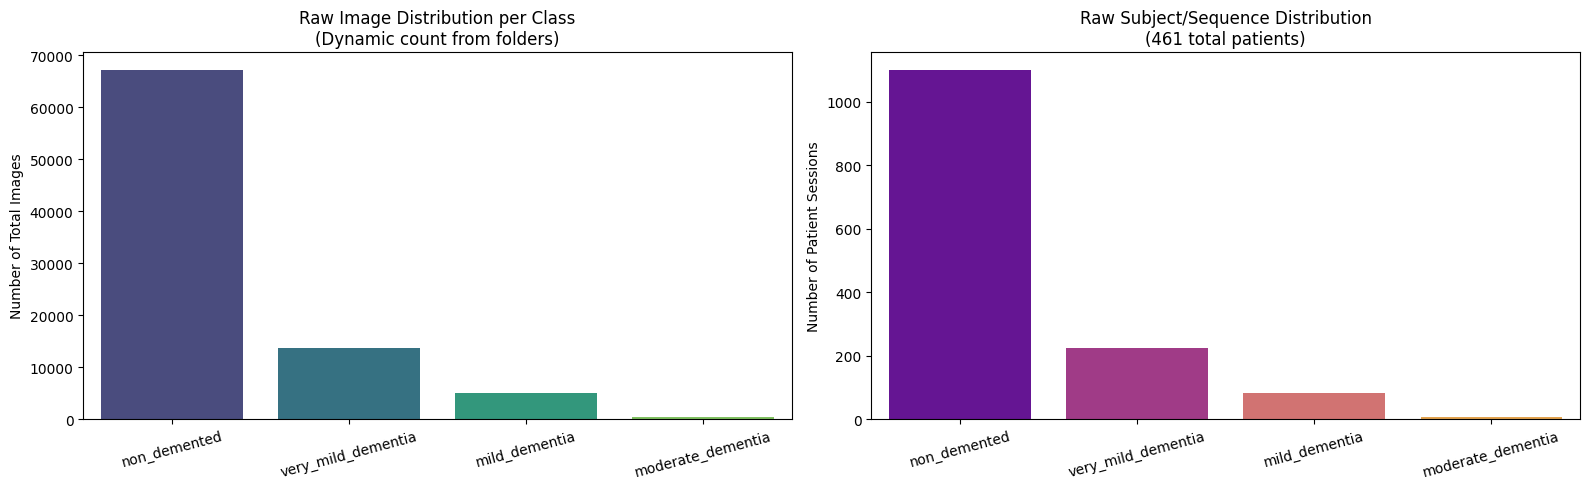

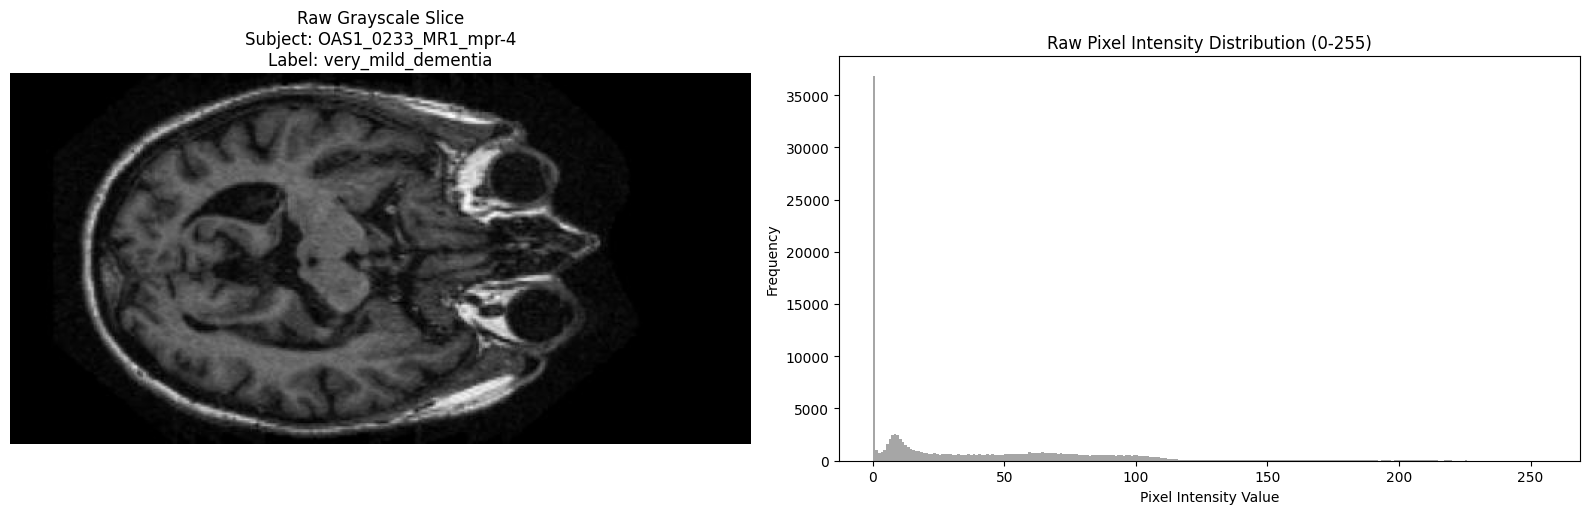

--- Raw Data Specification (Dynamic) ---
Total Images Found: 86437
Total Subjects Found: 1417
Raw Image Resolution: 496x248
Slices per Subject: 61
Pixel Range: Min=0, Max=254
Found Labels: ['non_demented', 'very_mild_dementia', 'mild_dementia', 'moderate_dementia']


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cv2
import random

# ========== EDA: RAW DATA ANALYSIS ==========
IMG_SIZE = (128, 128)
CHANNELS = 3
SEQ_LEN = 61
CLASS_MAP = {
    'non_demented': 0,
    'very_mild_dementia': 1,
    'mild_dementia': 2,
    'moderate_dementia': 3
}

#  Count Classes and Patients from Raw Data
# Reading from the 'subjects' dictionary populated directly from folder
raw_class_image_counts = {label: 0 for label in CLASS_MAP.keys()}
raw_subject_counts = {label: 0 for label in CLASS_MAP.keys()}

for sid, info in subjects_data.items():
    label = info['label']
    raw_subject_counts[label] += 1
    raw_class_image_counts[label] += len(info['paths'])

# Plot Raw Class Distributions
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Image Level Distribution
sns.barplot(x=list(raw_class_image_counts.keys()), y=list(raw_class_image_counts.values()), ax=ax[0], palette='viridis')
ax[0].set_title("Raw Image Distribution per Class\n(Dynamic count from folders)")
ax[0].set_ylabel("Number of Total Images")
ax[0].tick_params(axis='x', rotation=15)

# Subject/Sequence Level Distribution [cite: 533]
sns.barplot(x=list(raw_subject_counts.keys()), y=list(raw_subject_counts.values()), ax=ax[1], palette='plasma')
ax[1].set_title("Raw Subject/Sequence Distribution\n(461 total patients)")
ax[1].set_ylabel("Number of Patient Sessions")
ax[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Picking a random subject and a random slice
random_sid = random.choice(list(subjects_data.keys()))
random_slice_path = random.choice(subjects_data[random_sid]['paths'])

# Load image
raw_sample_img = cv2.imread(random_slice_path, cv2.IMREAD_GRAYSCALE)

# Plot Sample Slice and Raw Pixel Distribution
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Sample of Raw Image
ax[0].imshow(raw_sample_img, cmap='gray')
ax[0].set_title(f"Raw Grayscale Slice\nSubject: {random_sid}\nLabel: {subjects_data[random_sid]['label']}")
ax[0].axis('off')

# Raw Intensity Check (Before Normalization)
ax[1].hist(raw_sample_img.ravel(), bins=256, range=(0, 256), color='gray', alpha=0.7)
ax[1].set_title("Raw Pixel Intensity Distribution (0-255)")
ax[1].set_xlabel("Pixel Intensity Value")
ax[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Specification Verification
total_images = sum(raw_class_image_counts.values())
print("--- Raw Data Specification (Dynamic) ---")
print(f"Total Images Found: {total_images}")
print(f"Total Subjects Found: {len(subjects_data)}")
print(f"Raw Image Resolution: {raw_sample_img.shape[1]}x{raw_sample_img.shape[0]}")
print(f"Slices per Subject: {len(subjects_data[random_sid]['paths'])}")
print(f"Pixel Range: Min={raw_sample_img.min()}, Max={raw_sample_img.max()}")
print(f"Found Labels: {list(raw_class_image_counts.keys())}")

In [ ]:
# Sort IDs alphabetically before splitting
all_subject_ids = sorted(list(subjects_data.keys()))
all_labels = [subjects_data[sid]['label'] for sid in all_subject_ids]

#Stratified Split: Train+Val (80%) and Test (20%)
train_val_ids, test_ids = train_test_split(
    all_subject_ids,
    test_size=0.2,
    stratify=all_labels,
    random_state=SEED
)

train_val_labels = [subjects_data[sid]['label'] for sid in train_val_ids]

# Stratified Split: Train (80% of Train+Val) and Val (20% of Train+Val)
train_ids, val_ids = train_test_split(
    train_val_ids,
    test_size=0.2,
    stratify=train_val_labels,
    random_state=SEED
)

# Resampling
ros = RandomOverSampler(random_state=SEED)
train_ids_resampled, _ = ros.fit_resample(
    np.array(train_ids).reshape(-1, 1),
    [subjects_data[sid]['label'] for sid in train_ids]
)
train_ids_resampled = train_ids_resampled.flatten()

lb = LabelBinarizer()
lb.fit(list(CLASS_MAP.keys()))

LabelBinarizer()

In [ ]:
print("--- Loading Resampled Training Data ---")
X_train, y_train = load_sequences_to_ram(train_ids_resampled, subjects_data, lb)

print("\n--- Loading Original Validation Data ---")
X_val, y_val = load_sequences_to_ram(val_ids, subjects_data, lb)

print("\n--- Loading Original Test Data ---")
X_test, y_test = load_sequences_to_ram(test_ids, subjects_data, lb)

for i in range(len(X_train)):
    if random.random() > 0.5:
        X_train[i] = np.flip(X_train[i], axis=2)

#Final Shape
print("\n" + "="*40)
print("             DATASET SPLIT SUMMARY")
print("="*40)
print(f"Final X_train shape: {X_train.shape}")
print(f"Training Class Distribution: {np.sum(y_train, axis=0)}\n")

print(f"Final X_val shape:   {X_val.shape}")
print(f"Validation Class Distribution: {np.sum(y_val, axis=0)}\n")

print(f"Final X_test shape:  {X_test.shape}")
print(f"Test Class Distribution: {np.sum(y_test, axis=0)}")
print("="*40)

--- Loading Resampled Training Data ---
Loading 2816 subjects...


100%|██████████| 2816/2816 [02:24<00:00, 19.54it/s]



--- Loading Original Validation Data ---
Loading 227 subjects...


100%|██████████| 227/227 [00:11<00:00, 19.88it/s]



--- Loading Original Test Data ---
Loading 284 subjects...


100%|██████████| 284/284 [00:14<00:00, 19.67it/s]



             DATASET SPLIT SUMMARY
Final X_train shape: (2816, 61, 128, 128, 3)
Training Class Distribution: [704 704 704 704]

Final X_val shape:   (227, 61, 128, 128, 3)
Validation Class Distribution: [ 13   1 177  36]

Final X_test shape:  (284, 61, 128, 128, 3)
Test Class Distribution: [ 16   2 221  45]


##No preprocessing



In [ ]:
import os, re, random
import numpy as np
import cv2
from tqdm import tqdm
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer

# ========== CONFIGURATION ==========
IMG_SIZE = (128, 128)
SEQ_LEN = 61
CLASS_MAP = {
    'non_demented': 0,
    'very_mild_dementia': 1,
    'mild_dementia': 2,
    'moderate_dementia': 3
}
SEED = 42

# ========== SUBJECT GROUPING & SORTING ==========
def get_processed_subjects(dataset_dir):
    """Groups images into 61-slice sequences and ensures numerical order."""
    subjects = defaultdict(lambda: {'label': None, 'paths': []})

    for label_folder in os.listdir(dataset_dir):
        label_dir = os.path.join(dataset_dir, label_folder)
        if not os.path.isdir(label_dir): continue

        # Standardize labels
        clean_label = label_folder.lower().replace(" ", "_")

        with os.scandir(label_dir) as entries:
            for entry in entries:
                if entry.is_file() and entry.name.lower().endswith(('.jpg', '.jpeg')):
                    sid = '_'.join(entry.name.split('_')[:4])
                    subjects[sid]['label'] = clean_label
                    subjects[sid]['paths'].append(entry.path)

    final_subjects = {}
    for sid, data in subjects.items():
        if len(data['paths']) == SEQ_LEN:
            #Sort slices numerically
            data['paths'] = sorted(
                data['paths'],
                key=lambda x: int(re.findall(r'_(\d+)\.jpg$', x)[0])
            )
            final_subjects[sid] = data

    return final_subjects

def load_sequences_to_ram(ids_list, subjects_dict, lb):
    """Loads MRI sequences into RAM as uint8 to save space."""
    X, y = [], []
    print(f"Loading {len(ids_list)} subjects...")

    for sid in tqdm(ids_list):
        info = subjects_dict[sid]
        sequence = []
        for path in info['paths']:
            img = cv2.imread(path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, IMG_SIZE)
            sequence.append(img)

        X.append(np.array(sequence, dtype='uint8'))
        y.append(info['label'])

    return np.array(X), lb.transform(y)


dataset_dir = "/content/local_data/Data"
subjects_data = get_processed_subjects(dataset_dir)

# Sort IDs alphabetically before splitting
all_subject_ids = sorted(list(subjects_data.keys()))
all_labels = [subjects_data[sid]['label'] for sid in all_subject_ids]

# Stratified Split: Train+Val (80%) and Test (20%)
train_val_ids, test_ids = train_test_split(
    all_subject_ids,
    test_size=0.2,
    stratify=all_labels,
    random_state=SEED
)

# Extract labels for the train_val subset to stratify the next split
train_val_labels = [subjects_data[sid]['label'] for sid in train_val_ids]

# Stratified Split: Train (80% of Train+Val) and Val (20% of Train+Val)
train_ids, val_ids = train_test_split(
    train_val_ids,
    test_size=0.2,
    stratify=train_val_labels,
    random_state=SEED
)

#Label Binarizer Initialization
lb = LabelBinarizer()
lb.fit(list(CLASS_MAP.keys()))

print("--- Loading Original Training Data ---")
X_train, y_train = load_sequences_to_ram(train_ids, subjects_data, lb)

print("\n--- Loading Original Validation Data ---")
X_val, y_val = load_sequences_to_ram(val_ids, subjects_data, lb)

print("\n--- Loading Original Test Data ---")
X_test, y_test = load_sequences_to_ram(test_ids, subjects_data, lb)

#Final Shape Verification
print("\n" + "="*40)
print("            DATASET SPLIT SUMMARY")
print("="*40)
print(f"Final X_train shape: {X_train.shape} (Raw)")
print(f"Training Class Distribution: {np.sum(y_train, axis=0)}\n")

print(f"Final X_val shape:   {X_val.shape})")
print(f"Validation Class Distribution: {np.sum(y_val, axis=0)}\n")

print(f"Final X_test shape:  {X_test.shape}")
print(f"Test Class Distribution: {np.sum(y_test, axis=0)}")
print("="*40)

--- Loading Original Training Data ---
Loading 906 subjects...


100%|██████████| 906/906 [00:41<00:00, 21.96it/s]



--- Loading Original Validation Data ---
Loading 227 subjects...


100%|██████████| 227/227 [00:10<00:00, 22.46it/s]



--- Loading Original Test Data ---
Loading 284 subjects...


100%|██████████| 284/284 [00:12<00:00, 22.33it/s]



            DATASET SPLIT SUMMARY
Final X_train shape: (906, 61, 128, 128, 3) (Raw)
Training Class Distribution: [ 53   5 704 144]

Final X_val shape:   (227, 61, 128, 128, 3))
Validation Class Distribution: [ 13   1 177  36]

Final X_test shape:  (284, 61, 128, 128, 3)
Test Class Distribution: [ 16   2 221  45]


# EDA After Preprocessing

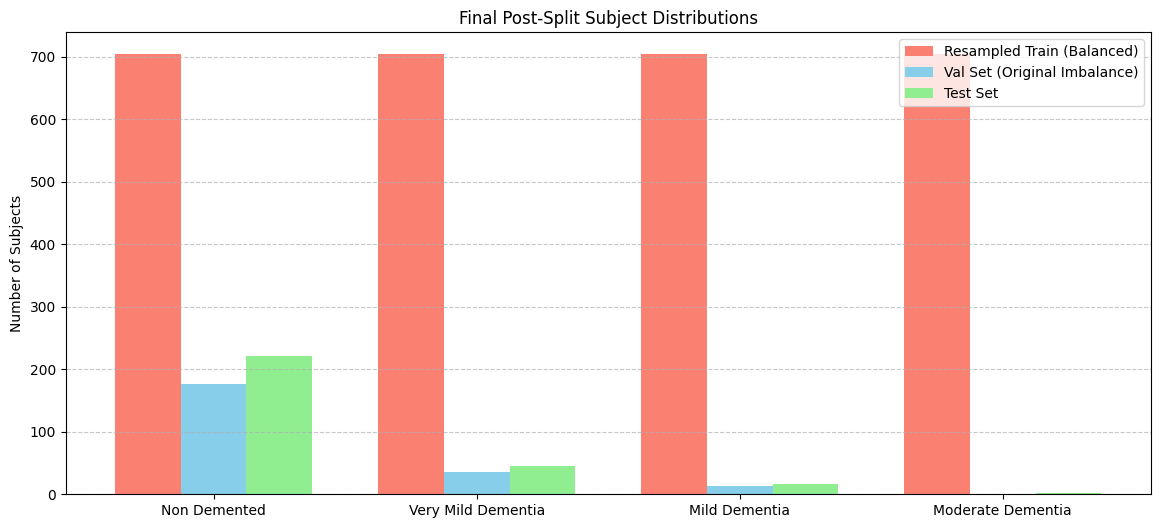

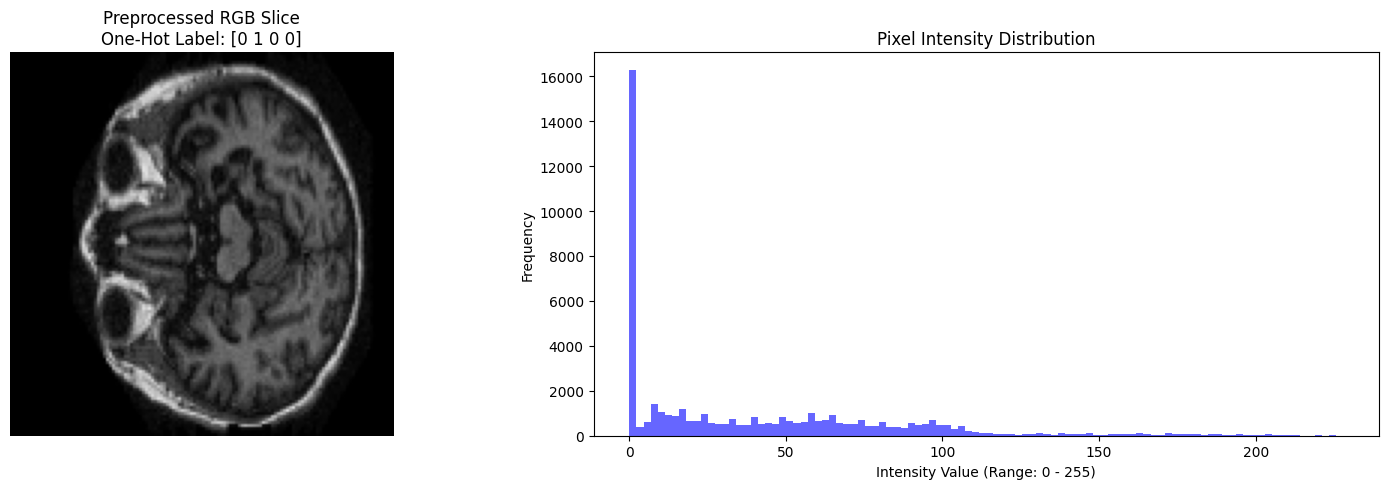

--- Final Post-Preprocessing Verification---
X_train Shape:         (2816, 61, 128, 128, 3)
X_val Shape:           (227, 61, 128, 128, 3)
X_test Shape:          (284, 61, 128, 128, 3)
Sequence Length:       61 slices
Image Resolution:      128x128
Data Type:             uint8
Value Range in RAM:    Min=0, Max=228
Total Memory footprint: 9.29 GB


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

target_subjects = subjects_data

# Count Classes across ALL sets (Train, Val, Test)
train_class_counts = {label: 0 for label in CLASS_MAP.keys()}
for sid in train_ids_resampled:
    train_class_counts[target_subjects[sid]['label']] += 1

val_class_counts = {label: 0 for label in CLASS_MAP.keys()}
for sid in val_ids:
    val_class_counts[target_subjects[sid]['label']] += 1

test_class_counts = {label: 0 for label in CLASS_MAP.keys()}
for sid in test_ids:
    test_class_counts[target_subjects[sid]['label']] += 1

# Plot All Class Distributions
categories = list(CLASS_MAP.keys())
display_names = [c.replace('_', ' ').title() for c in categories]
x = np.arange(len(categories))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, [train_class_counts[c] for c in categories], width, label='Resampled Train (Balanced)', color='salmon')
ax.bar(x, [val_class_counts.get(c, 0) for c in categories], width, label='Val Set (Original Imbalance)', color='skyblue')
ax.bar(x + width, [test_class_counts.get(c, 0) for c in categories], width, label='Test Set', color='lightgreen')

ax.set_ylabel('Number of Subjects')
ax.set_title('Final Post-Split Subject Distributions')
ax.set_xticks(x)
ax.set_xticklabels(display_names)
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Inspect Preprocessed Data
idx = np.random.randint(0, len(X_train))
sample_seq = X_train[idx]
sample_label = y_train[idx]
sample_slice = sample_seq[30]

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Sample slice
ax[0].imshow(sample_slice)
ax[0].set_title(f"Preprocessed RGB Slice\nOne-Hot Label: {sample_label}")
ax[0].axis('off')

ax[1].hist(sample_slice.ravel(), bins=100, color='blue', alpha=0.6)
ax[1].set_title("Pixel Intensity Distribution")
ax[1].set_xlabel("Intensity Value (Range: 0 - 255)")
ax[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

target_subjects = subjects_data

# Count Classes from the Resampled Training Set
train_class_counts = {label: 0 for label in CLASS_MAP.keys()}
for sid in train_ids_resampled:
    label = target_subjects[sid]['label']
    train_class_counts[label] += 1


# Final Specification
print("--- After pre processing---")
print(f"X_train Shape:         {X_train.shape}")
print(f"X_val Shape:           {X_val.shape}")
print(f"X_test Shape:          {X_test.shape}")
print(f"Sequence Length:       {sample_seq.shape[0]} slices")
print(f"Image Resolution:      {sample_slice.shape[0]}x{sample_slice.shape[1]}")
print(f"Data Type:             {X_train.dtype}")
print(f"Total Memory footprint: {(X_train.nbytes + X_val.nbytes + X_test.nbytes) / (1024**3):.2f} GB")

In [ ]:
# Count Classes from the Test Set
test_class_counts = {label: 0 for label in CLASS_MAP.keys()}
for sid in test_ids:
    label = target_subjects[sid]['label']
    test_class_counts[label] += 1

# Plot Class Distributions
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Test Distribution
sns.barplot(x=list(test_class_counts.keys()), y=list(test_class_counts.values()), ax=ax[1], palette='viridis')
ax[1].set_title("Test Set Distribution\n(Representative of Clinical Reality)")
ax[1].set_ylabel("Number of 61-Slice Sequences")
ax[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Model Building

## Base CNN, CNN-LSTM

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (TimeDistributed, Conv2D, MaxPooling2D,
                                     GlobalAveragePooling2D, LSTM, Bidirectional, Dense,
                                     Dropout, Flatten, Rescaling, Input)
from tensorflow.keras.losses import CategoricalFocalCrossentropy

# --- BASELINE CNN ---
def build_baseline_cnn():
    model = Sequential([
        Input(shape=(61, 128, 128, 3)),
        TimeDistributed(Rescaling(1./255)),

        TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same')),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same')),
        TimeDistributed(GlobalAveragePooling2D()),

        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(4, activation='softmax', dtype='float32')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# --- HYBRID CNN-LSTM ---
def build_hybrid_lstm():
    model = Sequential([
        Input(shape=(61, 128, 128, 3)),
        TimeDistributed(Rescaling(1./255)),

        TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same')),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same')),
        TimeDistributed(GlobalAveragePooling2D()),

        Bidirectional(LSTM(64, dropout=0.2)),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(4, activation='softmax', dtype='float32')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

## callbacks

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

def get_checkpoint_callback(folder_path="/content/drive/MyDrive/dementia_models/", filename="hybrid_lstm_checkpoint.keras", save_best_only=False):
    import os
    from google.colab import drive

    drive.mount('/content/drive')


    full_save_path = os.path.join(folder_path, filename)

    checkpoint = ModelCheckpoint(
        filepath=full_save_path,
        monitor='val_loss',
        save_best_only=save_best_only,
        save_weights_only=False,
        verbose=0
    )

    return checkpoint

In [ ]:
def prepare_dataset(X, y, batch_size=2, shuffle=False):
    # Force the creation of the dataset to happen on the CPU (leftover from weaker config)
    with tf.device('/cpu:0'):
        ds = tf.data.Dataset.from_tensor_slices((X, y))

        if shuffle:
            ds = ds.shuffle(buffer_size=len(X), seed=42)

        ds = ds.batch(batch_size)

        ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

In [ ]:
# Initialize models
baseline_model = build_baseline_cnn()
hybrid_model = build_hybrid_lstm()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


## Baseline

In [ ]:
from tensorflow.keras.callbacks import CSVLogger

csv_path = "/content/drive/My Drive/Colab Notebooks/models_history/cnn_training_metrics.csv"
csv_logger = CSVLogger(csv_path, append=True)

checkpoint_logger = get_checkpoint_callback(
    folder_path="/content/drive/My Drive/Colab Notebooks/models_history/baseline_epoch",
    filename="cnnmodel.keras",
    save_best_only=True
)

train_ds = prepare_dataset(X_train, y_train, batch_size=32, shuffle=True)
test_ds = prepare_dataset(X_test, y_test, batch_size=32)
val_ds = prepare_dataset(X_val, y_val,batch_size=32)
# Train Baseline
print("\n--- Training Baseline CNN ---")
history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=val_ds,
    epochs=500,
    callbacks=[csv_logger, checkpoint_logger]
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- Training Baseline CNN ---
Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 66s 214ms/step - accuracy: 0.2511 - loss: 1.3872 - val_accuracy: 0.7797 - val_loss: 1.3562
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - accuracy: 0.2635 - loss: 1.3846 - val_accuracy: 0.0969 - val_loss: 1.3797
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - accuracy: 0.2638 - loss: 1.3839 - val_accuracy: 0.4449 - val_loss: 1.3813
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - accuracy: 0.3061 - loss: 1.3803 - val_accuracy: 0.1057 - val_loss: 1.4051
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - accuracy: 0.3150 - loss: 1.3743 - val_accuracy: 0.5198 - val_loss: 1.3601
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - accuracy: 0.3537 - loss: 1.3623 - val_accuracy: 0.6300 - val_loss: 1.3373
Epoch 7/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - accu

In [ ]:
from tensorflow.keras.models import load_model

baseline_model = load_model("/content/drive/My Drive/Colab Notebooks/models/alzheimer_baseline_cnn.keras")

train until 600

In [ ]:
csv_path = "/content/drive/My Drive/Colab Notebooks/models_history/cnn_training_metrics.csv"
csv_logger = CSVLogger(csv_path, append=True)

checkpoint_logger = get_checkpoint_callback(
    folder_path="/content/drive/My Drive/Colab Notebooks/models_history/baseline_epoch",
    filename="cnnmodel.keras",
    save_best_only=True
)

history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=val_ds,
    epochs=800,
    initial_epoch=500,
    callbacks=[csv_logger, checkpoint_logger]
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch 501/800
88/88 ━━━━━━━━━━━━━━━━━━━━ 67s 221ms/step - accuracy: 0.7837 - loss: 0.4944 - val_accuracy: 0.7489 - val_loss: 0.5812
Epoch 502/800
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - accuracy: 0.7880 - loss: 0.4907 - val_accuracy: 0.8062 - val_loss: 0.4672
Epoch 503/800
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - accuracy: 0.8015 - loss: 0.4680 - val_accuracy: 0.7930 - val_loss: 0.4961
Epoch 504/800
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - accuracy: 0.7983 - loss: 0.4709 - val_accuracy: 0.8282 - val_loss: 0.4454
Epoch 505/800
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - accuracy: 0.8047 - loss: 0.4753 - val_accuracy: 0.7974 - val_loss: 0.4667
Epoch 506/800
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - accuracy: 0.7997 - loss: 0.4759 - val_accuracy: 0.8018 - val_loss: 0.4915
Epoch 507/800
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - accuracy: 0.7979 - lo

In [ ]:
import pandas as pd

history_df = pd.DataFrame(history_baseline.history)

history_df.insert(0, 'Epoch', range(1, len(history_df) + 1))

save_path = "/content/drive/My Drive/Colab Notebooks/models_history/baseline_training_metrics.csv"
history_df.to_csv(save_path, index=False)

print("Saved training history")

Saved training history


In [ ]:
  # Path to project folder on Drive
save_path = "/content/drive/My Drive/Colab Notebooks/models/alzheimer_baseline_cnn2.keras"

# Save the model
baseline_model.save(save_path)
print(f"Model successfully exported to: {save_path}")

Model successfully exported to: /content/drive/My Drive/Colab Notebooks/models/alzheimer_baseline_cnn2.keras


## Hybrid

In [ ]:
from tensorflow.keras.callbacks import CSVLogger

csv_path = "/content/drive/My Drive/Colab Notebooks/models_history/hybrid_training_metrics.csv"
csv_logger = CSVLogger(csv_path, append=False)

checkpoint_logger = get_checkpoint_callback(
    folder_path="/content/drive/My Drive/Colab Notebooks/models_history/hybrid_epoch",
    filename="hybridmodel.keras",
    save_best_only=True
)

train_ds = prepare_dataset(X_train, y_train, batch_size=8, shuffle=True)
test_ds = prepare_dataset(X_test, y_test, batch_size=8)
val_ds = prepare_dataset(X_val, y_val,batch_size=8)
# Train Hybrid
print("\n--- Training Hybrid CNN-LSTM ---")
history_hybrid = hybrid_model.fit(
    X_train,y_train,
    validation_data=(X_val, y_val),
    epochs=500,
    batch_size=8,
    shuffle=True,
    callbacks=[csv_logger, checkpoint_logger]
)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- Training Hybrid CNN-LSTM ---
Epoch 1/500
352/352 ━━━━━━━━━━━━━━━━━━━━ 102s 245ms/step - accuracy: 0.2482 - loss: 1.3887 - val_accuracy: 0.4626 - val_loss: 1.3761
Epoch 2/500
352/352 ━━━━━━━━━━━━━━━━━━━━ 81s 231ms/step - accuracy: 0.2592 - loss: 1.3864 - val_accuracy: 0.1542 - val_loss: 1.4162
Epoch 3/500
352/352 ━━━━━━━━━━━━━━━━━━━━ 81s 231ms/step - accuracy: 0.2972 - loss: 1.3702 - val_accuracy: 0.1542 - val_loss: 1.3222
Epoch 4/500
352/352 ━━━━━━━━━━━━━━━━━━━━ 81s 231ms/step - accuracy: 0.3771 - loss: 1.2766 - val_accuracy: 0.3789 - val_loss: 1.2399
Epoch 5/500
352/352 ━━━━━━━━━━━━━━━━━━━━ 81s 231ms/step - accuracy: 0.5241 - loss: 0.9894 - val_accuracy: 0.5507 - val_loss: 1.0121
Epoch 6/500
352/352 ━━━━━━━━━━━━━━━━━━━━ 81s 231ms/step - accuracy: 0.5888 - loss: 0.8320 - val_accuracy: 0.6388 - val_loss: 0.8353
Epoch 7/500
352/352 ━━━━━━━━━━━━━━━━━━━━ 81s

In [ ]:
# Path to project folder on Drive
save_path = "/content/drive/My Drive/Colab Notebooks/models/alzheimer_base_cnn_lstm3.keras"

# Save the model
hybrid_model.save(save_path)
print(f"Model successfully exported to {save_path}")

Model successfully exported to /content/drive/My Drive/Colab Notebooks/models/alzheimer_base_cnn_lstm3.keras


## Hybrid 30 runs

In [ ]:
import os
import random
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.callbacks import Callback
from sklearn.metrics import f1_score, precision_score, recall_score

class AdvancedMetricsLogger(Callback):
    def __init__(self, validation_data, actual_seed):
        super().__init__()
        self.validation_data = validation_data
        self.actual_seed = actual_seed
        self.epoch_start_time = 0

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        # Calculate time
        epoch_time = time.time() - self.epoch_start_time

        X_val, y_val_true = self.validation_data
        y_pred_probs = self.model.predict(X_val, verbose=0)

        y_true_classes = np.argmax(y_val_true, axis=1)
        y_pred_classes = np.argmax(y_pred_probs, axis=1)

        val_f1 = f1_score(y_true_classes, y_pred_classes, average='macro')
        val_precision = precision_score(y_true_classes, y_pred_classes, average='macro', zero_division=0)
        val_recall = recall_score(y_true_classes, y_pred_classes, average='macro')

        # Inject into logs
        logs['val_f1'] = val_f1
        logs['val_precision'] = val_precision
        logs['val_recall'] = val_recall
        logs['actual_seed'] = self.actual_seed
        logs['epoch_time_seconds'] = epoch_time

        print(f" - Epoch {epoch+1} - Seed: {self.actual_seed} - val_f1: {val_f1:.4f} - time: {epoch_time:.2f}s")

# ==============================================================================
START_RUN = 31
END_RUN = 31
TOTAL_EPOCHS = 400
# ==============================================================================

base_save_dir = "/content/drive/My Drive/Colab Notebooks/models_history/multi_seed_runs"
os.makedirs(base_save_dir, exist_ok=True)

# Datasets
train_ds = prepare_dataset(X_train, y_train, batch_size=8, shuffle=True)
val_ds = prepare_dataset(X_val, y_val, batch_size=8)

for run in range(START_RUN, END_RUN + 1):
    # generate random seed
    seed_value = random.randint(1, 99999)
    print(f"\nSTARTING RUN {run} (Seed: {seed_value})")

    os.environ['PYTHONHASHSEED'] = str(seed_value)
    random.seed(seed_value)
    np.random.seed(seed_value)
    tf.random.set_seed(seed_value)

    model = build_hybrid_lstm()

    run_csv_path = os.path.join(base_save_dir, f"run_{run}_metrics.csv")
    csv_logger = tf.keras.callbacks.CSVLogger(run_csv_path, append=False)

    # Pass the actual_seed to the logger
    advanced_logger = AdvancedMetricsLogger(validation_data=(X_val, y_val), actual_seed=seed_value)

    checkpoint_logger = get_checkpoint_callback(
        folder_path=os.path.join(base_save_dir, f"run_{run}_checkpoints"),
        filename="last_model.keras",
        save_best_only=False
    )

    checkpoint_best = get_checkpoint_callback(
        folder_path=os.path.join(base_save_dir, f"run_{run}_checkpoints"),
        filename="best_model.keras",
        save_best_only=True
    )

    try:
        model.fit(
            X_train, y_train,
            validation_data=val_ds,
            epochs=TOTAL_EPOCHS,
            batch_size=8,
            shuffle=True,
            callbacks=[advanced_logger, csv_logger, checkpoint_logger, checkpoint_best],
            verbose=1
        )
    except KeyboardInterrupt:
        print(f"\nUser interrupted at run {run}. Saving current progress and exiting loop.")
        break

print(f"\n Runs {START_RUN} through {END_RUN} completed and saved!")


STARTING RUN 31 (Seed: 53384)
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch 1/400
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.7194 - loss: 0.8840 - Epoch 1 - Seed: 53384 - val_f1: 0.2191 - time: 32.81s
114/114 ━━━━━━━━━━━━━━━━━━━━ 35s 266ms/step - accuracy: 0.7693 - loss: 0.7517 - val_accuracy: 0.7797 - val_loss: 0.6853 - val_f1: 0.2191 - val_precision: 0.1949 - val_recall: 0.2500 - actual_seed: 53384.0000 - epoch_time_seconds: 32.8107
Epoch 2/400
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.7541 - loss: 0.7435 - Epoch 2 - Seed: 53384 - val_f1: 0.2191 - time: 27.16s
114/114 ━━━━━━━━━━━━━━━━━━━━ 28s 243ms/step - accuracy: 0.7770 - loss: 0.7053 - val_accuracy: 0.7797 - val_loss: 0.6817 - val_f1: 0.2191 - val_precision: 0.1949 - val_recall: 0.2500 -

##continue to epoch 500

In [ ]:
# Resume 30 run hybrid to epoch 500
import os
import random
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import Callback, CSVLogger
from sklearn.metrics import f1_score, precision_score, recall_score

class AdvancedMetricsLogger(Callback):
    def __init__(self, validation_data, actual_seed):
        super().__init__()
        self.validation_data = validation_data
        self.actual_seed = actual_seed
        self.epoch_start_time = 0

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        # Calculate time
        epoch_time = time.time() - self.epoch_start_time

        X_val, y_val_true = self.validation_data
        y_pred_probs = self.model.predict(X_val, verbose=0)

        y_true_classes = np.argmax(y_val_true, axis=1)
        y_pred_classes = np.argmax(y_pred_probs, axis=1)

        val_f1 = f1_score(y_true_classes, y_pred_classes, average='macro')
        val_precision = precision_score(y_true_classes, y_pred_classes, average='macro', zero_division=0)
        val_recall = recall_score(y_true_classes, y_pred_classes, average='macro')

        # Inject into logs
        logs['val_f1'] = val_f1
        logs['val_precision'] = val_precision
        logs['val_recall'] = val_recall
        logs['actual_seed'] = self.actual_seed
        logs['epoch_time_seconds'] = epoch_time

        print(f" - Epoch {epoch+1} - Seed: {self.actual_seed} - val_f1: {val_f1:.4f} - time: {epoch_time:.2f}s")

# ==============================================================================
TARGET_RUN = 5
PREVIOUS_SEED = 85446
INITIAL_EPOCH = 400
TOTAL_EPOCHS = 500
# ==============================================================================

base_save_dir = "/content/drive/My Drive/Colab Notebooks/models_history/multi_seed_runs"
print(f"\n--- Resuming RUN {TARGET_RUN} (Seed: {PREVIOUS_SEED}) from Epoch {INITIAL_EPOCH} to {TOTAL_EPOCHS} ---")

# set seed
os.environ['PYTHONHASHSEED'] = str(PREVIOUS_SEED)
random.seed(PREVIOUS_SEED)
np.random.seed(PREVIOUS_SEED)
tf.random.set_seed(PREVIOUS_SEED)

# load last model
model_path = os.path.join(base_save_dir, f"run_{TARGET_RUN}_checkpoints", "last_model.keras")
print(f"Loading model from: {model_path}")
model = load_model(model_path)

# Setup Callbacks
run_csv_path = os.path.join(base_save_dir, f"run_{TARGET_RUN}_metrics.csv")
csv_logger = CSVLogger(run_csv_path, append=True)

advanced_logger = AdvancedMetricsLogger(validation_data=(X_val, y_val), actual_seed=PREVIOUS_SEED)

checkpoint_logger = get_checkpoint_callback(
    folder_path=os.path.join(base_save_dir, f"run_{TARGET_RUN}_checkpoints"),
    filename="last_model.keras",
    save_best_only=False
)

checkpoint_best = get_checkpoint_callback(
    folder_path=os.path.join(base_save_dir, f"run_{TARGET_RUN}_checkpoints"),
    filename="best_model.keras",
    save_best_only=True
)

# Datasets
train_ds = prepare_dataset(X_train, y_train, batch_size=2, shuffle=True)
val_ds = prepare_dataset(X_val, y_val, batch_size=2)

#Resume Training
try:
    model.fit(
        X_train,y_train,
        validation_data=val_ds,
        epochs=TOTAL_EPOCHS,
        initial_epoch=INITIAL_EPOCH,
        batch_size=8,
        shuffle=True,
        callbacks=[advanced_logger, csv_logger, checkpoint_logger, checkpoint_best],
        verbose=1
    )
except KeyboardInterrupt:
    print(f"\nUser interrupted resumption of run {TARGET_RUN}. Progress safely saved.")

print(f"\n Run {TARGET_RUN} successfully resumed and completed to epoch {TOTAL_EPOCHS}!")


--- Resuming RUN 22 (Seed: 85446) from Epoch 400 to 500 ---
Loading model from: /content/drive/My Drive/Colab Notebooks/models_history/multi_seed_runs/run_22_checkpoints/last_model.keras
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch 401/500
 218/1408 ━━━━━━━━━━━━━━━━━━━━ 1:23 70ms/step - accuracy: 1.0000 - loss: 2.8818e-04
User interrupted resumption of run 22. Progress safely saved.

 Run 22 successfully resumed and completed to epoch 500!


## Evaluating 30 runs model

30 runs model

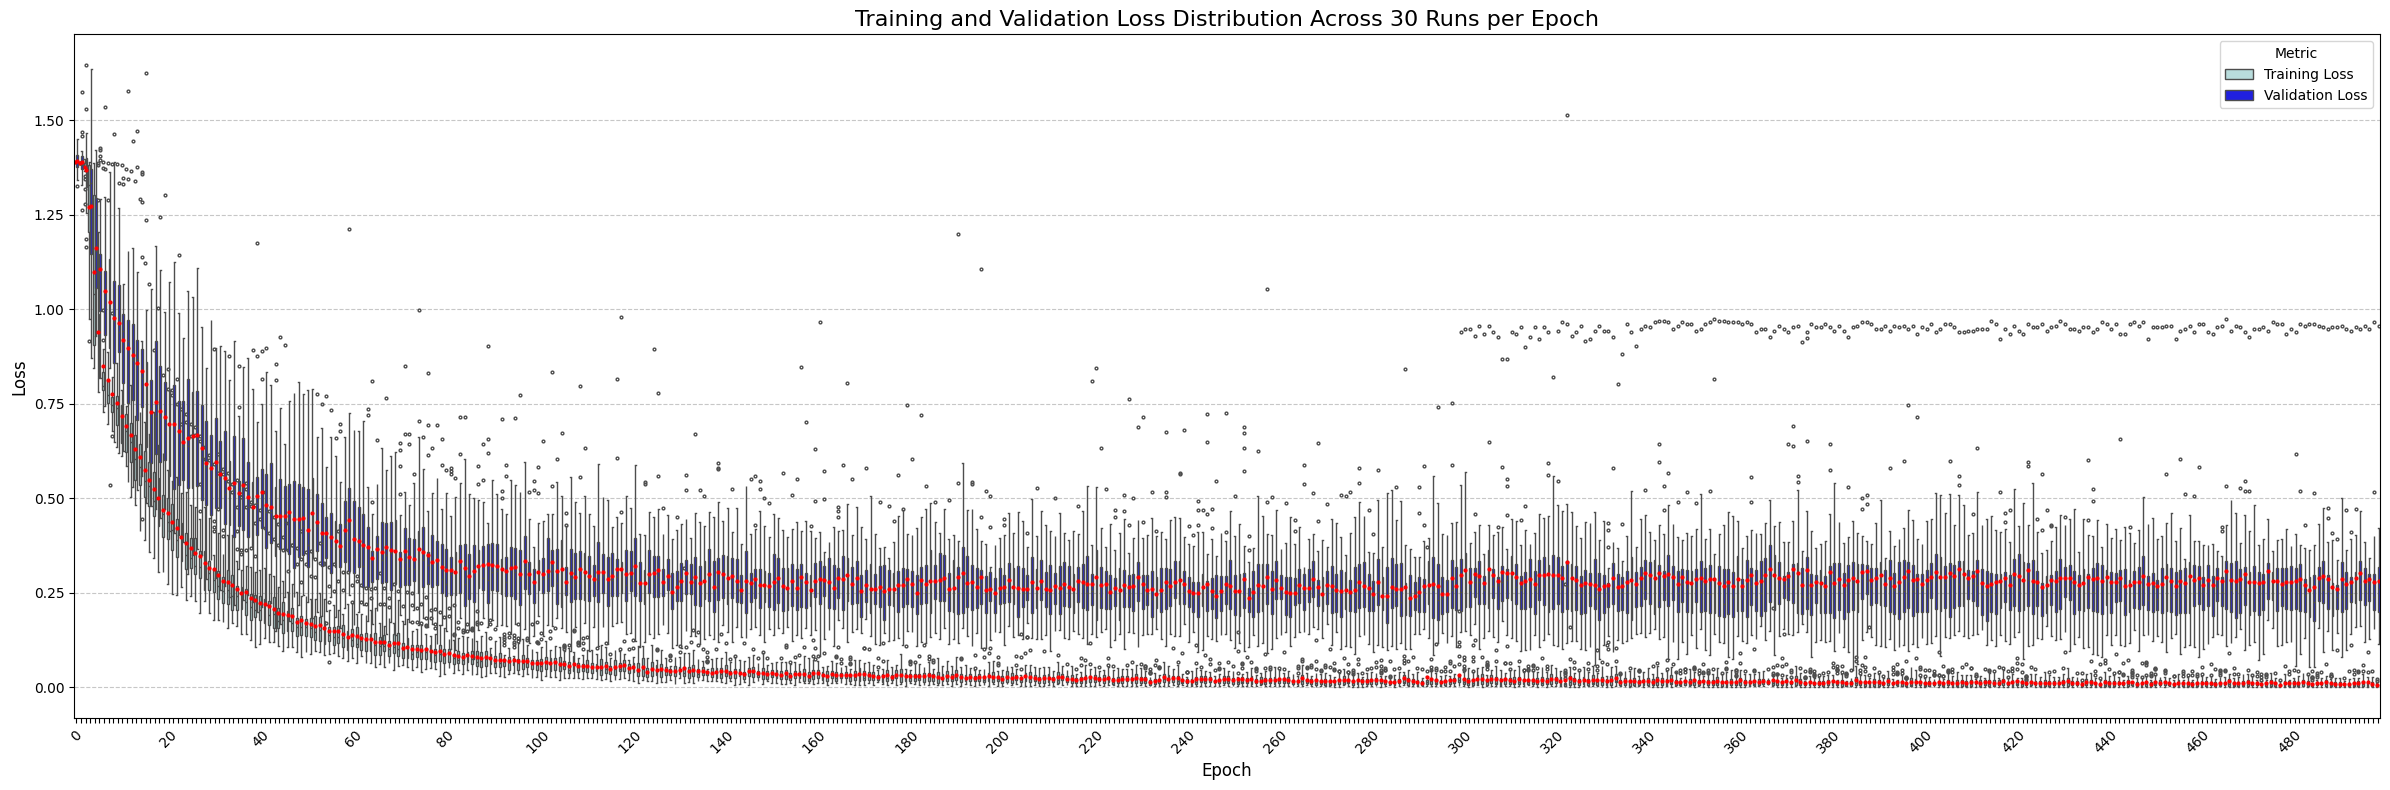

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df_val = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/models_history/multi_seed_runs/all_val_loss.csv')
df_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/models_history/multi_seed_runs/all_loss_compiled.csv')

# Reshape both dataframes from "wide" to "long" format
df_val_long = df_val.melt(id_vars='epoch', var_name='run_number', value_name='Loss')
df_val_long['Loss Type'] = 'Validation Loss'

df_train_long = df_train.melt(id_vars='epoch', var_name='run_number', value_name='Loss')
df_train_long['Loss Type'] = 'Training Loss'
df_combined = pd.concat([df_train_long, df_val_long], ignore_index=True)

# Create the figure
plt.figure(figsize=(24, 8))

# Draw the grouped boxplot
ax = sns.boxplot(
    data=df_combined,
    x='epoch',
    y='Loss',
    hue='Loss Type',
    palette=["#b2e2e2", "#0000FF"],
    fliersize=2,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"red", "markersize":"2"}
)

plt.title('Training and Validation Loss Distribution Across 30 Runs per Epoch', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for index, label in enumerate(ax.get_xticklabels()):
    if index % 20 != 0:
        label.set_visible(False)

plt.xticks(rotation=45)
plt.legend(title='Metric', loc='upper right')
plt.tight_layout()
plt.show()

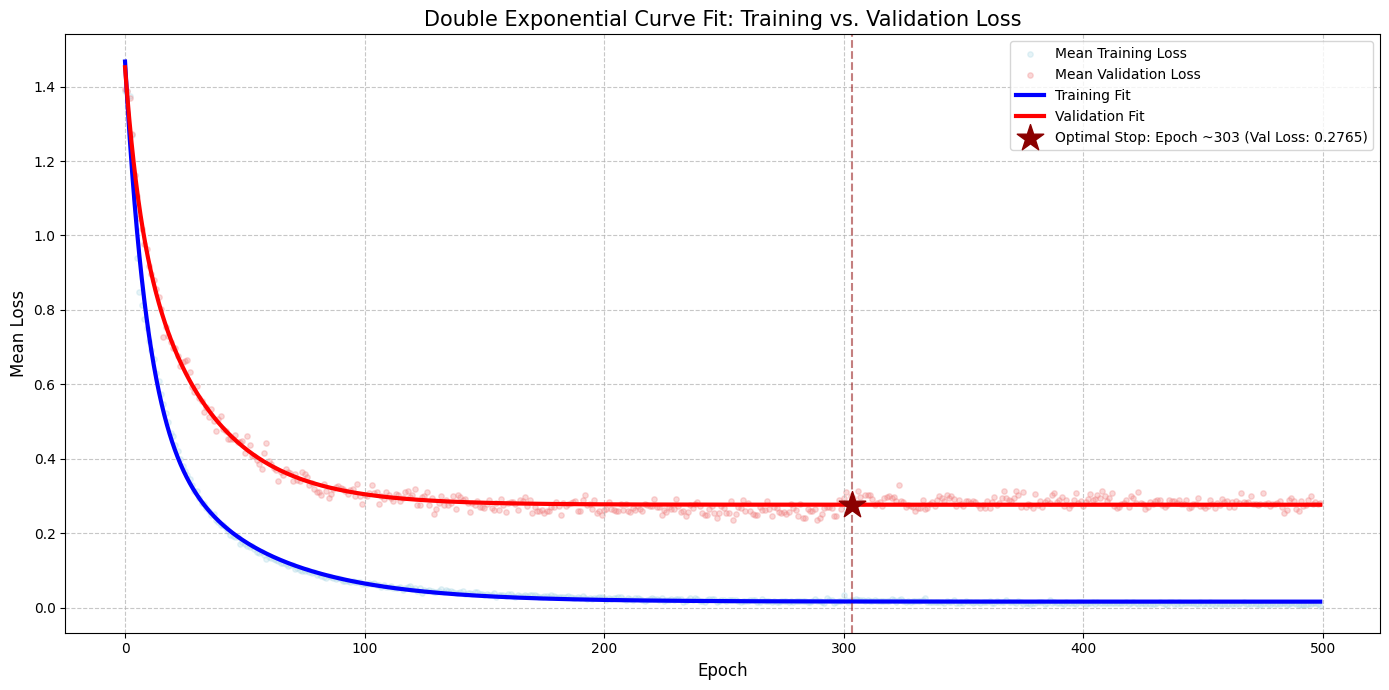

The mathematically optimal stopping epoch is 303


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# data loading
def load_and_clean_data(filepath):
    df = pd.read_csv(filepath, index_col='epoch')
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    epoch_means = df.mean(axis=1)

    x = epoch_means.index.values
    y = epoch_means.values

    valid_mask = np.isfinite(y)
    return x[valid_mask], y[valid_mask]

# Load both datasets
x_val, y_val = load_and_clean_data('/content/drive/MyDrive/Colab Notebooks/models_history/multi_seed_runs/all_val_loss.csv')
x_train, y_train = load_and_clean_data('/content/drive/MyDrive/Colab Notebooks/models_history/multi_seed_runs/all_loss_compiled.csv')


# --- DEFINE THE FUNCTION & FIT BOTH CURVES ---
def f_double_exp(x, A, B, C, D, E):
    return A * np.exp(-B * x) + C * np.exp(-D * x) + E

def fit_loss_curve(x_clean, y_clean):
    # Initial guesses: Fast drop mag, Fast decay rate, Slow drop mag, Slow decay rate, Baseline
    initial_guess = [1.0, 0.1, 0.5, 0.01, min(y_clean)]
    popt, _ = curve_fit(f_double_exp, x_clean, y_clean, p0=initial_guess, maxfev=10000)
    return popt

# Calculate parameters for both curves
popt_val = fit_loss_curve(x_val, y_val)
popt_train = fit_loss_curve(x_train, y_train)


# --- CALCULATE THE OPTIMUM EPOCH (Based on Validation) ---
# Generate high-resolution x values using the validation x-axis as the baseline
x_fit = np.linspace(min(x_val), max(x_val), 5000)

# Generate smooth y values for both curves
y_fit_val = f_double_exp(x_fit, *popt_val)
y_fit_train = f_double_exp(x_fit, *popt_train)

# Calculate the slope of the validation curve to find when it flattens
dy_dx_val = np.gradient(y_fit_val, x_fit)
threshold = 0.000001
flat_indices = np.where(np.abs(dy_dx_val) < threshold)[0]

if len(flat_indices) > 0:
    optimum_index = flat_indices[0]
    optimum_x = x_fit[optimum_index]
    optimum_val_y = y_fit_val[optimum_index]
else:
    optimum_x = max(x_val)
    optimum_val_y = f_double_exp(optimum_x, *popt_val)


plt.figure(figsize=(14, 7))

# Plot Scatter Data
plt.scatter(x_train, y_train, label='Mean Training Loss', color='lightblue', alpha=0.3, s=15)
plt.scatter(x_val, y_val, label='Mean Validation Loss', color='lightcoral', alpha=0.3, s=15)

# Plot Fitted Curves
plt.plot(x_fit, y_fit_train, color='blue', linewidth=3,
         label='Training Fit')
plt.plot(x_fit, y_fit_val, color='red', linewidth=3,
         label='Validation Fit')

# Plot Optimal Stopping Point
plt.scatter([optimum_x], [optimum_val_y], color='darkred', marker='*', s=400, zorder=5,
            label=f'Optimal Stop: Epoch ~{int(optimum_x)} (Val Loss: {optimum_val_y:.4f})')

plt.axvline(x=optimum_x, color='darkred', linestyle='--', alpha=0.5)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Mean Loss', fontsize=12)
plt.title('Double Exponential Curve Fit: Training vs. Validation Loss', fontsize=15)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"The mathematically optimal stopping epoch is {int(optimum_x)}")

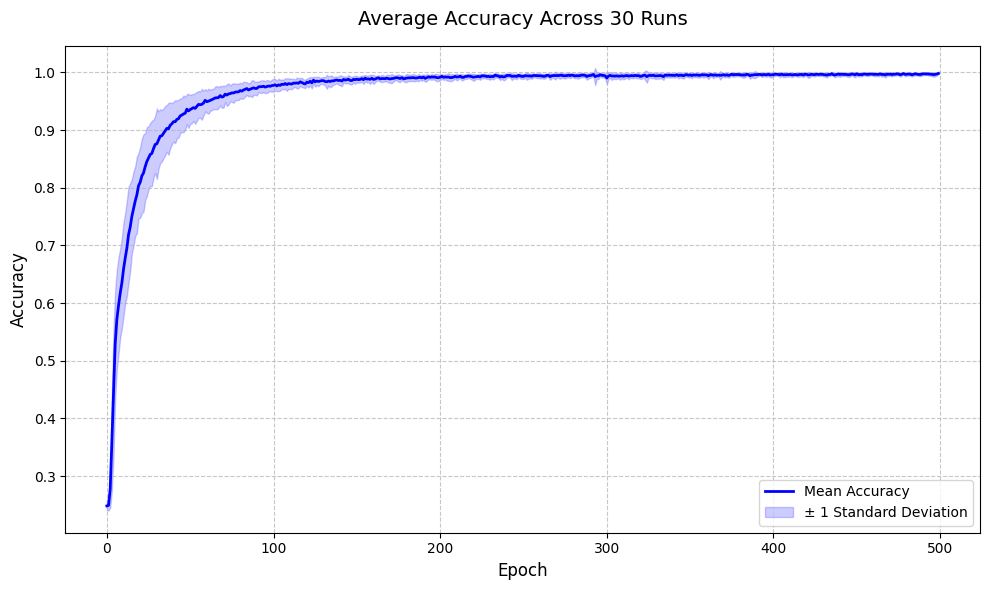

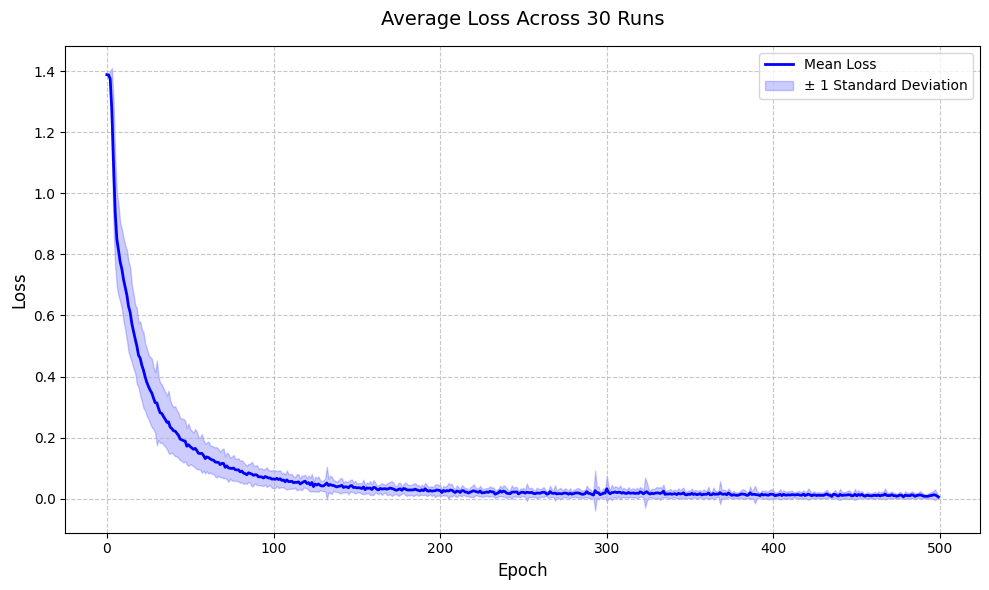

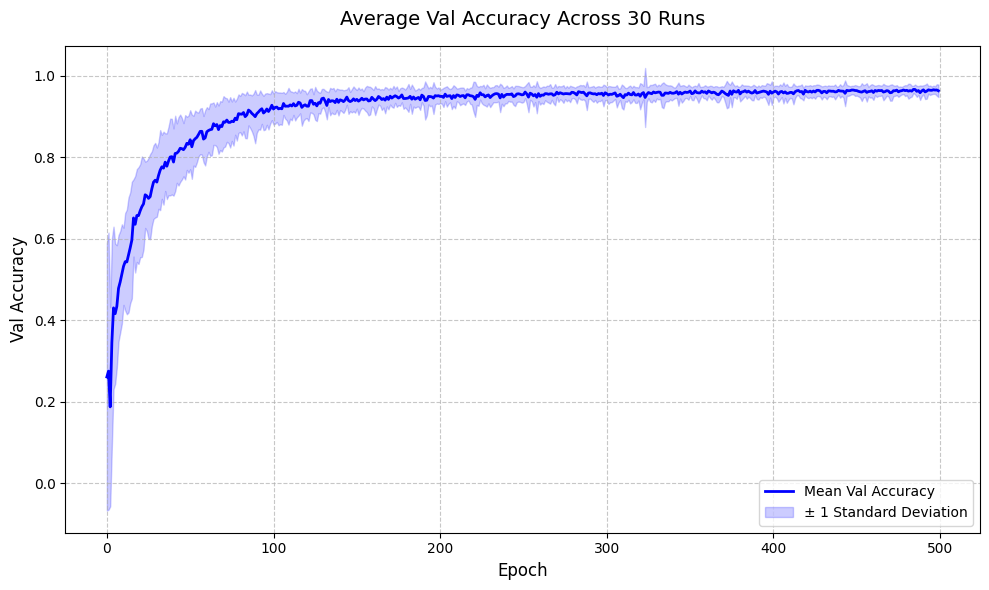

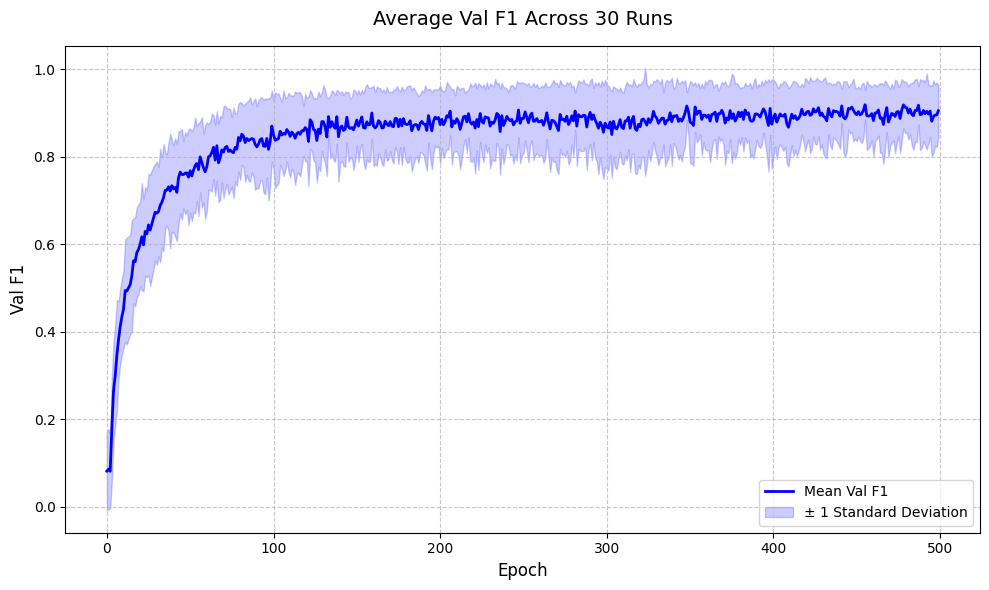

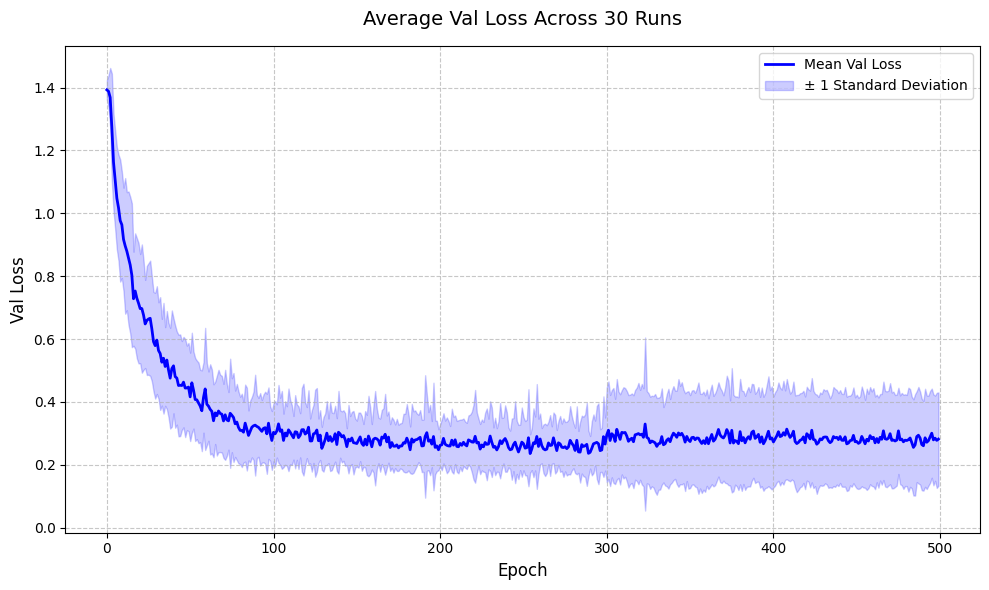

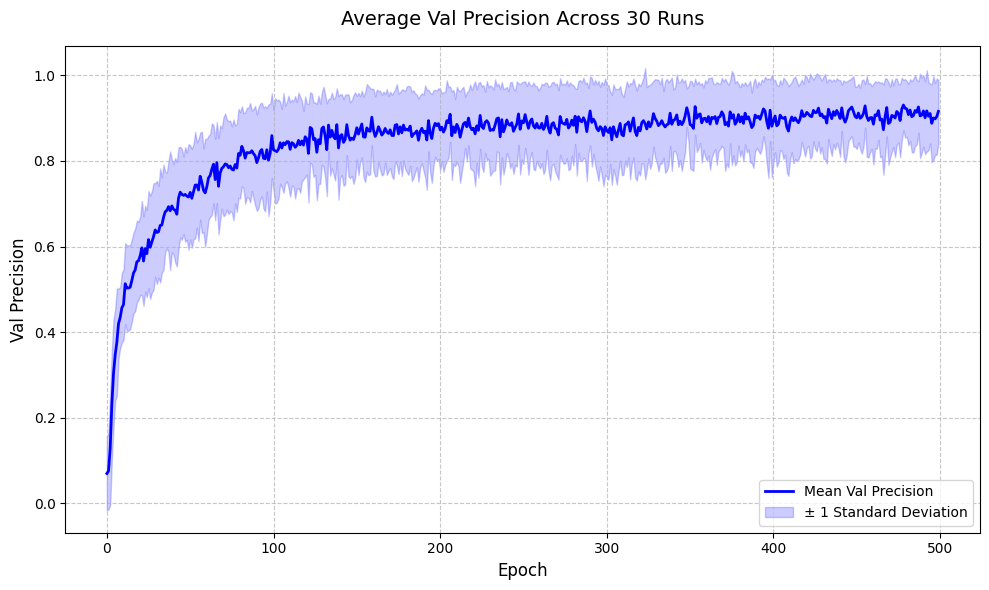

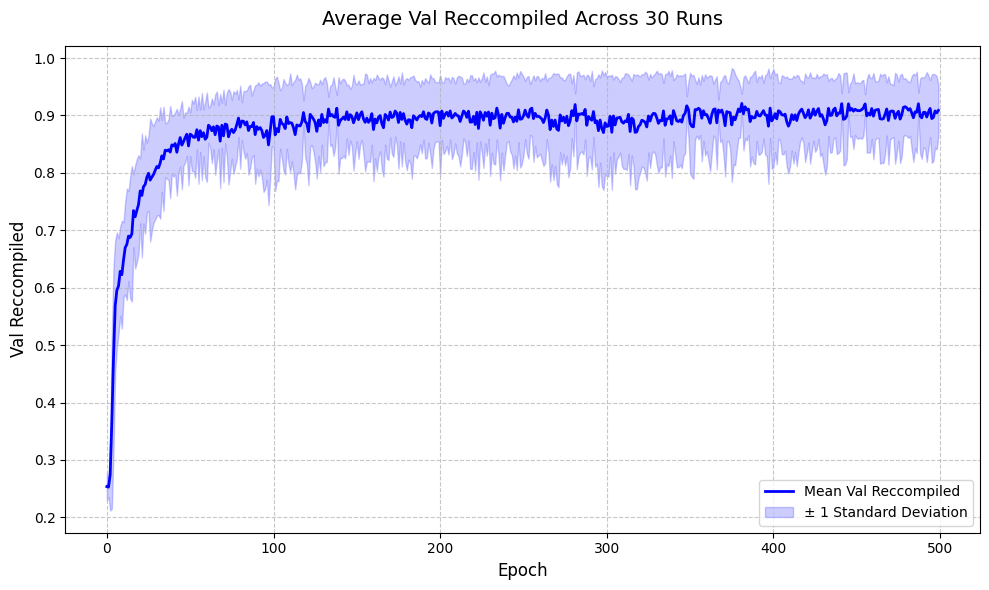

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

csv_directory = "/content/drive/My Drive/Colab Notebooks/models_history/multi_seed_runs"

compiled_files = [
    "all_accuracy_compiled.csv",
    "all_loss_compiled.csv",
    "all_val_accuracy_compiled.csv",
    "all_val_f1_compiled.csv",
    "all_val_loss.csv",
    "all_val_precision_compiled.csv",
    "all_val_recall_compiled.csv"
]

graphs_dir = os.path.join(csv_directory, "mean_graphs")
os.makedirs(graphs_dir, exist_ok=True)


for filename in compiled_files:
    filepath = os.path.join(csv_directory, filename)

    if not os.path.exists(filepath):
        print(f"Warning: Could not find {filename}. Skipping.")
        continue

    # Load the CSV
    df = pd.read_csv(filepath, index_col=0)

    # Calculate the mean and standard deviation across the columns (axis=1 means across runs)
    mean_series = df.mean(axis=1)
    std_series = df.std(axis=1)

    # Format the title
    metric_name = filename.replace("all_", "").replace("_compiled.csv", "").replace(".csv", "")
    display_title = metric_name.replace("_", " ").title()
    plt.figure(figsize=(10, 6))

    plt.plot(mean_series.index, mean_series, label=f'Mean {display_title}', color='blue', linewidth=2)

    plt.fill_between(
        mean_series.index,
        mean_series - std_series,
        mean_series + std_series,
        color='blue',
        alpha=0.2,
        label='± 1 Standard Deviation'
    )

    plt.title(f"Average {display_title} Across 30 Runs", fontsize=14, pad=15)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel(display_title, fontsize=12)

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(loc='best')
    plt.tight_layout()
    save_path = os.path.join(graphs_dir, f"{metric_name}_mean_plot.png")
    plt.savefig(save_path, dpi=300)
    plt.show()

Starting evaluation of 30 models on 284 test samples...
--------------------------------------------------
Loading Model 1/30...
Loading Model 2/30...
Loading Model 3/30...
Loading Model 4/30...
Loading Model 5/30...
Loading Model 6/30...
Loading Model 7/30...
Loading Model 8/30...
Loading Model 9/30...
Loading Model 10/30...
Loading Model 11/30...
Loading Model 12/30...
Loading Model 13/30...
Loading Model 14/30...
Loading Model 15/30...
Loading Model 16/30...
Loading Model 17/30...
Loading Model 18/30...
Loading Model 19/30...
Loading Model 20/30...
Loading Model 21/30...
Loading Model 22/30...
Loading Model 23/30...
Loading Model 24/30...
Loading Model 25/30...
Loading Model 26/30...
Loading Model 27/30...
Loading Model 28/30...
Loading Model 29/30...
Loading Model 30/30...
--------------------------------------------------
Successfully loaded and generated predictions for 30 models.

ENSEMBLE CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mi

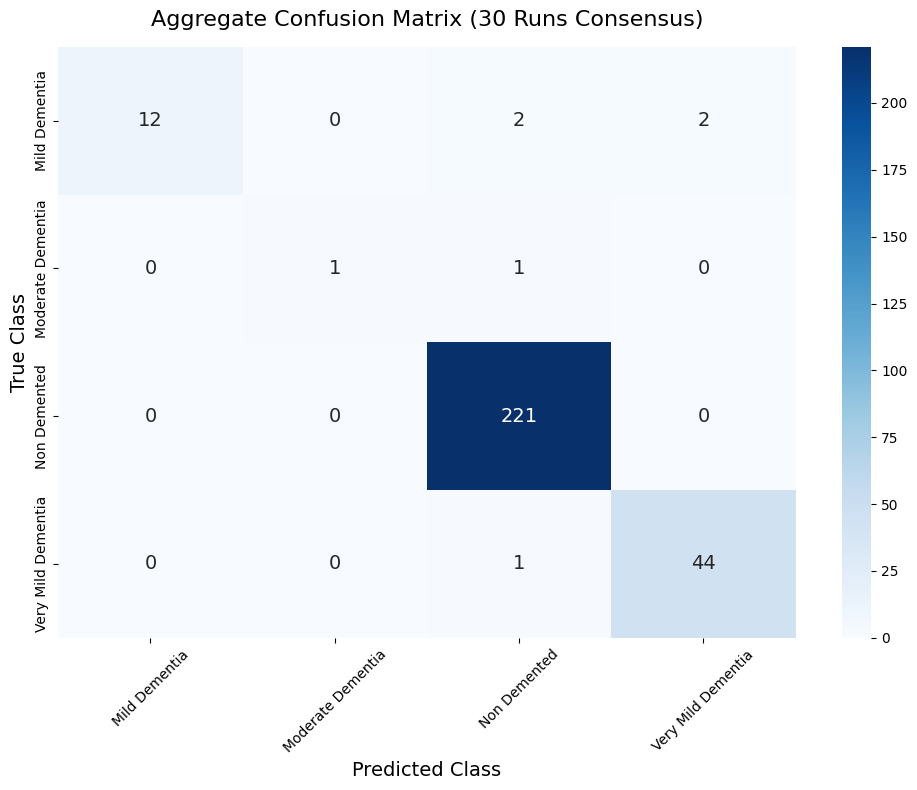

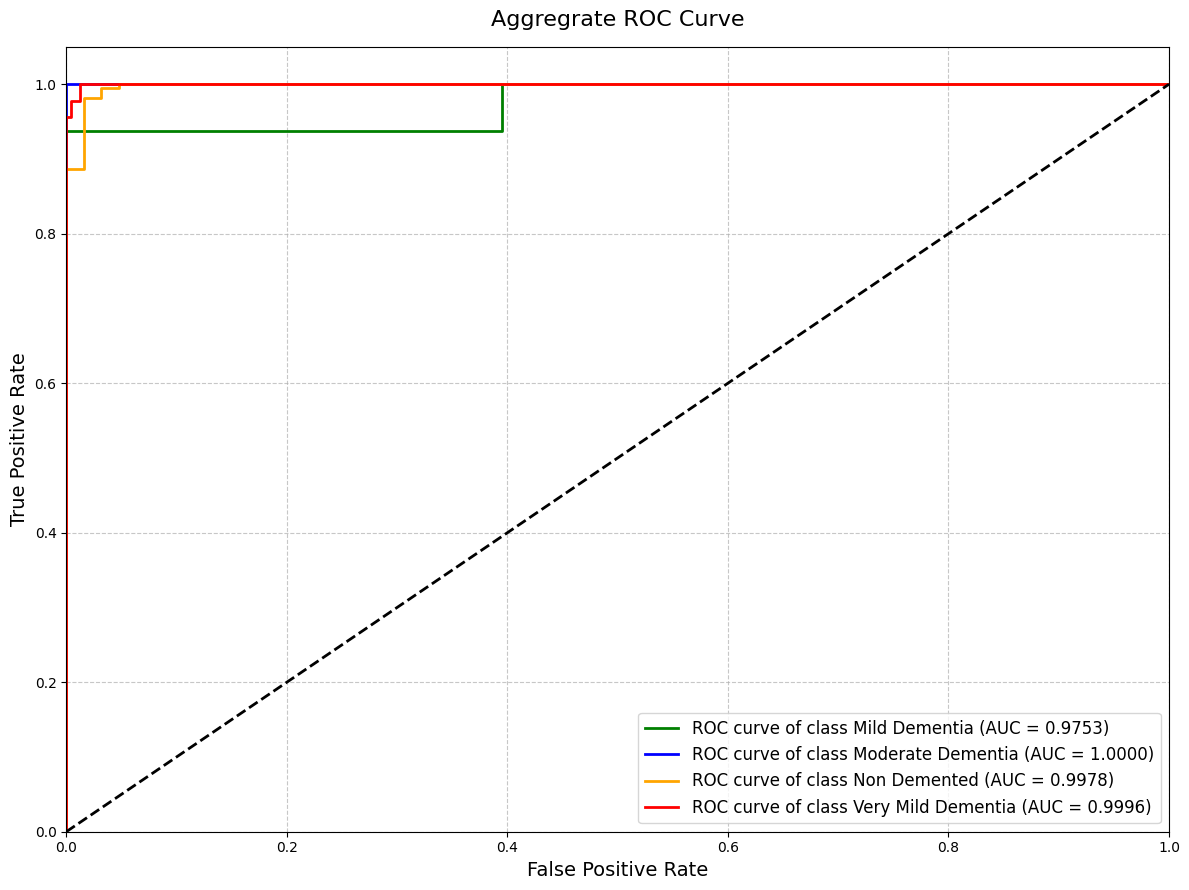

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize


base_models_dir = "/content/drive/My Drive/Colab Notebooks/models_history/multi_seed_runs"

class_labels = [c.replace('_', ' ').title() for c in lb.classes_]
num_classes = len(class_labels)

all_predictions = []
successful_loads = 0

print(f"Starting evaluation of 30 models on {len(X_test)} test samples...")
print("-" * 50)

for i in range(1, 31):
    model_path = os.path.join(base_models_dir, f"run_{i}_checkpoints", "best_model.keras")

    if os.path.exists(model_path):
        print(f"Loading Model {i}/30...")
        model = tf.keras.models.load_model(model_path)

        # Predict probabilities for the test set
        y_pred_probs = model.predict(X_test, verbose=0)
        all_predictions.append(y_pred_probs)
        successful_loads += 1
    else:
        print(f"Warning: Model {i} not found at {model_path}")

print("-" * 50)
print(f"Successfully loaded and generated predictions for {successful_loads} models.")

# Average the probabilities across all 30 models
ensemble_pred_probs = np.mean(all_predictions, axis=0)
y_true_classes = np.argmax(y_test, axis=1)
y_pred_classes = np.argmax(ensemble_pred_probs, axis=1)

print("\n" + "="*50)
print("ENSEMBLE CLASSIFICATION REPORT")
print("="*50)
report = classification_report(y_true_classes, y_pred_classes, target_names=class_labels, digits=4)
print(report)

# CONFUSION MATRIX
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            annot_kws={"size": 14})
plt.title('Aggregate Confusion Matrix (30 Runs Consensus)', fontsize=16, pad=15)
plt.ylabel('True Class', fontsize=14)
plt.xlabel('Predicted Class', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(base_models_dir, "ensemble_confusion_matrix.png"), dpi=300)
plt.show()

# MULTI-CLASS ROC CURVE
# Binarise the true labels for ROC calculations
y_test_bin = label_binarize(y_true_classes, classes=[0, 1, 2, 3])

plt.figure(figsize=(12, 9))
colors = ['green', 'blue', 'orange', 'red']

# Calculate ROC and AUC for each class
for i, color in zip(range(num_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], ensemble_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'ROC curve of class {class_labels[i]} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Aggregrate ROC Curve', fontsize=16, pad=15)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(base_models_dir, "ensemble_roc_curve.png"), dpi=300)
plt.show()

## no preprocess model

Generating predictions on the test dataset...
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 506ms/step

Non Pre-Process Classification Report
                    precision    recall  f1-score   support

     Mild Dementia     0.7692    0.6250    0.6897        16
 Moderate Dementia     1.0000    1.0000    1.0000         2
      Non Demented     0.9732    0.9864    0.9798       221
Very Mild Dementia     0.9333    0.9333    0.9333        45

          accuracy                         0.9577       284
         macro avg     0.9189    0.8862    0.9007       284
      weighted avg     0.9556    0.9577    0.9562       284


Saved Confusion Matrix to: /content/drive/My Drive/Colab Notebooks/models_history/nopreprocess/confusion_matrix.png


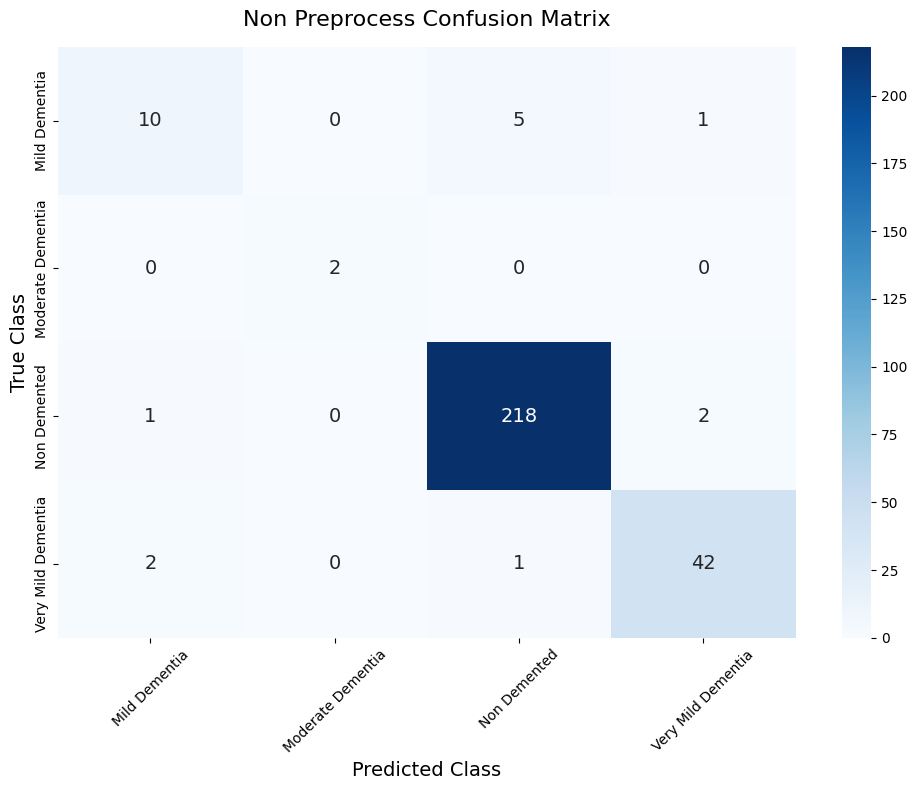

Saved ROC Curve to: /content/drive/My Drive/Colab Notebooks/models_history/nopreprocess/roc_curve.png


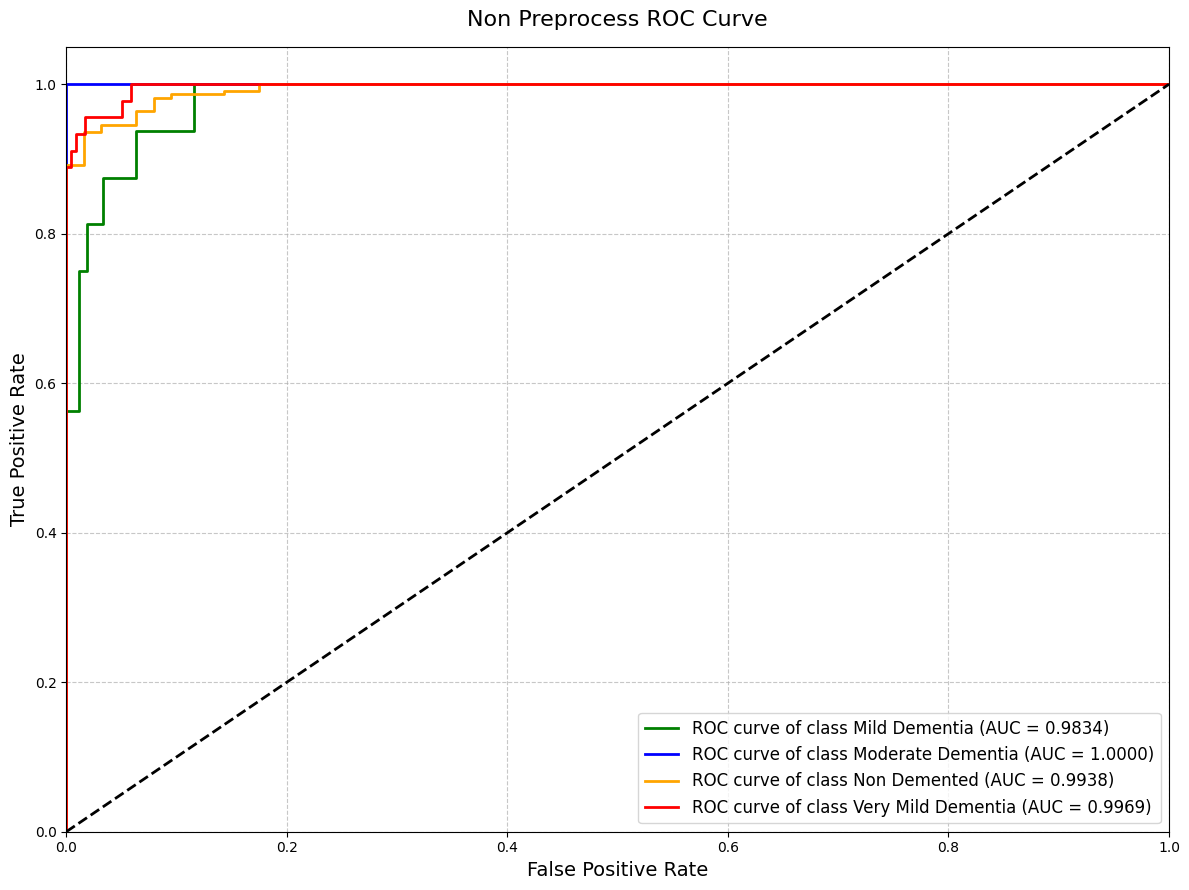

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize


model_path = "/content/drive/My Drive/Colab Notebooks/models_history/multi_seed_runs/run_31_checkpoints/best_model.keras"
output_dir = "/content/drive/My Drive/Colab Notebooks/models_history/nopreprocess"
os.makedirs(output_dir, exist_ok=True)


class_labels = [c.replace('_', ' ').title() for c in lb.classes_]
num_classes = len(class_labels)

model = tf.keras.models.load_model(model_path)

print("Generating predictions on the test dataset...")
y_pred_probs = model.predict(X_test)

# Convert one-hot/probabilities back to integer class indices
y_true_classes = np.argmax(y_test, axis=1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

print("\n" + "="*50)
print("Non Pre-Process Classification Report")
print("="*50)
report = classification_report(y_true_classes, y_pred_classes, target_names=class_labels, digits=4)
print(report)


# CONFUSION MATRIX
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            annot_kws={"size": 14})
plt.title('Non Preprocess Confusion Matrix', fontsize=16, pad=15)
plt.ylabel('True Class', fontsize=14)
plt.xlabel('Predicted Class', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
cm_save_path = os.path.join(output_dir, "confusion_matrix.png")
plt.savefig(cm_save_path, dpi=300)
print(f"\nSaved Confusion Matrix to: {cm_save_path}")
plt.show()

# MULTI-CLASS ROC CURVE
# Binarize the true labels to calculate One-vs-Rest ROC
y_test_bin = label_binarize(y_true_classes, classes=[0, 1, 2, 3])

plt.figure(figsize=(12, 9))
colors = ['green', 'blue', 'orange', 'red']

for i, color in zip(range(num_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'ROC curve of class {class_labels[i]} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Non Preprocess ROC Curve', fontsize=16, pad=15)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

roc_save_path = os.path.join(output_dir, "roc_curve.png")
plt.savefig(roc_save_path, dpi=300)
print(f"Saved ROC Curve to: {roc_save_path}")
plt.show()

## Hyper Parameter Tuning

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.callbacks import Callback, CSVLogger, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, TimeDistributed, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import f1_score, precision_score, recall_score

val_ds = prepare_dataset(X_val, y_val, batch_size=8)

# ==============================================================================
# METRICS LOGGER
# ==============================================================================
class AdvancedMetricsLogger(Callback):
    def __init__(self, validation_data, config_name):
        super().__init__()
        self.validation_data = validation_data
        self.config_name = config_name
        self.epoch_start_time = 0

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        epoch_time = time.time() - self.epoch_start_time

        X_val, y_val_true = self.validation_data
        y_pred_probs = self.model.predict(X_val, verbose=0)

        y_true_classes = np.argmax(y_val_true, axis=1)
        y_pred_classes = np.argmax(y_pred_probs, axis=1)

        val_f1 = f1_score(y_true_classes, y_pred_classes, average='macro')
        val_precision = precision_score(y_true_classes, y_pred_classes, average='macro', zero_division=0)
        val_recall = recall_score(y_true_classes, y_pred_classes, average='macro')

        logs['val_f1'] = val_f1
        logs['val_precision'] = val_precision
        logs['val_recall'] = val_recall
        logs['epoch_time_seconds'] = epoch_time

        print(f" - Epoch {epoch+1} - val_f1: {val_f1:.4f} - time: {epoch_time:.2f}s")

# ==============================================================================
# MODEL
# ==============================================================================
def build_hybrid_lstm(lstm_units=64, dropout_rate=0.5, learning_rate=0.001):
    model = Sequential([
        Input(shape=(61, 128, 128, 3)),
        TimeDistributed(tf.keras.layers.Rescaling(1./255)),

        TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same')),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same')),
        TimeDistributed(GlobalAveragePooling2D()),

        Bidirectional(LSTM(lstm_units, dropout=0.2)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dense(4, activation='softmax', dtype='float32')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ==============================================================================
# HYPERPARAMETER GRID & TARGETS
# ==============================================================================
hyperparameter_grid = {
    '1': {'lr': 0.001,  'lstm_units': 64,  'dropout': 0.5,},
    '2': {'lr': 0.0001, 'lstm_units': 64,  'dropout': 0.5},
    '3': {'lr': 0.001,  'lstm_units': 128, 'dropout': 0.6},
    '4': {'lr': 0.001,  'lstm_units': 32,  'dropout': 0.3},
}

TARGET_RUNS = ['1', '2']
TOTAL_EPOCHS = 400

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
tf.random.set_seed(SEED)
np.random.seed(SEED)

base_save_dir = "/content/drive/My Drive/Colab Notebooks/models_history/hyperparameter_tuning"
os.makedirs(base_save_dir, exist_ok=True)

# AUTOMATED EXECUTION LOOP
for run_name in TARGET_RUNS:
    config = hyperparameter_grid[run_name]

    print(f"\n{'='*50}")
    print(f"EVALUATING CONFIG: {run_name}")
    print(f"Hyperparameters: LR={config['lr']}, LSTM={config['lstm_units']}, Dropout={config['dropout']}")
    print(f"{'='*50}")

    run_dir = os.path.join(base_save_dir, f"{run_name}_checkpoints")
    os.makedirs(run_dir, exist_ok=True)

    last_model_path = os.path.join(run_dir, "last_model.keras")
    best_model_path = os.path.join(run_dir, "best_model.keras")
    run_csv_path = os.path.join(base_save_dir, f"{run_name}_metrics.csv")

    initial_epoch = 0
    model = None
    append_csv = False

    # --- RESUME LOGIC ---
    if os.path.exists(last_model_path) and os.path.exists(run_csv_path):
        print(f"-> Found existing checkpoint for {run_name}. Resuming training...")

        model = tf.keras.models.load_model(last_model_path)

        log_df = pd.read_csv(run_csv_path)
        if not log_df.empty:
            initial_epoch = log_df['epoch'].max() + 1

        if initial_epoch >= TOTAL_EPOCHS:
            print(f"-> Run {run_name} has already completed {TOTAL_EPOCHS} epochs. Skipping to next configuration.")
            continue

        print(f"-> Resuming from Epoch {initial_epoch}")
        append_csv = True

    else:
        print(f"-> Starting fresh run for {run_name}...")
        model = build_hybrid_lstm(
            lstm_units=config['lstm_units'],
            dropout_rate=config['dropout'],
            learning_rate=config['lr']
        )
        append_csv = False

    # --- SET UP CALLBACKS ---
    csv_logger = CSVLogger(run_csv_path, append=append_csv)
    advanced_logger = AdvancedMetricsLogger(validation_data=(X_val, y_val), config_name=run_name)

    checkpoint_last = ModelCheckpoint(
        filepath=last_model_path,
        save_best_only=False,
        verbose=0
    )

    checkpoint_best = ModelCheckpoint(
        filepath=best_model_path,
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    )

    # --- TRAIN THE MODEL ---
    try:
        model.fit(
            X_train, y_train,
            validation_data=val_ds,
            epochs=TOTAL_EPOCHS,
            initial_epoch=initial_epoch,
            batch_size=8,
            shuffle=True,
            callbacks=[advanced_logger, csv_logger, checkpoint_last, checkpoint_best],
            verbose=1
        )
    except KeyboardInterrupt:
        print(f"\nUser interrupted at {run_name}. Saving current progress and exiting loop.")
        break

print(f"\nTarget runs {TARGET_RUNS} processing complete!")


EVALUATING CONFIG: 1
Hyperparameters: LR=0.001, LSTM=64, Dropout=0.5
-> Starting fresh run for 1...
Epoch 1/400
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.2607 - loss: 1.3878 - Epoch 1 - val_f1: 0.2191 - time: 78.09s

Epoch 1: val_loss improved from None to 1.35355, saving model to /content/drive/My Drive/Colab Notebooks/models_history/hyperparameter_tuning/1_checkpoints/best_model.keras

Epoch 1: finished saving model to /content/drive/My Drive/Colab Notebooks/models_history/hyperparameter_tuning/1_checkpoints/best_model.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 80s 218ms/step - accuracy: 0.2564 - loss: 1.3882 - val_accuracy: 0.7797 - val_loss: 1.3535 - val_f1: 0.2191 - val_precision: 0.1949 - val_recall: 0.2500 - epoch_time_seconds: 78.0884
Epoch 2/400
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.2401 - loss: 1.3845 - Epoch 2 - val_f1: 0.0738 - time: 73.51s

Epoch 2: val_loss improved from 1.35355 to 1.32642, saving model to /content/drive/My Drive/Colab Notebooks

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.callbacks import Callback, CSVLogger, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, TimeDistributed, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import f1_score, precision_score, recall_score

val_ds = prepare_dataset(X_val, y_val, batch_size=8)

# ==============================================================================
# METRICS LOGGER
# ==============================================================================
class AdvancedMetricsLogger(Callback):
    def __init__(self, validation_data, config_name):
        super().__init__()
        self.validation_data = validation_data
        self.config_name = config_name
        self.epoch_start_time = 0

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        epoch_time = time.time() - self.epoch_start_time

        X_val, y_val_true = self.validation_data
        y_pred_probs = self.model.predict(X_val, verbose=0)

        y_true_classes = np.argmax(y_val_true, axis=1)
        y_pred_classes = np.argmax(y_pred_probs, axis=1)

        val_f1 = f1_score(y_true_classes, y_pred_classes, average='macro')
        val_precision = precision_score(y_true_classes, y_pred_classes, average='macro', zero_division=0)
        val_recall = recall_score(y_true_classes, y_pred_classes, average='macro')

        logs['val_f1'] = val_f1
        logs['val_precision'] = val_precision
        logs['val_recall'] = val_recall
        logs['epoch_time_seconds'] = epoch_time

        print(f" - Epoch {epoch+1} - val_f1: {val_f1:.4f} - time: {epoch_time:.2f}s")

# ==============================================================================
# MODEL
# ==============================================================================
def build_hybrid_lstm(lstm_units=64, dropout_rate=0.5, learning_rate=0.001):
    model = Sequential([
        Input(shape=(61, 128, 128, 3)),
        TimeDistributed(tf.keras.layers.Rescaling(1./255)),

        TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same')),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same')),
        TimeDistributed(GlobalAveragePooling2D()),

        Bidirectional(LSTM(lstm_units, dropout=0.2)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dense(4, activation='softmax', dtype='float32')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ==============================================================================
# HYPERPARAMETER GRID & TARGETS
# ==============================================================================
hyperparameter_grid = {
    '1': {'lr': 0.001,  'lstm_units': 64,  'dropout': 0.5,},
    '2': {'lr': 0.0001, 'lstm_units': 64,  'dropout': 0.5},
    '3': {'lr': 0.001,  'lstm_units': 128, 'dropout': 0.6},
    '4': {'lr': 0.001,  'lstm_units': 32,  'dropout': 0.3},
    '5': {'lr': 0.01,  'lstm_units': 64,  'dropout': 0.5},
}

TARGET_RUNS = ['3', '4']
TOTAL_EPOCHS = 400

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
tf.random.set_seed(SEED)
np.random.seed(SEED)

base_save_dir = "/content/drive/My Drive/Colab Notebooks/models_history/hyperparameter_tuning"
os.makedirs(base_save_dir, exist_ok=True)

# ==============================================================================
# EXECUTION LOOP
# ==============================================================================
for run_name in TARGET_RUNS:
    config = hyperparameter_grid[run_name]

    print(f"\n{'='*50}")
    print(f"EVALUATING CONFIG: {run_name}")
    print(f"Hyperparameters: LR={config['lr']}, LSTM={config['lstm_units']}, Dropout={config['dropout']}")
    print(f"{'='*50}")

    run_dir = os.path.join(base_save_dir, f"{run_name}_checkpoints")
    os.makedirs(run_dir, exist_ok=True)

    last_model_path = os.path.join(run_dir, "last_model.keras")
    best_model_path = os.path.join(run_dir, "best_model.keras")
    run_csv_path = os.path.join(base_save_dir, f"{run_name}_metrics.csv")

    initial_epoch = 0
    model = None
    append_csv = False

    # --- RESUME LOGIC ---
    if os.path.exists(last_model_path) and os.path.exists(run_csv_path):
        print(f"-> Found existing checkpoint for {run_name}. Resuming training...")

        model = tf.keras.models.load_model(last_model_path)

        log_df = pd.read_csv(run_csv_path)
        if not log_df.empty:
            initial_epoch = log_df['epoch'].max() + 1

        if initial_epoch >= TOTAL_EPOCHS:
            print(f"-> Run {run_name} has already completed {TOTAL_EPOCHS} epochs. Skipping to next configuration.")
            continue

        print(f"-> Resuming from Epoch {initial_epoch}")
        append_csv = True

    else:
        print(f"-> Starting fresh run for {run_name}...")
        model = build_hybrid_lstm(
            lstm_units=config['lstm_units'],
            dropout_rate=config['dropout'],
            learning_rate=config['lr']
        )
        append_csv = False

    # --- SET UP CALLBACKS ---
    csv_logger = CSVLogger(run_csv_path, append=append_csv)
    advanced_logger = AdvancedMetricsLogger(validation_data=(X_val, y_val), config_name=run_name)

    checkpoint_last = ModelCheckpoint(
        filepath=last_model_path,
        save_best_only=False,
        verbose=0
    )

    checkpoint_best = ModelCheckpoint(
        filepath=best_model_path,
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    )

    # --- TRAIN THE MODEL ---
    try:
        model.fit(
            X_train, y_train,
            validation_data=val_ds,
            epochs=TOTAL_EPOCHS,
            initial_epoch=initial_epoch,
            batch_size=8,
            shuffle=True,
            callbacks=[advanced_logger, csv_logger, checkpoint_last, checkpoint_best],
            verbose=1
        )
    except KeyboardInterrupt:
        print(f"\nUser interrupted at {run_name}. Saving current progress and exiting loop.")
        break

print(f"\nTarget runs {TARGET_RUNS} processing complete!")


EVALUATING CONFIG: 3
Hyperparameters: LR=0.001, LSTM=128, Dropout=0.6
-> Starting fresh run for 3...
Epoch 1/400
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.2310 - loss: 1.3897 - Epoch 1 - val_f1: 0.0684 - time: 78.45s

Epoch 1: val_loss improved from None to 1.35979, saving model to /content/drive/My Drive/Colab Notebooks/models_history/hyperparameter_tuning/3_checkpoints/best_model.keras

Epoch 1: finished saving model to /content/drive/My Drive/Colab Notebooks/models_history/hyperparameter_tuning/3_checkpoints/best_model.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 81s 218ms/step - accuracy: 0.2500 - loss: 1.3888 - val_accuracy: 0.1586 - val_loss: 1.3598 - val_f1: 0.0684 - val_precision: 0.0396 - val_recall: 0.2500 - epoch_time_seconds: 78.4514
Epoch 2/400
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.2618 - loss: 1.3885 - Epoch 2 - val_f1: 0.0684 - time: 73.64s

Epoch 2: val_loss did not improve from 1.35979
352/352 ━━━━━━━━━━━━━━━━━━━━ 74s 211ms/step - accuracy: 0.2

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.callbacks import Callback, CSVLogger, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, TimeDistributed, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import f1_score, precision_score, recall_score

val_ds = prepare_dataset(X_val, y_val, batch_size=8)

# ==============================================================================
# METRICS LOGGER
# ==============================================================================
class AdvancedMetricsLogger(Callback):
    def __init__(self, validation_data, config_name):
        super().__init__()
        self.validation_data = validation_data
        self.config_name = config_name
        self.epoch_start_time = 0

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        epoch_time = time.time() - self.epoch_start_time

        X_val, y_val_true = self.validation_data
        y_pred_probs = self.model.predict(X_val, verbose=0)

        y_true_classes = np.argmax(y_val_true, axis=1)
        y_pred_classes = np.argmax(y_pred_probs, axis=1)

        val_f1 = f1_score(y_true_classes, y_pred_classes, average='macro')
        val_precision = precision_score(y_true_classes, y_pred_classes, average='macro', zero_division=0)
        val_recall = recall_score(y_true_classes, y_pred_classes, average='macro')

        logs['val_f1'] = val_f1
        logs['val_precision'] = val_precision
        logs['val_recall'] = val_recall
        logs['epoch_time_seconds'] = epoch_time

        print(f" - Epoch {epoch+1} - val_f1: {val_f1:.4f} - time: {epoch_time:.2f}s")

# ==============================================================================
# MODEL
# ==============================================================================
def build_hybrid_lstm(lstm_units=64, dropout_rate=0.5, learning_rate=0.001):
    model = Sequential([
        Input(shape=(61, 128, 128, 3)),
        TimeDistributed(tf.keras.layers.Rescaling(1./255)),

        TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same')),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same')),
        TimeDistributed(GlobalAveragePooling2D()),

        Bidirectional(LSTM(lstm_units, dropout=0.2)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dense(4, activation='softmax', dtype='float32')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ==============================================================================
# HYPERPARAMETER GRID & TARGETS
# ==============================================================================
hyperparameter_grid = {
    '1': {'lr': 0.001,  'lstm_units': 64,  'dropout': 0.5,},
    '2': {'lr': 0.0001, 'lstm_units': 64,  'dropout': 0.5},
    '3': {'lr': 0.001,  'lstm_units': 128, 'dropout': 0.6},
    '4': {'lr': 0.001,  'lstm_units': 32,  'dropout': 0.3},
}

TARGET_RUNS = ['2', '3','4']
TOTAL_EPOCHS = 400

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
tf.random.set_seed(SEED)
np.random.seed(SEED)

base_save_dir = "/content/drive/My Drive/Colab Notebooks/models_history/hyperparameter_tuning"
os.makedirs(base_save_dir, exist_ok=True)

# ==============================================================================
# EXECUTION LOOP
# ==============================================================================
for run_name in TARGET_RUNS:
    config = hyperparameter_grid[run_name]

    print(f"\n{'='*50}")
    print(f"EVALUATING CONFIG: {run_name}")
    print(f"Hyperparameters: LR={config['lr']}, LSTM={config['lstm_units']}, Dropout={config['dropout']}")
    print(f"{'='*50}")

    run_dir = os.path.join(base_save_dir, f"{run_name}_checkpoints")
    os.makedirs(run_dir, exist_ok=True)

    last_model_path = os.path.join(run_dir, "last_model.keras")
    best_model_path = os.path.join(run_dir, "best_model.keras")
    run_csv_path = os.path.join(base_save_dir, f"{run_name}_metrics.csv")

    initial_epoch = 0
    model = None
    append_csv = False

    # --- RESUME LOGIC ---
    if os.path.exists(last_model_path) and os.path.exists(run_csv_path):
        print(f"-> Found existing checkpoint for {run_name}. Resuming training...")

        model = tf.keras.models.load_model(last_model_path)

        log_df = pd.read_csv(run_csv_path)
        if not log_df.empty:
            initial_epoch = log_df['epoch'].max() + 1

        if initial_epoch >= TOTAL_EPOCHS:
            print(f"-> Run {run_name} has already completed {TOTAL_EPOCHS} epochs. Skipping to next configuration.")
            continue

        print(f"-> Resuming from Epoch {initial_epoch}")
        append_csv = True

    else:
        print(f"-> Starting fresh run for {run_name}...")
        model = build_hybrid_lstm(
            lstm_units=config['lstm_units'],
            dropout_rate=config['dropout'],
            learning_rate=config['lr']
        )
        append_csv = False

    # --- SET UP CALLBACKS ---
    csv_logger = CSVLogger(run_csv_path, append=append_csv)
    advanced_logger = AdvancedMetricsLogger(validation_data=(X_val, y_val), config_name=run_name)

    checkpoint_last = ModelCheckpoint(
        filepath=last_model_path,
        save_best_only=False,
        verbose=0
    )

    checkpoint_best = ModelCheckpoint(
        filepath=best_model_path,
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    )

    # --- TRAIN THE MODEL ---
    try:
        model.fit(
            X_train, y_train,
            validation_data=val_ds,
            epochs=TOTAL_EPOCHS,
            initial_epoch=initial_epoch,
            batch_size=8,
            shuffle=True,
            callbacks=[advanced_logger, csv_logger, checkpoint_last, checkpoint_best],
            verbose=1
        )
    except KeyboardInterrupt:
        print(f"\nUser interrupted at {run_name}. Saving current progress and exiting loop.")
        break

print(f"\nTarget runs {TARGET_RUNS} processing complete!")


EVALUATING CONFIG: 2
Hyperparameters: LR=0.0001, LSTM=64, Dropout=0.5
-> Found existing checkpoint for 2. Resuming training...
-> Resuming from Epoch 242
Epoch 243/400
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9011 - loss: 0.2419 - Epoch 243 - val_f1: 0.8743 - time: 108.31s

Epoch 243: val_loss improved from None to 0.27605, saving model to /content/drive/My Drive/Colab Notebooks/models_history/hyperparameter_tuning/2_checkpoints/best_model.keras

Epoch 243: finished saving model to /content/drive/My Drive/Colab Notebooks/models_history/hyperparameter_tuning/2_checkpoints/best_model.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 112s 224ms/step - accuracy: 0.9013 - loss: 0.2480 - val_accuracy: 0.8855 - val_loss: 0.2761 - val_f1: 0.8743 - val_precision: 0.8400 - val_recall: 0.9289 - epoch_time_seconds: 108.3116
Epoch 244/400
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9048 - loss: 0.2406 - Epoch 244 - val_f1: 0.8229 - time: 73.60s

Epoch 244: val_loss did not improve fr

##hyperparameter evaluation


Generating predictions on the test dataset...
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 496ms/step

Hyperparameter 1 Classification Report
                    precision    recall  f1-score   support

     Mild Dementia     0.9231    0.7500    0.8276        16
 Moderate Dementia     1.0000    1.0000    1.0000         2
      Non Demented     0.9908    0.9729    0.9817       221
Very Mild Dementia     0.8462    0.9778    0.9072        45

          accuracy                         0.9613       284
         macro avg     0.9400    0.9252    0.9291       284
      weighted avg     0.9641    0.9613    0.9614       284


Saved Confusion Matrix to: /content/drive/My Drive/Colab Notebooks/models_history/hyperparameter 1/confusion_matrix.png


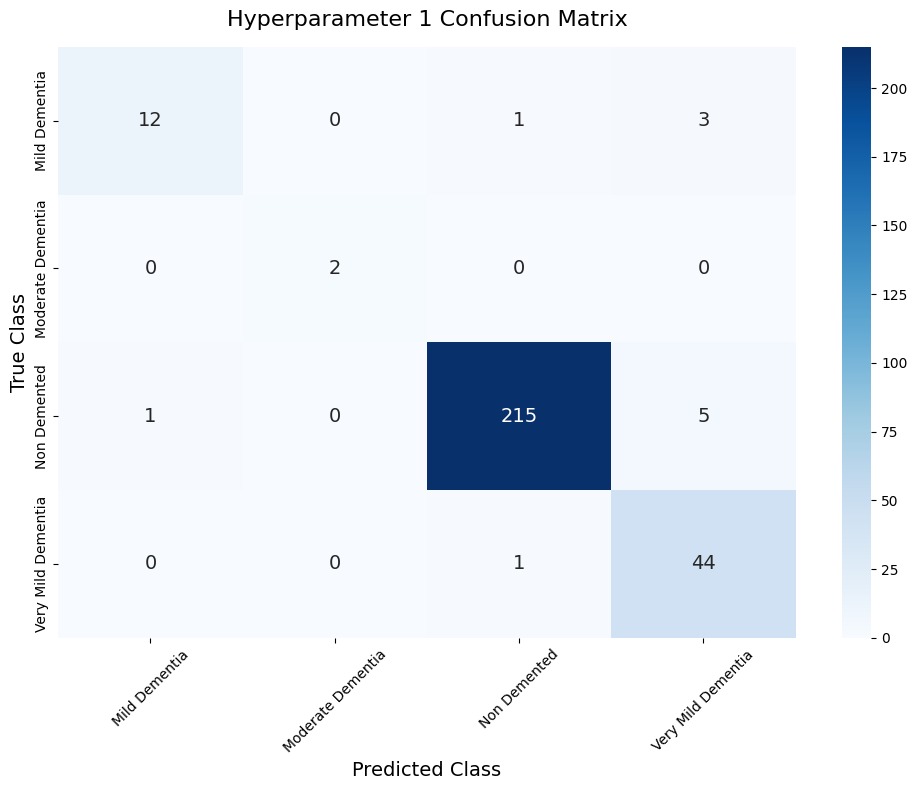

Saved ROC Curve to: /content/drive/My Drive/Colab Notebooks/models_history/hyperparameter 1/roc_curve.png


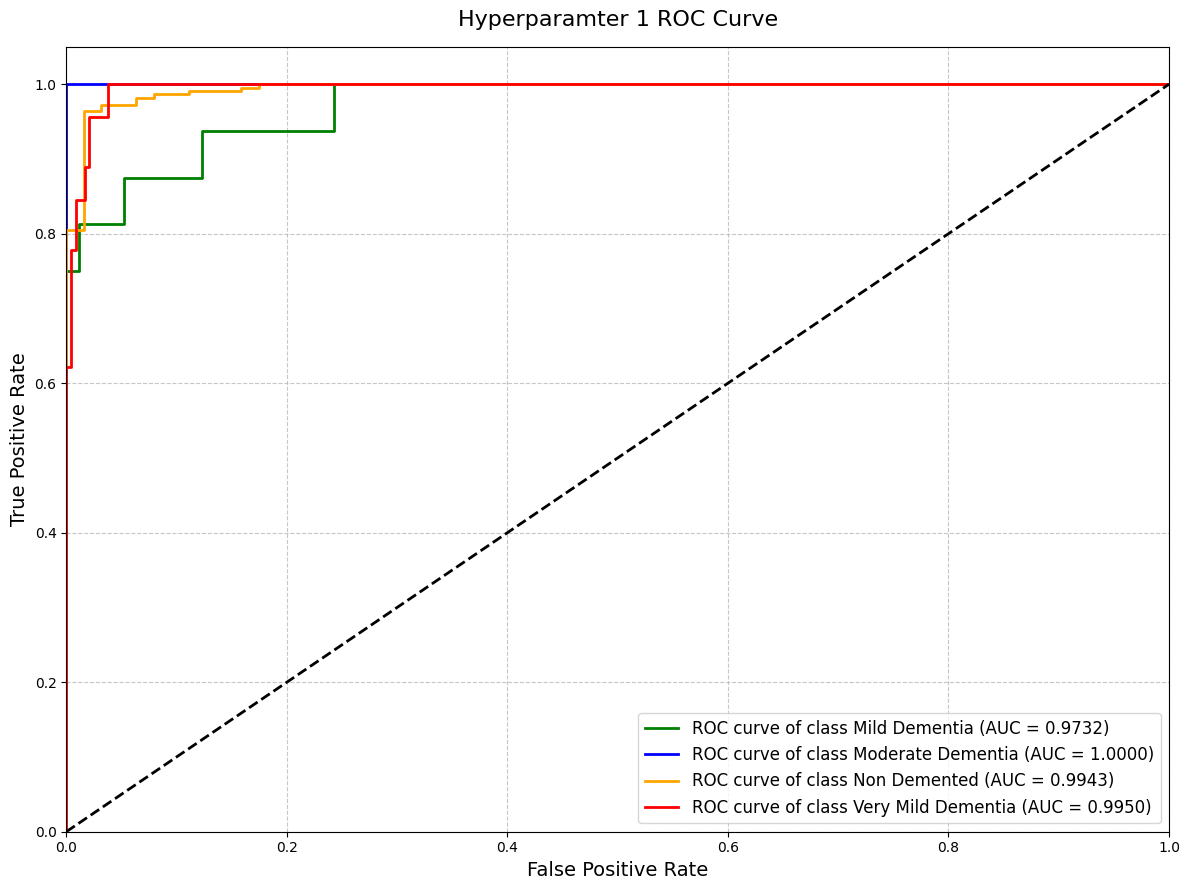

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize


model_path = "/content/drive/My Drive/Colab Notebooks/models_history/hyperparameter_tuning/1_checkpoints/best_model.keras"
output_dir = "/content/drive/My Drive/Colab Notebooks/models_history/hyperparameter 1"
os.makedirs(output_dir, exist_ok=True)


class_labels = [c.replace('_', ' ').title() for c in lb.classes_]
num_classes = len(class_labels)

model = tf.keras.models.load_model(model_path)

print("Generating predictions on the test dataset...")
y_pred_probs = model.predict(X_test)

# Convert one-hot/probabilities back to integer class indices
y_true_classes = np.argmax(y_test, axis=1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

print("\n" + "="*50)
print("Hyperparameter 1 Classification Report")
print("="*50)
report = classification_report(y_true_classes, y_pred_classes, target_names=class_labels, digits=4)
print(report)


# CONFUSION MATRIX
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            annot_kws={"size": 14})
plt.title('Hyperparameter 1 Confusion Matrix', fontsize=16, pad=15)
plt.ylabel('True Class', fontsize=14)
plt.xlabel('Predicted Class', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
cm_save_path = os.path.join(output_dir, "confusion_matrix.png")
plt.savefig(cm_save_path, dpi=300)
print(f"\nSaved Confusion Matrix to: {cm_save_path}")
plt.show()

# MULTI-CLASS ROC CURVE
# Binarize the true labels to calculate One-vs-Rest ROC
y_test_bin = label_binarize(y_true_classes, classes=[0, 1, 2, 3])

plt.figure(figsize=(12, 9))
colors = ['green', 'blue', 'orange', 'red']

for i, color in zip(range(num_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'ROC curve of class {class_labels[i]} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Hyperparamter 1 ROC Curve', fontsize=16, pad=15)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

roc_save_path = os.path.join(output_dir, "roc_curve.png")
plt.savefig(roc_save_path, dpi=300)
print(f"Saved ROC Curve to: {roc_save_path}")
plt.show()

Generating predictions on the test dataset...
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 500ms/step

Hyperparameter 2 Classification Report
                    precision    recall  f1-score   support

     Mild Dementia     0.8235    0.8750    0.8485        16
 Moderate Dementia     0.5000    0.5000    0.5000         2
      Non Demented     0.9799    0.8824    0.9286       221
Very Mild Dementia     0.6667    0.9778    0.7928        45

          accuracy                         0.8944       284
         macro avg     0.7425    0.8088    0.7675       284
      weighted avg     0.9181    0.8944    0.8995       284


Saved Confusion Matrix to: /content/drive/My Drive/Colab Notebooks/models_history/hyperparameter 2/confusion_matrix.png


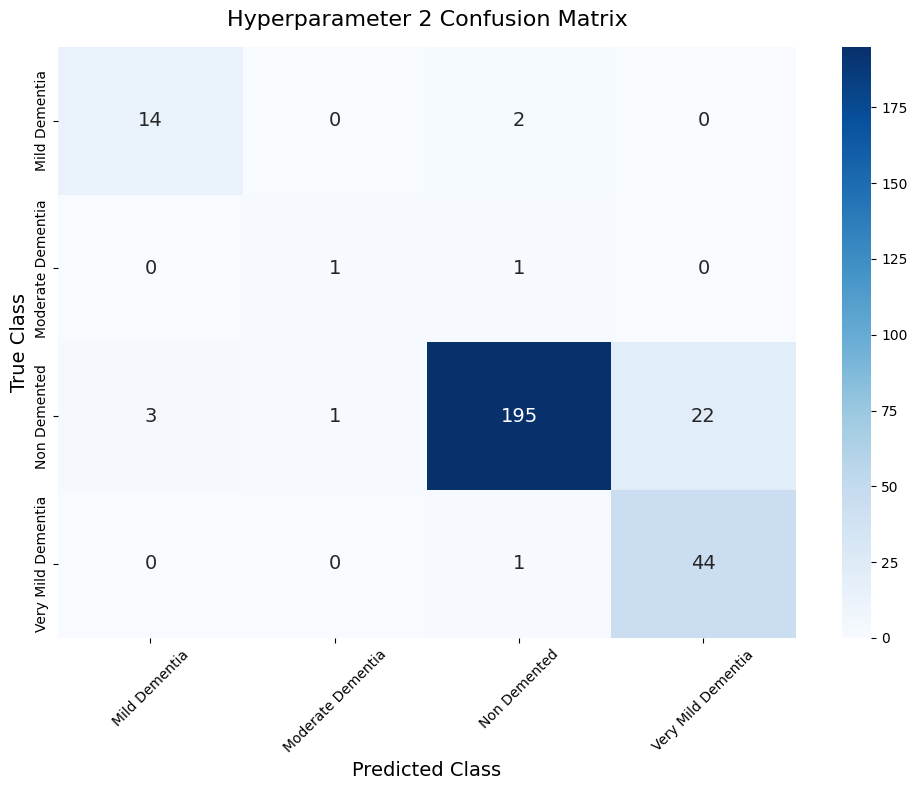

Saved ROC Curve to: /content/drive/My Drive/Colab Notebooks/models_history/hyperparameter 2/roc_curve.png


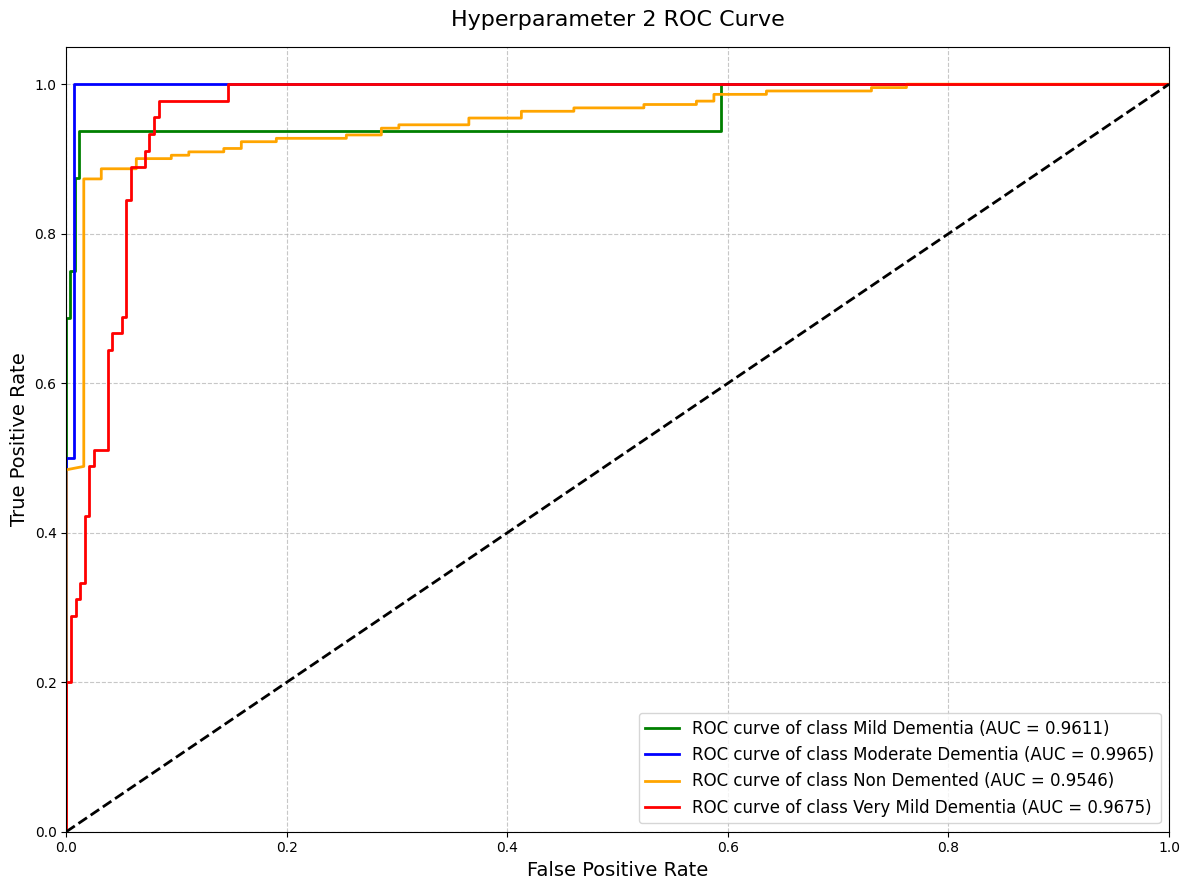

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize


model_path = "/content/drive/My Drive/Colab Notebooks/models_history/hyperparameter_tuning/2_checkpoints/best_model.keras"
output_dir = "/content/drive/My Drive/Colab Notebooks/models_history/hyperparameter 2"
os.makedirs(output_dir, exist_ok=True)


class_labels = [c.replace('_', ' ').title() for c in lb.classes_]
num_classes = len(class_labels)

model = tf.keras.models.load_model(model_path)

print("Generating predictions on the test dataset...")
y_pred_probs = model.predict(X_test)

# Convert one-hot/probabilities back to integer class indices
y_true_classes = np.argmax(y_test, axis=1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

print("\n" + "="*50)
print("Hyperparameter 2 Classification Report")
print("="*50)
report = classification_report(y_true_classes, y_pred_classes, target_names=class_labels, digits=4)
print(report)


# CONFUSION MATRIX
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            annot_kws={"size": 14})
plt.title('Hyperparameter 2 Confusion Matrix', fontsize=16, pad=15)
plt.ylabel('True Class', fontsize=14)
plt.xlabel('Predicted Class', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
cm_save_path = os.path.join(output_dir, "confusion_matrix.png")
plt.savefig(cm_save_path, dpi=300)
print(f"\nSaved Confusion Matrix to: {cm_save_path}")
plt.show()

# MULTI-CLASS ROC CURVE
# Binarize the true labels to calculate One-vs-Rest ROC
y_test_bin = label_binarize(y_true_classes, classes=[0, 1, 2, 3])

plt.figure(figsize=(12, 9))
colors = ['green', 'blue', 'orange', 'red']

for i, color in zip(range(num_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'ROC curve of class {class_labels[i]} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Hyperparameter 2 ROC Curve', fontsize=16, pad=15)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

roc_save_path = os.path.join(output_dir, "roc_curve.png")
plt.savefig(roc_save_path, dpi=300)
print(f"Saved ROC Curve to: {roc_save_path}")
plt.show()

Generating predictions on the test dataset...
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 496ms/step

Hyperparameter 3 Classification Report
                    precision    recall  f1-score   support

     Mild Dementia     0.7778    0.4375    0.5600        16
 Moderate Dementia     0.0000    0.0000    0.0000         2
      Non Demented     0.8874    0.9276    0.9071       221
Very Mild Dementia     0.6364    0.6222    0.6292        45

          accuracy                         0.8451       284
         macro avg     0.5754    0.4968    0.5241       284
      weighted avg     0.8352    0.8451    0.8371       284



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Saved Confusion Matrix to: /content/drive/My Drive/Colab Notebooks/models_history/hyperparameter 3/confusion_matrix.png


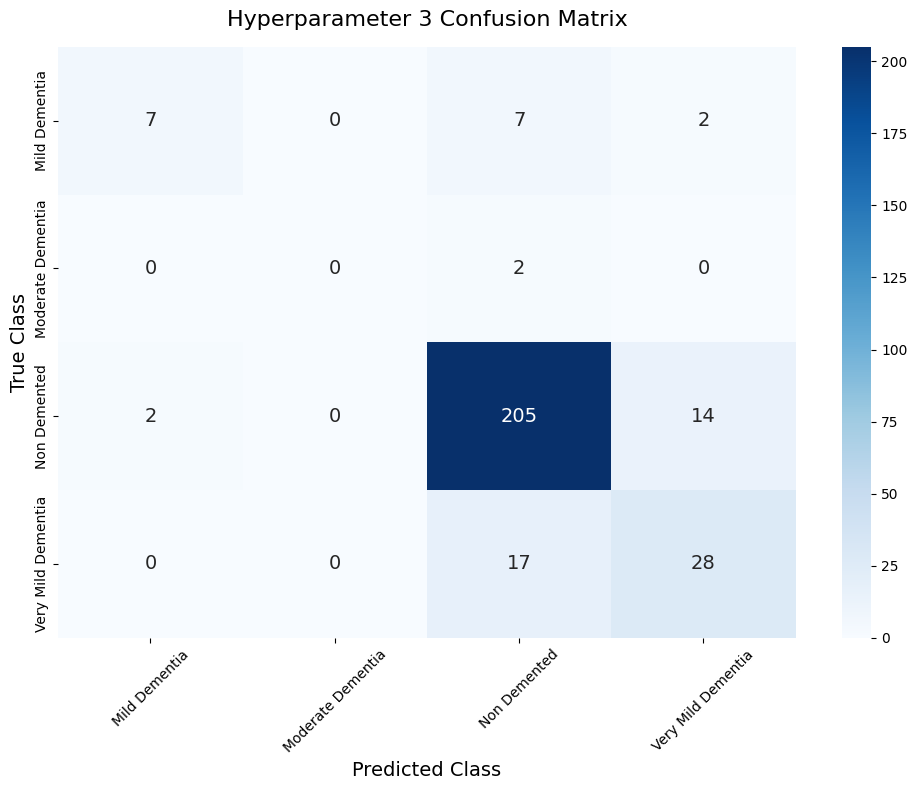

Saved ROC Curve to: /content/drive/My Drive/Colab Notebooks/models_history/hyperparameter 3/roc_curve.png


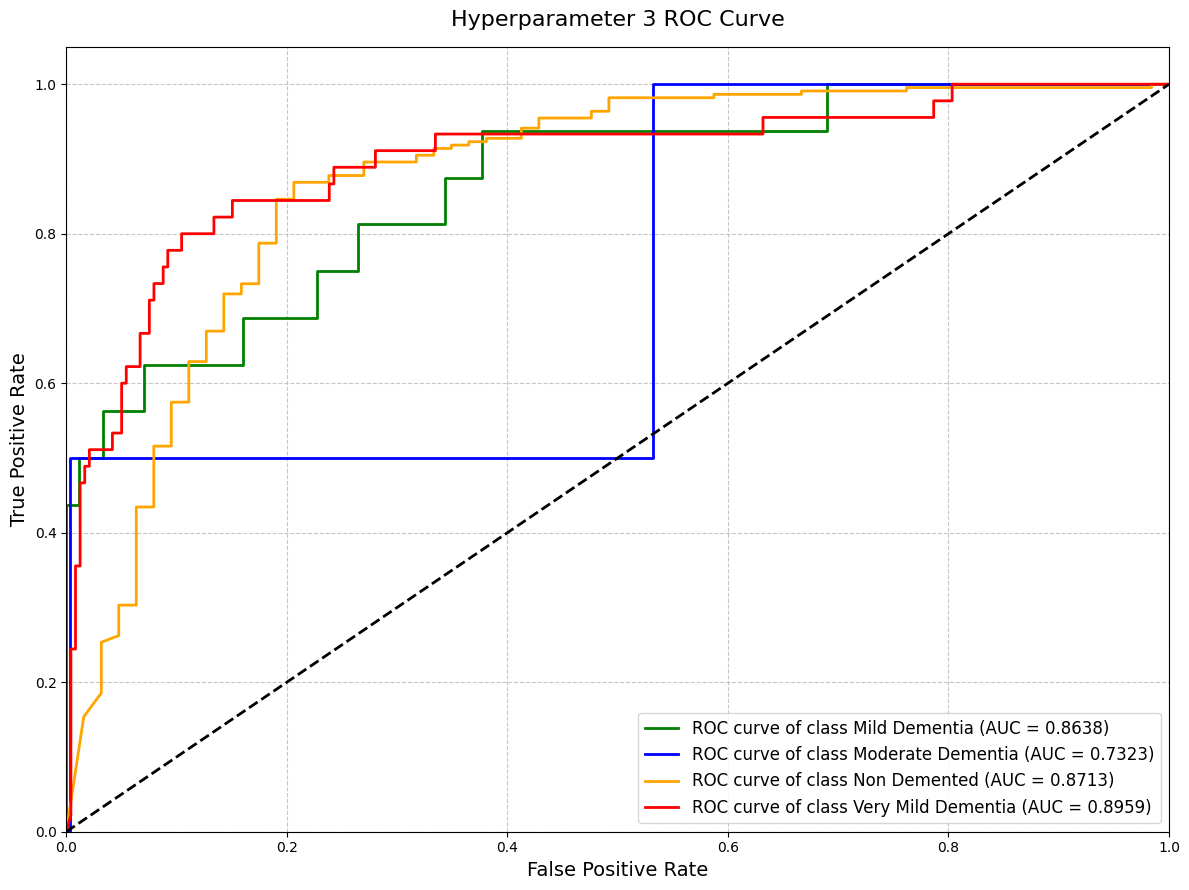

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize


model_path = "/content/drive/My Drive/Colab Notebooks/models_history/hyperparameter_tuning/3_checkpoints/best_model.keras"
output_dir = "/content/drive/My Drive/Colab Notebooks/models_history/hyperparameter 3"
os.makedirs(output_dir, exist_ok=True)


class_labels = [c.replace('_', ' ').title() for c in lb.classes_]
num_classes = len(class_labels)

model = tf.keras.models.load_model(model_path)

print("Generating predictions on the test dataset...")
y_pred_probs = model.predict(X_test)

# Convert one-hot/probabilities back to integer class indices
y_true_classes = np.argmax(y_test, axis=1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

print("\n" + "="*50)
print("Hyperparameter 3 Classification Report")
print("="*50)
report = classification_report(y_true_classes, y_pred_classes, target_names=class_labels, digits=4)
print(report)


# CONFUSION MATRIX
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            annot_kws={"size": 14})
plt.title('Hyperparameter 3 Confusion Matrix', fontsize=16, pad=15)
plt.ylabel('True Class', fontsize=14)
plt.xlabel('Predicted Class', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
cm_save_path = os.path.join(output_dir, "confusion_matrix.png")
plt.savefig(cm_save_path, dpi=300)
print(f"\nSaved Confusion Matrix to: {cm_save_path}")
plt.show()

# MULTI-CLASS ROC CURVE
# Binarize the true labels to calculate One-vs-Rest ROC
y_test_bin = label_binarize(y_true_classes, classes=[0, 1, 2, 3])

plt.figure(figsize=(12, 9))
colors = ['green', 'blue', 'orange', 'red']

for i, color in zip(range(num_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'ROC curve of class {class_labels[i]} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Hyperparameter 3 ROC Curve', fontsize=16, pad=15)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

roc_save_path = os.path.join(output_dir, "roc_curve.png")
plt.savefig(roc_save_path, dpi=300)
print(f"Saved ROC Curve to: {roc_save_path}")
plt.show()

Generating predictions on the test dataset...
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 507ms/step

Hyperparameter 4 Classification Report
                    precision    recall  f1-score   support

     Mild Dementia     0.8125    0.8125    0.8125        16
 Moderate Dementia     1.0000    0.5000    0.6667         2
      Non Demented     0.9543    0.9457    0.9500       221
Very Mild Dementia     0.8125    0.8667    0.8387        45

          accuracy                         0.9225       284
         macro avg     0.8948    0.7812    0.8170       284
      weighted avg     0.9242    0.9225    0.9226       284


Saved Confusion Matrix to: /content/drive/My Drive/Colab Notebooks/models_history/hyperparameter 4/confusion_matrix.png


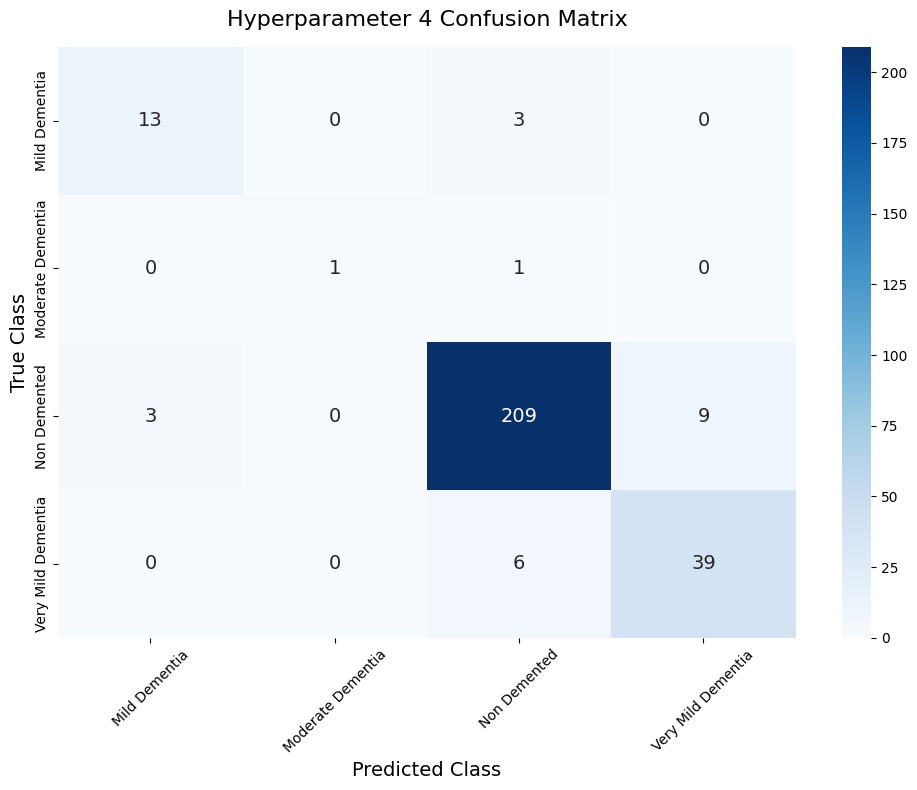

Saved ROC Curve to: /content/drive/My Drive/Colab Notebooks/models_history/hyperparameter 4/roc_curve.png


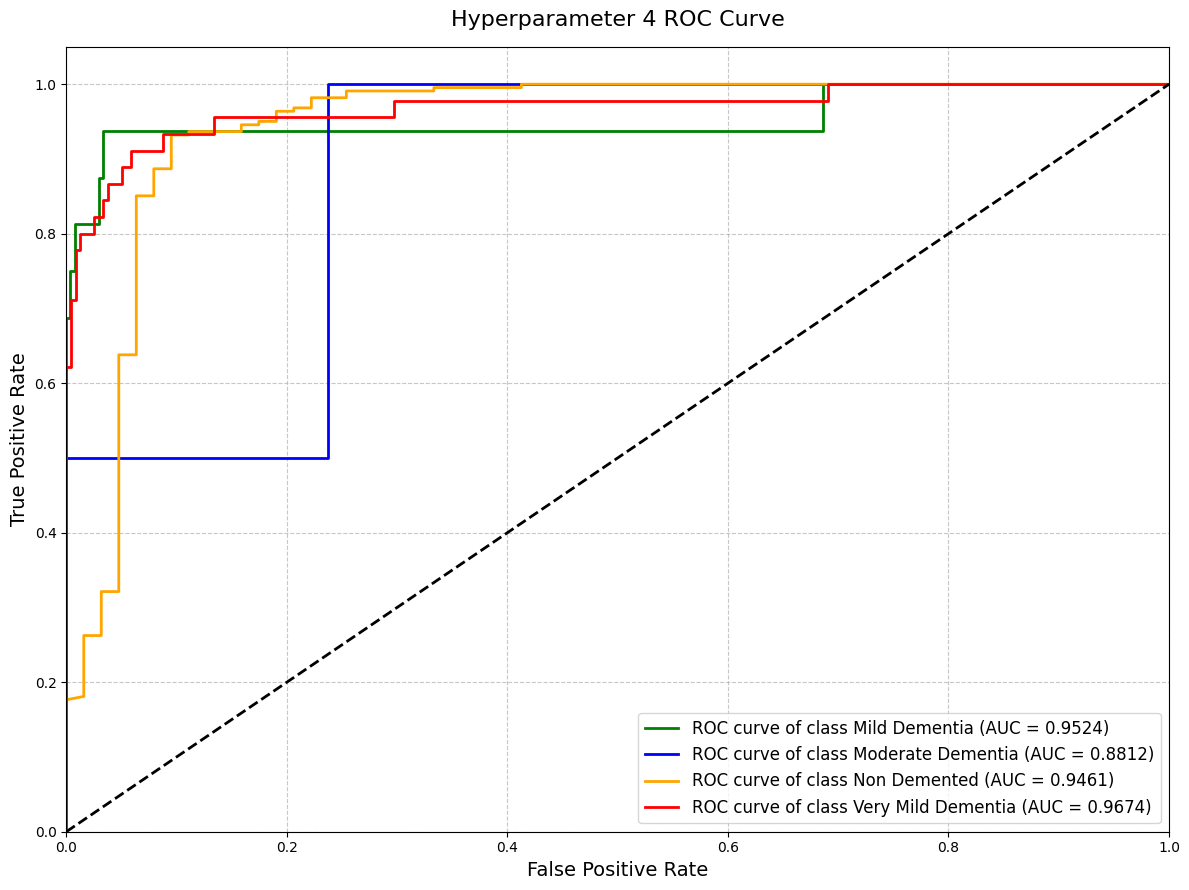

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize


model_path = "/content/drive/My Drive/Colab Notebooks/models_history/hyperparameter_tuning/4_checkpoints/best_model.keras"
output_dir = "/content/drive/My Drive/Colab Notebooks/models_history/hyperparameter 4"
os.makedirs(output_dir, exist_ok=True)


class_labels = [c.replace('_', ' ').title() for c in lb.classes_]
num_classes = len(class_labels)

model = tf.keras.models.load_model(model_path)

print("Generating predictions on the test dataset...")
y_pred_probs = model.predict(X_test)

# Convert one-hot/probabilities back to integer class indices
y_true_classes = np.argmax(y_test, axis=1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

print("\n" + "="*50)
print("Hyperparameter 4 Classification Report")
print("="*50)
report = classification_report(y_true_classes, y_pred_classes, target_names=class_labels, digits=4)
print(report)


# CONFUSION MATRIX
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            annot_kws={"size": 14})
plt.title('Hyperparameter 4 Confusion Matrix', fontsize=16, pad=15)
plt.ylabel('True Class', fontsize=14)
plt.xlabel('Predicted Class', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
cm_save_path = os.path.join(output_dir, "confusion_matrix.png")
plt.savefig(cm_save_path, dpi=300)
print(f"\nSaved Confusion Matrix to: {cm_save_path}")
plt.show()

# MULTI-CLASS ROC CURVE
# Binarize the true labels to calculate One-vs-Rest ROC
y_test_bin = label_binarize(y_true_classes, classes=[0, 1, 2, 3])

plt.figure(figsize=(12, 9))
colors = ['green', 'blue', 'orange', 'red']

for i, color in zip(range(num_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'ROC curve of class {class_labels[i]} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Hyperparameter 4 ROC Curve', fontsize=16, pad=15)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

roc_save_path = os.path.join(output_dir, "roc_curve.png")
plt.savefig(roc_save_path, dpi=300)
print(f"Saved ROC Curve to: {roc_save_path}")
plt.show()

Generating predictions on the test dataset...
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 506ms/step

Hyperparameter 5 Classification Report
                    precision    recall  f1-score   support

     Mild Dementia     1.0000    0.8125    0.8966        16
 Moderate Dementia     0.6667    1.0000    0.8000         2
      Non Demented     0.9729    0.9729    0.9729       221
Very Mild Dementia     0.8723    0.9111    0.8913        45

          accuracy                         0.9542       284
         macro avg     0.8780    0.9241    0.8902       284
      weighted avg     0.9563    0.9542    0.9544       284


Saved Confusion Matrix to: /content/drive/My Drive/Colab Notebooks/models_history/hyperparameter 5/confusion_matrix.png


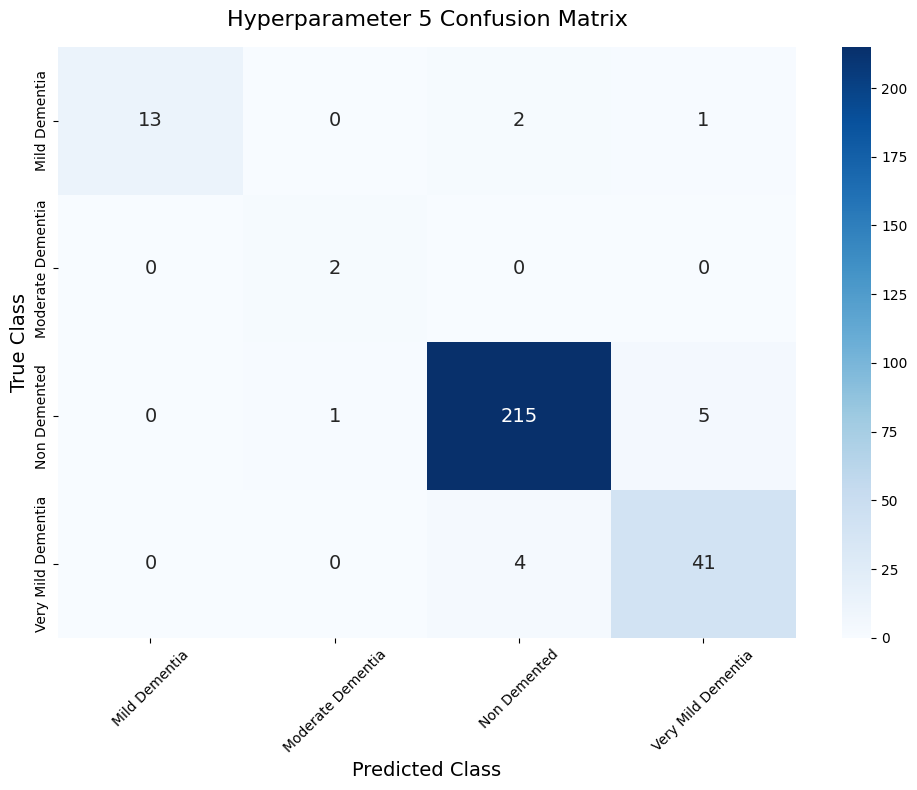

Saved ROC Curve to: /content/drive/My Drive/Colab Notebooks/models_history/hyperparameter 5/roc_curve.png


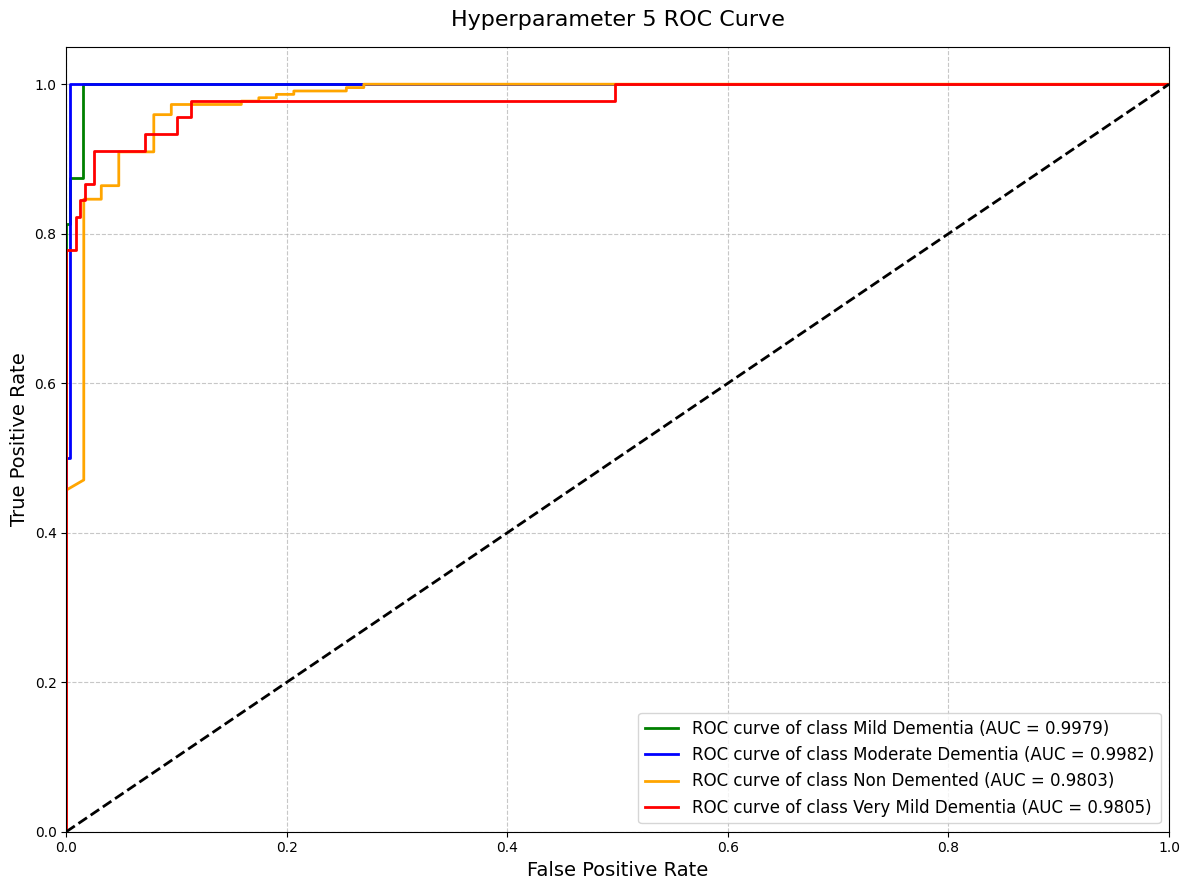

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize


model_path = "/content/drive/My Drive/Colab Notebooks/models_history/hyperparameter_tuning/5_checkpoints/best_model.keras"
output_dir = "/content/drive/My Drive/Colab Notebooks/models_history/hyperparameter 5"
os.makedirs(output_dir, exist_ok=True)


class_labels = [c.replace('_', ' ').title() for c in lb.classes_]
num_classes = len(class_labels)

model = tf.keras.models.load_model(model_path)

print("Generating predictions on the test dataset...")
y_pred_probs = model.predict(X_test)

# Convert one-hot/probabilities back to integer class indices
y_true_classes = np.argmax(y_test, axis=1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

print("\n" + "="*50)
print("Hyperparameter 5 Classification Report")
print("="*50)
report = classification_report(y_true_classes, y_pred_classes, target_names=class_labels, digits=4)
print(report)


# CONFUSION MATRIX
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            annot_kws={"size": 14})
plt.title('Hyperparameter 5 Confusion Matrix', fontsize=16, pad=15)
plt.ylabel('True Class', fontsize=14)
plt.xlabel('Predicted Class', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
cm_save_path = os.path.join(output_dir, "confusion_matrix.png")
plt.savefig(cm_save_path, dpi=300)
print(f"\nSaved Confusion Matrix to: {cm_save_path}")
plt.show()

# MULTI-CLASS ROC CURVE
# Binarize the true labels to calculate One-vs-Rest ROC
y_test_bin = label_binarize(y_true_classes, classes=[0, 1, 2, 3])

plt.figure(figsize=(12, 9))
colors = ['green', 'blue', 'orange', 'red']

for i, color in zip(range(num_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'ROC curve of class {class_labels[i]} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Hyperparameter 5 ROC Curve', fontsize=16, pad=15)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

roc_save_path = os.path.join(output_dir, "roc_curve.png")
plt.savefig(roc_save_path, dpi=300)
print(f"Saved ROC Curve to: {roc_save_path}")
plt.show()

## Optimiser testing

In [ ]:
import os
import time
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.callbacks import Callback, CSVLogger, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, TimeDistributed, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam, RMSprop, SGD, Nadam, AdamW
from sklearn.metrics import f1_score, precision_score, recall_score

val_ds = prepare_dataset(X_val, y_val, batch_size=8)

# ==============================================================================
# METRICS LOGGER
# ==============================================================================
class AdvancedMetricsLogger(Callback):
    def __init__(self, validation_data, run_name):
        super().__init__()
        self.validation_data = validation_data
        self.run_name = run_name
        self.epoch_start_time = 0

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        epoch_time = time.time() - self.epoch_start_time

        X_val, y_val_true = self.validation_data
        y_pred_probs = self.model.predict(X_val, verbose=0)

        y_true_classes = np.argmax(y_val_true, axis=1)
        y_pred_classes = np.argmax(y_pred_probs, axis=1)

        val_f1 = f1_score(y_true_classes, y_pred_classes, average='macro')
        val_precision = precision_score(y_true_classes, y_pred_classes, average='macro', zero_division=0)
        val_recall = recall_score(y_true_classes, y_pred_classes, average='macro')

        logs['val_f1'] = val_f1
        logs['val_precision'] = val_precision
        logs['val_recall'] = val_recall
        logs['epoch_time_seconds'] = epoch_time

        print(f" - Epoch {epoch+1} - val_f1: {val_f1:.4f} - time: {epoch_time:.2f}s")

# ==============================================================================
# MODEL
# ==============================================================================
def build_hybrid_lstm(lstm_units=64, dropout_rate=0.5, learning_rate=0.001, optimizer_choice='adam'):
    model = Sequential([
        Input(shape=(61, 128, 128, 3)),
        TimeDistributed(tf.keras.layers.Rescaling(1./255)),

        TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same')),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same')),
        TimeDistributed(GlobalAveragePooling2D()),

        Bidirectional(LSTM(lstm_units, dropout=0.2)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dense(4, activation='softmax', dtype='float32')
    ])

    if optimizer_choice == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_choice == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    elif optimizer_choice == 'nadam':
        opt = Nadam(learning_rate=learning_rate)
    elif optimizer_choice == 'adamw':
        opt = AdamW(learning_rate=learning_rate, weight_decay=1e-4)
    elif optimizer_choice == 'sgd_momentum':
        opt = SGD(learning_rate=learning_rate, momentum=0.9)

    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ==============================================================================
# CONFIGURATION
# ==============================================================================
LR = 0.001
LSTM_UNITS = 64
DROPOUT = 0.5
BATCH_SIZE = 8
RUNS_PER_OPTIMIZER = 4
TOTAL_EPOCHS = 350

optimizer_grid = {
    '1': 'adam',
    '2': 'rmsprop',
    '3': 'nadam',
    '4': 'sgd_momentum'
}

TARGET_RUNS = ['1']

base_save_dir = "/content/drive/My Drive/Colab Notebooks/models_history/optimizer_tuning/multirun"
os.makedirs(base_save_dir, exist_ok=True)

# ==============================================================================
#EXECUTION WITH RESUME LOGIC
# ==============================================================================
for run_name in TARGET_RUNS:
    opt_choice = optimizer_grid[run_name]

    print(f"\n{'='*60}")
    print(f"EVALUATING OPTIMIZER: {run_name.upper()} ({opt_choice})")
    print(f"{'='*60}")

    for run_idx in range(RUNS_PER_OPTIMIZER):
        current_run_id = f"{run_name}_run{run_idx+1}"
        run_dir = os.path.join(base_save_dir, f"{current_run_id}_checkpoints")
        os.makedirs(run_dir, exist_ok=True)

        seed_file_path = os.path.join(run_dir, "seed_info.txt")
        last_model_path = os.path.join(run_dir, "last_model.keras")
        best_model_path = os.path.join(run_dir, "best_model.keras")
        run_csv_path = os.path.join(base_save_dir, f"{current_run_id}_metrics.csv")

        # --- SEED MANAGEMENT ---
        if os.path.exists(seed_file_path):
            # If run was started previously, extract the exact seed used
            with open(seed_file_path, "r") as f:
                lines = f.readlines()
                current_seed = int(lines[-1].split(":")[-1].strip())
            print(f"\n-> Extracted existing seed {current_seed} for {current_run_id}")
        else:
            # If fresh run, generate new seed and save it
            current_seed = random.randint(1, 999999)
            with open(seed_file_path, "w") as f:
                f.write(f"Run ID: {current_run_id}\n")
                f.write(f"Optimizer: {opt_choice}\n")
                f.write(f"True Random Seed Used: {current_seed}\n")
            print(f"\n-> Generated new seed {current_seed} for {current_run_id}")

        # Clear session and rigorously lock seeds before building/loading
        tf.keras.backend.clear_session()
        os.environ['PYTHONHASHSEED'] = str(current_seed)
        tf.random.set_seed(current_seed)
        np.random.seed(current_seed)
        random.seed(current_seed)

        initial_epoch = 0
        model = None
        append_csv = False

        # --- MODEL RESUME LOGIC ---
        if os.path.exists(last_model_path) and os.path.exists(run_csv_path):
            try:
                log_df = pd.read_csv(run_csv_path)
                if not log_df.empty:
                    initial_epoch = log_df['epoch'].max() + 1

                if initial_epoch >= TOTAL_EPOCHS:
                    print(f"-> [SKIPPING] {current_run_id} is already 100% complete ({TOTAL_EPOCHS}/{TOTAL_EPOCHS} epochs).")
                    continue

                print(f"-> Found checkpoint! Resuming {current_run_id} from Epoch {initial_epoch}...")
                model = tf.keras.models.load_model(last_model_path)
                append_csv = True
            except Exception as e:
                print(f"-> Error loading checkpoint for {current_run_id}: {e}. Starting fresh.")
                model = build_hybrid_lstm(lstm_units=LSTM_UNITS, dropout_rate=DROPOUT, learning_rate=LR, optimizer_choice=opt_choice)
                append_csv = False
        else:
            print(f"-> Starting fresh training build for {current_run_id}...")
            model = build_hybrid_lstm(lstm_units=LSTM_UNITS, dropout_rate=DROPOUT, learning_rate=LR, optimizer_choice=opt_choice)
            append_csv = False

        # --- SET UP CALLBACKS ---
        csv_logger = CSVLogger(run_csv_path, append=append_csv)
        advanced_logger = AdvancedMetricsLogger(validation_data=(X_val, y_val), run_name=current_run_id)

        checkpoint_last = ModelCheckpoint(
            filepath=last_model_path,
            save_best_only=False,
            verbose=0
        )

        checkpoint_best = ModelCheckpoint(
            filepath=best_model_path,
            monitor='val_loss',
            save_best_only=True,
            mode='min',
            verbose=0
        )

        # --- 4. TRAIN THE MODEL ---
        try:
            model.fit(
                X_train, y_train,
                validation_data=val_ds,
                epochs=TOTAL_EPOCHS,
                initial_epoch=initial_epoch,
                batch_size=BATCH_SIZE,
                shuffle=True,
                callbacks=[advanced_logger, csv_logger, checkpoint_last, checkpoint_best],
                verbose=1
            )
        except KeyboardInterrupt:
            print(f"\n[!] Training manually interrupted during {current_run_id}.")
            print("[!] Current progress has been saved. Run the script again to resume.")
            break

print(f"\nAll specified target runs {TARGET_RUNS} have finished processing!")


EVALUATING OPTIMIZER: 1 (adam)

-> Extracted existing seed 18465 for 1_run1
-> Starting fresh training build for 1_run1...
Epoch 1/350
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.2402 - loss: 1.3894 - Epoch 1 - val_f1: 0.2191 - time: 78.47s
352/352 ━━━━━━━━━━━━━━━━━━━━ 81s 221ms/step - accuracy: 0.2457 - loss: 1.3885 - val_accuracy: 0.7797 - val_loss: 1.3151 - val_f1: 0.2191 - val_precision: 0.1949 - val_recall: 0.2500 - epoch_time_seconds: 78.4680
Epoch 2/350
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.2438 - loss: 1.3908 - Epoch 2 - val_f1: 0.2191 - time: 73.52s
352/352 ━━━━━━━━━━━━━━━━━━━━ 74s 210ms/step - accuracy: 0.2518 - loss: 1.3895 - val_accuracy: 0.7797 - val_loss: 1.2875 - val_f1: 0.2191 - val_precision: 0.1949 - val_recall: 0.2500 - epoch_time_seconds: 73.5192
Epoch 3/350
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.2559 - loss: 1.3856 - Epoch 3 - val_f1: 0.2439 - time: 73.55s
352/352 ━━━━━━━━━━━━━━━━━━━━ 74s 210ms/step - accuracy: 0.2

In [ ]:
import os
import time
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.callbacks import Callback, CSVLogger, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, TimeDistributed, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam, RMSprop, SGD, Nadam, AdamW
from sklearn.metrics import f1_score, precision_score, recall_score

val_ds = prepare_dataset(X_val, y_val, batch_size=8)

# ==============================================================================
# METRICS LOGGER
# ==============================================================================
class AdvancedMetricsLogger(Callback):
    def __init__(self, validation_data, run_name):
        super().__init__()
        self.validation_data = validation_data
        self.run_name = run_name
        self.epoch_start_time = 0

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        epoch_time = time.time() - self.epoch_start_time

        X_val, y_val_true = self.validation_data
        y_pred_probs = self.model.predict(X_val, verbose=0)

        y_true_classes = np.argmax(y_val_true, axis=1)
        y_pred_classes = np.argmax(y_pred_probs, axis=1)

        val_f1 = f1_score(y_true_classes, y_pred_classes, average='macro')
        val_precision = precision_score(y_true_classes, y_pred_classes, average='macro', zero_division=0)
        val_recall = recall_score(y_true_classes, y_pred_classes, average='macro')

        logs['val_f1'] = val_f1
        logs['val_precision'] = val_precision
        logs['val_recall'] = val_recall
        logs['epoch_time_seconds'] = epoch_time

        print(f" - Epoch {epoch+1} - val_f1: {val_f1:.4f} - time: {epoch_time:.2f}s")

# ==============================================================================
# MODEL
# ==============================================================================
def build_hybrid_lstm(lstm_units=64, dropout_rate=0.5, learning_rate=0.001, optimizer_choice='adam'):
    model = Sequential([
        Input(shape=(61, 128, 128, 3)),
        TimeDistributed(tf.keras.layers.Rescaling(1./255)),

        TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same')),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same')),
        TimeDistributed(GlobalAveragePooling2D()),

        Bidirectional(LSTM(lstm_units, dropout=0.2)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dense(4, activation='softmax', dtype='float32')
    ])

    if optimizer_choice == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_choice == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    elif optimizer_choice == 'nadam':
        opt = Nadam(learning_rate=learning_rate)
    elif optimizer_choice == 'adamw':
        opt = AdamW(learning_rate=learning_rate, weight_decay=1e-4)
    elif optimizer_choice == 'sgd_momentum':
        opt = SGD(learning_rate=learning_rate, momentum=0.9)

    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ==============================================================================
# CONFIGURATION
# ==============================================================================
LR = 0.001
LSTM_UNITS = 64
DROPOUT = 0.5
BATCH_SIZE = 8
RUNS_PER_OPTIMIZER = 4
TOTAL_EPOCHS = 320

optimizer_grid = {
    '1': 'adam',
    '2': 'rmsprop',
    '3': 'nadam',
    '4': 'sgd_momentum'
}

TARGET_RUNS = ['1']

base_save_dir = "/content/drive/My Drive/Colab Notebooks/models_history/optimizer_tuning/multirun"
os.makedirs(base_save_dir, exist_ok=True)

# ==============================================================================
# EXECUTION RESUME LOGIC
# ==============================================================================
for run_name in TARGET_RUNS:
    opt_choice = optimizer_grid[run_name]

    print(f"\n{'='*60}")
    print(f"EVALUATING OPTIMIZER: {run_name.upper()} ({opt_choice})")
    print(f"{'='*60}")

    for run_idx in range(RUNS_PER_OPTIMIZER):
        current_run_id = f"{run_name}_run{run_idx+1}"
        run_dir = os.path.join(base_save_dir, f"{current_run_id}_checkpoints")
        os.makedirs(run_dir, exist_ok=True)

        seed_file_path = os.path.join(run_dir, "seed_info.txt")
        last_model_path = os.path.join(run_dir, "last_model.keras")
        best_model_path = os.path.join(run_dir, "best_model.keras")
        run_csv_path = os.path.join(base_save_dir, f"{current_run_id}_metrics.csv")


        if os.path.exists(seed_file_path):
            # If run was started previously, extract the exact seed used
            with open(seed_file_path, "r") as f:
                lines = f.readlines()
                current_seed = int(lines[-1].split(":")[-1].strip())
            print(f"\n-> Extracted existing seed {current_seed} for {current_run_id}")
        else:
            # If fresh run, generate new seed and save it
            current_seed = random.randint(1, 999999)
            with open(seed_file_path, "w") as f:
                f.write(f"Run ID: {current_run_id}\n")
                f.write(f"Optimizer: {opt_choice}\n")
                f.write(f"True Random Seed Used: {current_seed}\n")
            print(f"\n-> Generated new seed {current_seed} for {current_run_id}")

        # Clear session and set seeds
        tf.keras.backend.clear_session()
        os.environ['PYTHONHASHSEED'] = str(current_seed)
        tf.random.set_seed(current_seed)
        np.random.seed(current_seed)
        random.seed(current_seed)

        initial_epoch = 0
        model = None
        append_csv = False

        # --- RESUME LOGIC ---
        if os.path.exists(last_model_path) and os.path.exists(run_csv_path):
            try:
                log_df = pd.read_csv(run_csv_path)
                if not log_df.empty:
                    initial_epoch = log_df['epoch'].max() + 1

                if initial_epoch >= TOTAL_EPOCHS:
                    print(f"-> [SKIPPING] {current_run_id} is already 100% complete ({TOTAL_EPOCHS}/{TOTAL_EPOCHS} epochs).")
                    continue

                print(f"-> Found checkpoint! Resuming {current_run_id} from Epoch {initial_epoch}...")
                model = tf.keras.models.load_model(last_model_path)
                append_csv = True
            except Exception as e:
                print(f"-> Error loading checkpoint for {current_run_id}: {e}. Starting fresh.")
                model = build_hybrid_lstm(lstm_units=LSTM_UNITS, dropout_rate=DROPOUT, learning_rate=LR, optimizer_choice=opt_choice)
                append_csv = False
        else:
            print(f"-> Starting fresh training build for {current_run_id}...")
            model = build_hybrid_lstm(lstm_units=LSTM_UNITS, dropout_rate=DROPOUT, learning_rate=LR, optimizer_choice=opt_choice)
            append_csv = False

        # --- SET UP CALLBACKS ---
        csv_logger = CSVLogger(run_csv_path, append=append_csv)
        advanced_logger = AdvancedMetricsLogger(validation_data=(X_val, y_val), run_name=current_run_id)

        checkpoint_last = ModelCheckpoint(
            filepath=last_model_path,
            save_best_only=False,
            verbose=0
        )

        checkpoint_best = ModelCheckpoint(
            filepath=best_model_path,
            monitor='val_loss',
            save_best_only=True,
            mode='min',
            verbose=0
        )

        # --- TRAIN THE MODEL ---
        try:
            model.fit(
                X_train, y_train,
                validation_data=val_ds,
                epochs=TOTAL_EPOCHS,
                initial_epoch=initial_epoch,
                batch_size=BATCH_SIZE,
                shuffle=True,
                callbacks=[advanced_logger, csv_logger, checkpoint_last, checkpoint_best],
                verbose=1
            )
        except KeyboardInterrupt:
            print(f"\n[!] Training manually interrupted during {current_run_id}.")
            print("[!] Current progress has been saved. Run the script again to resume.")
            break

print(f"\nAll specified target runs {TARGET_RUNS} have finished processing!")


EVALUATING OPTIMIZER: 1 (adam)

-> Extracted existing seed 18465 for 1_run1
-> Found checkpoint! Resuming 1_run1 from Epoch 24...
Epoch 25/320
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.8824 - loss: 0.3024 - Epoch 25 - val_f1: 0.6804 - time: 78.31s
352/352 ━━━━━━━━━━━━━━━━━━━━ 80s 218ms/step - accuracy: 0.8867 - loss: 0.2928 - val_accuracy: 0.8414 - val_loss: 0.3635 - val_f1: 0.6804 - val_precision: 0.6030 - val_recall: 0.8871 - epoch_time_seconds: 78.3124
Epoch 26/320
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.8839 - loss: 0.3104 - Epoch 26 - val_f1: 0.7706 - time: 73.74s
352/352 ━━━━━━━━━━━━━━━━━━━━ 74s 211ms/step - accuracy: 0.8896 - loss: 0.2935 - val_accuracy: 0.7974 - val_loss: 0.4591 - val_f1: 0.7706 - val_precision: 0.7327 - val_recall: 0.9018 - epoch_time_seconds: 73.7380
Epoch 27/320
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.8992 - loss: 0.2756 - Epoch 27 - val_f1: 0.8256 - time: 73.48s
352/352 ━━━━━━━━━━━━━━━━━━━━ 74s 210ms/step - 

In [ ]:
import os
import time
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.callbacks import Callback, CSVLogger, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, TimeDistributed, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam, RMSprop, SGD, Nadam, AdamW
from sklearn.metrics import f1_score, precision_score, recall_score

val_ds = prepare_dataset(X_val, y_val, batch_size=8)

# ==============================================================================
# METRICS LOGGER
# ==============================================================================
class AdvancedMetricsLogger(Callback):
    def __init__(self, validation_data, run_name):
        super().__init__()
        self.validation_data = validation_data
        self.run_name = run_name
        self.epoch_start_time = 0

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        epoch_time = time.time() - self.epoch_start_time

        X_val, y_val_true = self.validation_data
        y_pred_probs = self.model.predict(X_val, verbose=0)

        y_true_classes = np.argmax(y_val_true, axis=1)
        y_pred_classes = np.argmax(y_pred_probs, axis=1)

        val_f1 = f1_score(y_true_classes, y_pred_classes, average='macro')
        val_precision = precision_score(y_true_classes, y_pred_classes, average='macro', zero_division=0)
        val_recall = recall_score(y_true_classes, y_pred_classes, average='macro')

        logs['val_f1'] = val_f1
        logs['val_precision'] = val_precision
        logs['val_recall'] = val_recall
        logs['epoch_time_seconds'] = epoch_time

        print(f" - Epoch {epoch+1} - val_f1: {val_f1:.4f} - time: {epoch_time:.2f}s")

# ==============================================================================
# MODEL
# ==============================================================================
def build_hybrid_lstm(lstm_units=64, dropout_rate=0.5, learning_rate=0.001, optimizer_choice='adam'):
    model = Sequential([
        Input(shape=(61, 128, 128, 3)),
        TimeDistributed(tf.keras.layers.Rescaling(1./255)),

        TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same')),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same')),
        TimeDistributed(GlobalAveragePooling2D()),

        Bidirectional(LSTM(lstm_units, dropout=0.2)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dense(4, activation='softmax', dtype='float32')
    ])

    if optimizer_choice == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_choice == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    elif optimizer_choice == 'nadam':
        opt = Nadam(learning_rate=learning_rate)
    elif optimizer_choice == 'adamw':
        opt = AdamW(learning_rate=learning_rate, weight_decay=1e-4)
    elif optimizer_choice == 'sgd_momentum':
        opt = SGD(learning_rate=learning_rate, momentum=0.9)

    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ==============================================================================
# CONFIGURATION
# ==============================================================================
LR = 0.001
LSTM_UNITS = 64
DROPOUT = 0.5
BATCH_SIZE = 8
RUNS_PER_OPTIMIZER = 4
TOTAL_EPOCHS = 320

optimizer_grid = {
    '1': 'adam',
    '2': 'rmsprop',
    '3': 'nadam',
    '4': 'sgd_momentum'
}

TARGET_RUNS = ['1']

base_save_dir = "/content/drive/My Drive/Colab Notebooks/models_history/optimizer_tuning/multirun"
os.makedirs(base_save_dir, exist_ok=True)

# ==============================================================================
# AUTOMATED EXECUTION WITH RESUME LOGIC
# ==============================================================================
for run_name in TARGET_RUNS:
    opt_choice = optimizer_grid[run_name]

    print(f"\n{'='*60}")
    print(f"EVALUATING OPTIMIZER: {run_name.upper()} ({opt_choice})")
    print(f"{'='*60}")

    for run_idx in range(RUNS_PER_OPTIMIZER):
        current_run_id = f"{run_name}_run{run_idx+1}"
        run_dir = os.path.join(base_save_dir, f"{current_run_id}_checkpoints")
        os.makedirs(run_dir, exist_ok=True)

        seed_file_path = os.path.join(run_dir, "seed_info.txt")
        last_model_path = os.path.join(run_dir, "last_model.keras")
        best_model_path = os.path.join(run_dir, "best_model.keras")
        run_csv_path = os.path.join(base_save_dir, f"{current_run_id}_metrics.csv")

        # --- SEED MANAGEMENT LOGIC ---
        if os.path.exists(seed_file_path):
            # If run was started previously, extract the exact seed used
            with open(seed_file_path, "r") as f:
                lines = f.readlines()
                current_seed = int(lines[-1].split(":")[-1].strip())
            print(f"\n-> Extracted existing seed {current_seed} for {current_run_id}")
        else:
            # If fresh run, generate new seed and save it
            current_seed = random.randint(1, 999999)
            with open(seed_file_path, "w") as f:
                f.write(f"Run ID: {current_run_id}\n")
                f.write(f"Optimizer: {opt_choice}\n")
                f.write(f"True Random Seed Used: {current_seed}\n")
            print(f"\n-> Generated new seed {current_seed} for {current_run_id}")

        # Clear session and set seeds
        tf.keras.backend.clear_session()
        os.environ['PYTHONHASHSEED'] = str(current_seed)
        tf.random.set_seed(current_seed)
        np.random.seed(current_seed)
        random.seed(current_seed)

        initial_epoch = 0
        model = None
        append_csv = False

        # --- MODEL RESUME LOGIC ---
        if os.path.exists(last_model_path) and os.path.exists(run_csv_path):
            try:
                log_df = pd.read_csv(run_csv_path)
                if not log_df.empty:
                    initial_epoch = log_df['epoch'].max() + 1

                if initial_epoch >= TOTAL_EPOCHS:
                    print(f"-> [SKIPPING] {current_run_id} is already 100% complete ({TOTAL_EPOCHS}/{TOTAL_EPOCHS} epochs).")
                    continue

                print(f"-> Found checkpoint! Resuming {current_run_id} from Epoch {initial_epoch}...")
                model = tf.keras.models.load_model(last_model_path)
                append_csv = True
            except Exception as e:
                print(f"-> Error loading checkpoint for {current_run_id}: {e}. Starting fresh.")
                model = build_hybrid_lstm(lstm_units=LSTM_UNITS, dropout_rate=DROPOUT, learning_rate=LR, optimizer_choice=opt_choice)
                append_csv = False
        else:
            print(f"-> Starting fresh training build for {current_run_id}...")
            model = build_hybrid_lstm(lstm_units=LSTM_UNITS, dropout_rate=DROPOUT, learning_rate=LR, optimizer_choice=opt_choice)
            append_csv = False

        # --- SET UP CALLBACKS ---
        csv_logger = CSVLogger(run_csv_path, append=append_csv)
        advanced_logger = AdvancedMetricsLogger(validation_data=(X_val, y_val), run_name=current_run_id)

        checkpoint_last = ModelCheckpoint(
            filepath=last_model_path,
            save_best_only=False,
            verbose=0
        )

        checkpoint_best = ModelCheckpoint(
            filepath=best_model_path,
            monitor='val_loss',
            save_best_only=True,
            mode='min',
            verbose=0
        )

        # --- TRAIN THE MODEL ---
        try:
            model.fit(
                X_train, y_train,
                validation_data=val_ds,
                epochs=TOTAL_EPOCHS,
                initial_epoch=initial_epoch,
                batch_size=BATCH_SIZE,
                shuffle=True,
                callbacks=[advanced_logger, csv_logger, checkpoint_last, checkpoint_best],
                verbose=1
            )
        except KeyboardInterrupt:
            print(f"\n[!] Training manually interrupted during {current_run_id}.")
            print("[!] Current progress has been saved. Run the script again to resume.")
            break

print(f"\nAll specified target runs {TARGET_RUNS} have finished processing!")


EVALUATING OPTIMIZER: 1 (adam)

-> Extracted existing seed 18465 for 1_run1
-> Found checkpoint! Resuming 1_run1 from Epoch 127...
Epoch 128/320
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.9964 - loss: 0.0133 - Epoch 128 - val_f1: 0.8290 - time: 107.89s
352/352 ━━━━━━━━━━━━━━━━━━━━ 112s 224ms/step - accuracy: 0.9943 - loss: 0.0204 - val_accuracy: 0.9471 - val_loss: 0.1727 - val_f1: 0.8290 - val_precision: 0.7864 - val_recall: 0.9142 - epoch_time_seconds: 107.8890
Epoch 129/320
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9835 - loss: 0.0411 - Epoch 129 - val_f1: 0.9307 - time: 73.52s
352/352 ━━━━━━━━━━━━━━━━━━━━ 74s 210ms/step - accuracy: 0.9819 - loss: 0.0495 - val_accuracy: 0.9604 - val_loss: 0.1241 - val_f1: 0.9307 - val_precision: 0.9599 - val_recall: 0.9062 - epoch_time_seconds: 73.5163
Epoch 130/320
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9778 - loss: 0.0543 - Epoch 130 - val_f1: 0.9673 - time: 73.28s
352/352 ━━━━━━━━━━━━━━━━━━━━ 74s 210

In [ ]:
import os
import time
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.callbacks import Callback, CSVLogger, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, TimeDistributed, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam, RMSprop, SGD, Nadam, AdamW
from sklearn.metrics import f1_score, precision_score, recall_score

val_ds = prepare_dataset(X_val, y_val, batch_size=8)

# ==============================================================================
# METRICS LOGGER
# ==============================================================================
class AdvancedMetricsLogger(Callback):
    def __init__(self, validation_data, run_name):
        super().__init__()
        self.validation_data = validation_data
        self.run_name = run_name
        self.epoch_start_time = 0

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        epoch_time = time.time() - self.epoch_start_time

        X_val, y_val_true = self.validation_data
        y_pred_probs = self.model.predict(X_val, verbose=0)

        y_true_classes = np.argmax(y_val_true, axis=1)
        y_pred_classes = np.argmax(y_pred_probs, axis=1)

        val_f1 = f1_score(y_true_classes, y_pred_classes, average='macro')
        val_precision = precision_score(y_true_classes, y_pred_classes, average='macro', zero_division=0)
        val_recall = recall_score(y_true_classes, y_pred_classes, average='macro')

        logs['val_f1'] = val_f1
        logs['val_precision'] = val_precision
        logs['val_recall'] = val_recall
        logs['epoch_time_seconds'] = epoch_time

        print(f" - Epoch {epoch+1} - val_f1: {val_f1:.4f} - time: {epoch_time:.2f}s")

# ==============================================================================
# MODEL
# ==============================================================================
def build_hybrid_lstm(lstm_units=64, dropout_rate=0.5, learning_rate=0.001, optimizer_choice='adam'):
    model = Sequential([
        Input(shape=(61, 128, 128, 3)),
        TimeDistributed(tf.keras.layers.Rescaling(1./255)),

        TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same')),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same')),
        TimeDistributed(GlobalAveragePooling2D()),

        Bidirectional(LSTM(lstm_units, dropout=0.2)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dense(4, activation='softmax', dtype='float32')
    ])

    if optimizer_choice == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_choice == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    elif optimizer_choice == 'nadam':
        opt = Nadam(learning_rate=learning_rate)
    elif optimizer_choice == 'adamw':
        opt = AdamW(learning_rate=learning_rate, weight_decay=1e-4)
    elif optimizer_choice == 'sgd_momentum':
        opt = SGD(learning_rate=learning_rate, momentum=0.9)

    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ==============================================================================
# CONFIGURATION
# ==============================================================================
LR = 0.001
LSTM_UNITS = 64
DROPOUT = 0.5
BATCH_SIZE = 8
RUNS_PER_OPTIMIZER = 4
TOTAL_EPOCHS = 320

optimizer_grid = {
    '1': 'adam',
    '2': 'rmsprop',
    '3': 'nadam',
    '4': 'sgd_momentum'
}

TARGET_RUNS = ['1']

base_save_dir = "/content/drive/My Drive/Colab Notebooks/models_history/optimizer_tuning/multirun"
os.makedirs(base_save_dir, exist_ok=True)

# ==============================================================================
# AUTOMATED EXECUTION WITH RESUME LOGIC
# ==============================================================================
for run_name in TARGET_RUNS:
    opt_choice = optimizer_grid[run_name]

    print(f"\n{'='*60}")
    print(f"EVALUATING OPTIMIZER: {run_name.upper()} ({opt_choice})")
    print(f"{'='*60}")

    for run_idx in range(RUNS_PER_OPTIMIZER):
        current_run_id = f"{run_name}_run{run_idx+1}"
        run_dir = os.path.join(base_save_dir, f"{current_run_id}_checkpoints")
        os.makedirs(run_dir, exist_ok=True)

        seed_file_path = os.path.join(run_dir, "seed_info.txt")
        last_model_path = os.path.join(run_dir, "last_model.keras")
        best_model_path = os.path.join(run_dir, "best_model.keras")
        run_csv_path = os.path.join(base_save_dir, f"{current_run_id}_metrics.csv")

        # --- SEED MANAGEMENT ---
        if os.path.exists(seed_file_path):
            # If run was started previously, extract the exact seed used
            with open(seed_file_path, "r") as f:
                lines = f.readlines()
                current_seed = int(lines[-1].split(":")[-1].strip())
            print(f"\n-> Extracted existing seed {current_seed} for {current_run_id}")
        else:
            # If fresh run, generate new seed and save it
            current_seed = random.randint(1, 999999)
            with open(seed_file_path, "w") as f:
                f.write(f"Run ID: {current_run_id}\n")
                f.write(f"Optimizer: {opt_choice}\n")
                f.write(f"True Random Seed Used: {current_seed}\n")
            print(f"\n-> Generated new seed {current_seed} for {current_run_id}")

        # Clear session and set seeds
        tf.keras.backend.clear_session()
        os.environ['PYTHONHASHSEED'] = str(current_seed)
        tf.random.set_seed(current_seed)
        np.random.seed(current_seed)
        random.seed(current_seed)

        initial_epoch = 0
        model = None
        append_csv = False

        # --- MODEL RESUME LOGIC ---
        if os.path.exists(last_model_path) and os.path.exists(run_csv_path):
            try:
                log_df = pd.read_csv(run_csv_path)
                if not log_df.empty:
                    initial_epoch = log_df['epoch'].max() + 1

                if initial_epoch >= TOTAL_EPOCHS:
                    print(f"-> [SKIPPING] {current_run_id} is already 100% complete ({TOTAL_EPOCHS}/{TOTAL_EPOCHS} epochs).")
                    continue

                print(f"-> Found checkpoint! Resuming {current_run_id} from Epoch {initial_epoch}...")
                model = tf.keras.models.load_model(last_model_path)
                append_csv = True
            except Exception as e:
                print(f"-> Error loading checkpoint for {current_run_id}: {e}. Starting fresh.")
                model = build_hybrid_lstm(lstm_units=LSTM_UNITS, dropout_rate=DROPOUT, learning_rate=LR, optimizer_choice=opt_choice)
                append_csv = False
        else:
            print(f"-> Starting fresh training build for {current_run_id}...")
            model = build_hybrid_lstm(lstm_units=LSTM_UNITS, dropout_rate=DROPOUT, learning_rate=LR, optimizer_choice=opt_choice)
            append_csv = False

        # --- SET UP CALLBACKS ---
        csv_logger = CSVLogger(run_csv_path, append=append_csv)
        advanced_logger = AdvancedMetricsLogger(validation_data=(X_val, y_val), run_name=current_run_id)

        checkpoint_last = ModelCheckpoint(
            filepath=last_model_path,
            save_best_only=False,
            verbose=0
        )

        checkpoint_best = ModelCheckpoint(
            filepath=best_model_path,
            monitor='val_loss',
            save_best_only=True,
            mode='min',
            verbose=0
        )

        # --- TRAIN THE MODEL ---
        try:
            model.fit(
                X_train, y_train,
                validation_data=val_ds,
                epochs=TOTAL_EPOCHS,
                initial_epoch=initial_epoch,
                batch_size=BATCH_SIZE,
                shuffle=True,
                callbacks=[advanced_logger, csv_logger, checkpoint_last, checkpoint_best],
                verbose=1
            )
        except KeyboardInterrupt:
            print(f"\n[!] Training manually interrupted during {current_run_id}.")
            print("[!] Current progress has been saved. Run the script again to resume.")
            break

print(f"\nAll specified target runs {TARGET_RUNS} have finished processing!")


EVALUATING OPTIMIZER: 1 (adam)

-> Extracted existing seed 18465 for 1_run1
-> [SKIPPING] 1_run1 is already 100% complete (320/320 epochs).

-> Extracted existing seed 981108 for 1_run2
-> [SKIPPING] 1_run2 is already 100% complete (320/320 epochs).

-> Extracted existing seed 295749 for 1_run3
-> [SKIPPING] 1_run3 is already 100% complete (320/320 epochs).

-> Extracted existing seed 127952 for 1_run4
-> Found checkpoint! Resuming 1_run4 from Epoch 2...
Epoch 3/320
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.2604 - loss: 1.3873 - Epoch 3 - val_f1: 0.0022 - time: 104.92s
352/352 ━━━━━━━━━━━━━━━━━━━━ 109s 223ms/step - accuracy: 0.2599 - loss: 1.3872 - val_accuracy: 0.0044 - val_loss: 1.4081 - val_f1: 0.0022 - val_precision: 0.0011 - val_recall: 0.2500 - epoch_time_seconds: 104.9233
Epoch 4/320
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.2666 - loss: 1.3833 - Epoch 4 - val_f1: 0.0553 - time: 73.86s
352/352 ━━━━━━━━━━━━━━━━━━━━ 74s 211ms/step - accuracy: 0.2930 

###run2

In [ ]:
import os
import time
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.callbacks import Callback, CSVLogger, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, TimeDistributed, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam, RMSprop, SGD, Nadam, AdamW
from sklearn.metrics import f1_score, precision_score, recall_score

val_ds = prepare_dataset(X_val, y_val, batch_size=8)

# ==============================================================================
# METRICS LOGGER
# ==============================================================================
class AdvancedMetricsLogger(Callback):
    def __init__(self, validation_data, run_name):
        super().__init__()
        self.validation_data = validation_data
        self.run_name = run_name
        self.epoch_start_time = 0

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        epoch_time = time.time() - self.epoch_start_time

        X_val, y_val_true = self.validation_data
        y_pred_probs = self.model.predict(X_val, verbose=0)

        y_true_classes = np.argmax(y_val_true, axis=1)
        y_pred_classes = np.argmax(y_pred_probs, axis=1)

        val_f1 = f1_score(y_true_classes, y_pred_classes, average='macro')
        val_precision = precision_score(y_true_classes, y_pred_classes, average='macro', zero_division=0)
        val_recall = recall_score(y_true_classes, y_pred_classes, average='macro')

        logs['val_f1'] = val_f1
        logs['val_precision'] = val_precision
        logs['val_recall'] = val_recall
        logs['epoch_time_seconds'] = epoch_time

        print(f" - Epoch {epoch+1} - val_f1: {val_f1:.4f} - time: {epoch_time:.2f}s")

# ==============================================================================
# MODEL
# ==============================================================================
def build_hybrid_lstm(lstm_units=64, dropout_rate=0.5, learning_rate=0.001, optimizer_choice='adam'):
    model = Sequential([
        Input(shape=(61, 128, 128, 3)),
        TimeDistributed(tf.keras.layers.Rescaling(1./255)),

        TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same')),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same')),
        TimeDistributed(GlobalAveragePooling2D()),

        Bidirectional(LSTM(lstm_units, dropout=0.2)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dense(4, activation='softmax', dtype='float32')
    ])

    if optimizer_choice == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_choice == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    elif optimizer_choice == 'nadam':
        opt = Nadam(learning_rate=learning_rate)
    elif optimizer_choice == 'adamw':
        opt = AdamW(learning_rate=learning_rate, weight_decay=1e-4)
    elif optimizer_choice == 'sgd_momentum':
        opt = SGD(learning_rate=learning_rate, momentum=0.9)

    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ==============================================================================
# CONFIGURATION
# ==============================================================================
LR = 0.001
LSTM_UNITS = 64
DROPOUT = 0.5
BATCH_SIZE = 8
RUNS_PER_OPTIMIZER = 4
TOTAL_EPOCHS = 320

optimizer_grid = {
    '1': 'adam',
    '2': 'rmsprop',
    '3': 'nadam',
    '4': 'sgd_momentum'
}

TARGET_RUNS = ['2']

base_save_dir = "/content/drive/My Drive/Colab Notebooks/models_history/optimizer_tuning/multirun"
os.makedirs(base_save_dir, exist_ok=True)

# ==============================================================================
# EXECUTION WITH RESUME LOGIC
# ==============================================================================
for run_name in TARGET_RUNS:
    opt_choice = optimizer_grid[run_name]

    print(f"\n{'='*60}")
    print(f"EVALUATING OPTIMIZER: {run_name.upper()} ({opt_choice})")
    print(f"{'='*60}")

    for run_idx in range(RUNS_PER_OPTIMIZER):
        current_run_id = f"{run_name}_run{run_idx+1}"
        run_dir = os.path.join(base_save_dir, f"{current_run_id}_checkpoints")
        os.makedirs(run_dir, exist_ok=True)

        seed_file_path = os.path.join(run_dir, "seed_info.txt")
        last_model_path = os.path.join(run_dir, "last_model.keras")
        best_model_path = os.path.join(run_dir, "best_model.keras")
        run_csv_path = os.path.join(base_save_dir, f"{current_run_id}_metrics.csv")

        # --- SEED MANAGEMENT LOGIC ---
        if os.path.exists(seed_file_path):
            # If run was started previously, extract the exact seed used
            with open(seed_file_path, "r") as f:
                lines = f.readlines()
                current_seed = int(lines[-1].split(":")[-1].strip())
            print(f"\n-> Extracted existing seed {current_seed} for {current_run_id}")
        else:
            # If fresh run, generate new seed and save it
            current_seed = random.randint(1, 999999)
            with open(seed_file_path, "w") as f:
                f.write(f"Run ID: {current_run_id}\n")
                f.write(f"Optimizer: {opt_choice}\n")
                f.write(f"True Random Seed Used: {current_seed}\n")
            print(f"\n-> Generated new seed {current_seed} for {current_run_id}")

        # Clear session and set seeds
        tf.keras.backend.clear_session()
        os.environ['PYTHONHASHSEED'] = str(current_seed)
        tf.random.set_seed(current_seed)
        np.random.seed(current_seed)
        random.seed(current_seed)

        initial_epoch = 0
        model = None
        append_csv = False

        # --- MODEL RESUME LOGIC ---
        if os.path.exists(last_model_path) and os.path.exists(run_csv_path):
            try:
                log_df = pd.read_csv(run_csv_path)
                if not log_df.empty:
                    initial_epoch = log_df['epoch'].max() + 1

                if initial_epoch >= TOTAL_EPOCHS:
                    print(f"-> [SKIPPING] {current_run_id} is already 100% complete ({TOTAL_EPOCHS}/{TOTAL_EPOCHS} epochs).")
                    continue

                print(f"-> Found checkpoint! Resuming {current_run_id} from Epoch {initial_epoch}...")
                model = tf.keras.models.load_model(last_model_path)
                append_csv = True
            except Exception as e:
                print(f"-> Error loading checkpoint for {current_run_id}: {e}. Starting fresh.")
                model = build_hybrid_lstm(lstm_units=LSTM_UNITS, dropout_rate=DROPOUT, learning_rate=LR, optimizer_choice=opt_choice)
                append_csv = False
        else:
            print(f"-> Starting fresh training build for {current_run_id}...")
            model = build_hybrid_lstm(lstm_units=LSTM_UNITS, dropout_rate=DROPOUT, learning_rate=LR, optimizer_choice=opt_choice)
            append_csv = False

        # --- SET UP CALLBACKS ---
        csv_logger = CSVLogger(run_csv_path, append=append_csv)
        advanced_logger = AdvancedMetricsLogger(validation_data=(X_val, y_val), run_name=current_run_id)

        checkpoint_last = ModelCheckpoint(
            filepath=last_model_path,
            save_best_only=False,
            verbose=0
        )

        checkpoint_best = ModelCheckpoint(
            filepath=best_model_path,
            monitor='val_loss',
            save_best_only=True,
            mode='min',
            verbose=0
        )

        # --- TRAIN THE MODEL ---
        try:
            model.fit(
                X_train, y_train,
                validation_data=val_ds,
                epochs=TOTAL_EPOCHS,
                initial_epoch=initial_epoch,
                batch_size=BATCH_SIZE,
                shuffle=True,
                callbacks=[advanced_logger, csv_logger, checkpoint_last, checkpoint_best],
                verbose=1
            )
        except KeyboardInterrupt:
            print(f"\n[!] Training manually interrupted during {current_run_id}.")
            print("[!] Current progress has been saved. Run the script again to resume.")
            break

print(f"\nAll specified target runs {TARGET_RUNS} have finished processing!")


EVALUATING OPTIMIZER: 2 (rmsprop)

-> Generated new seed 383699 for 2_run1
-> Starting fresh training build for 2_run1...
Epoch 1/320
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.2507 - loss: 1.3902 - Epoch 1 - val_f1: 0.0271 - time: 77.97s
352/352 ━━━━━━━━━━━━━━━━━━━━ 80s 217ms/step - accuracy: 0.2454 - loss: 1.3893 - val_accuracy: 0.0573 - val_loss: 1.3572 - val_f1: 0.0271 - val_precision: 0.0143 - val_recall: 0.2500 - epoch_time_seconds: 77.9682
Epoch 2/320
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.2613 - loss: 1.3875 - Epoch 2 - val_f1: 0.0271 - time: 73.48s
352/352 ━━━━━━━━━━━━━━━━━━━━ 74s 210ms/step - accuracy: 0.2500 - loss: 1.3876 - val_accuracy: 0.0573 - val_loss: 1.3698 - val_f1: 0.0271 - val_precision: 0.0143 - val_recall: 0.2500 - epoch_time_seconds: 73.4842
Epoch 3/320
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.2805 - loss: 1.3774 - Epoch 3 - val_f1: 0.1826 - time: 73.31s
352/352 ━━━━━━━━━━━━━━━━━━━━ 74s 210ms/step - accuracy: 0.32

In [ ]:
import os
import time
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.callbacks import Callback, CSVLogger, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, TimeDistributed, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam, RMSprop, SGD, Nadam, AdamW
from sklearn.metrics import f1_score, precision_score, recall_score

val_ds = prepare_dataset(X_val, y_val, batch_size=8)

# ==============================================================================
# METRICS LOGGER
# ==============================================================================
class AdvancedMetricsLogger(Callback):
    def __init__(self, validation_data, run_name):
        super().__init__()
        self.validation_data = validation_data
        self.run_name = run_name
        self.epoch_start_time = 0

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        epoch_time = time.time() - self.epoch_start_time

        X_val, y_val_true = self.validation_data
        y_pred_probs = self.model.predict(X_val, verbose=0)

        y_true_classes = np.argmax(y_val_true, axis=1)
        y_pred_classes = np.argmax(y_pred_probs, axis=1)

        val_f1 = f1_score(y_true_classes, y_pred_classes, average='macro')
        val_precision = precision_score(y_true_classes, y_pred_classes, average='macro', zero_division=0)
        val_recall = recall_score(y_true_classes, y_pred_classes, average='macro')

        logs['val_f1'] = val_f1
        logs['val_precision'] = val_precision
        logs['val_recall'] = val_recall
        logs['epoch_time_seconds'] = epoch_time

        print(f" - Epoch {epoch+1} - val_f1: {val_f1:.4f} - time: {epoch_time:.2f}s")

# ==============================================================================
# MODEL
# ==============================================================================
def build_hybrid_lstm(lstm_units=64, dropout_rate=0.5, learning_rate=0.001, optimizer_choice='adam'):
    model = Sequential([
        Input(shape=(61, 128, 128, 3)),
        TimeDistributed(tf.keras.layers.Rescaling(1./255)),

        TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same')),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same')),
        TimeDistributed(GlobalAveragePooling2D()),

        Bidirectional(LSTM(lstm_units, dropout=0.2)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dense(4, activation='softmax', dtype='float32')
    ])

    if optimizer_choice == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_choice == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    elif optimizer_choice == 'nadam':
        opt = Nadam(learning_rate=learning_rate)
    elif optimizer_choice == 'adamw':
        opt = AdamW(learning_rate=learning_rate, weight_decay=1e-4)
    elif optimizer_choice == 'sgd_momentum':
        opt = SGD(learning_rate=learning_rate, momentum=0.9)

    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ==============================================================================
# CONFIGURATION
# ==============================================================================
LR = 0.001
LSTM_UNITS = 64
DROPOUT = 0.5
BATCH_SIZE = 8
RUNS_PER_OPTIMIZER = 4
TOTAL_EPOCHS = 320

optimizer_grid = {
    '1': 'adam',
    '2': 'rmsprop',
    '3': 'nadam',
    '4': 'sgd_momentum'
}

TARGET_RUNS = ['2']

base_save_dir = "/content/drive/My Drive/Colab Notebooks/models_history/optimizer_tuning/multirun"
os.makedirs(base_save_dir, exist_ok=True)

# ==============================================================================
# AUTOMATED EXECUTION WITH RESUME LOGIC
# ==============================================================================
for run_name in TARGET_RUNS:
    opt_choice = optimizer_grid[run_name]

    print(f"\n{'='*60}")
    print(f"EVALUATING OPTIMIZER: {run_name.upper()} ({opt_choice})")
    print(f"{'='*60}")

    for run_idx in range(RUNS_PER_OPTIMIZER):
        current_run_id = f"{run_name}_run{run_idx+1}"
        run_dir = os.path.join(base_save_dir, f"{current_run_id}_checkpoints")
        os.makedirs(run_dir, exist_ok=True)

        seed_file_path = os.path.join(run_dir, "seed_info.txt")
        last_model_path = os.path.join(run_dir, "last_model.keras")
        best_model_path = os.path.join(run_dir, "best_model.keras")
        run_csv_path = os.path.join(base_save_dir, f"{current_run_id}_metrics.csv")

        # --- SEED MANAGEMENT LOGIC ---
        if os.path.exists(seed_file_path):
            # If run was started previously, extract the exact seed used
            with open(seed_file_path, "r") as f:
                lines = f.readlines()
                current_seed = int(lines[-1].split(":")[-1].strip())
            print(f"\n-> Extracted existing seed {current_seed} for {current_run_id}")
        else:
            # If fresh run, generate new seed and save it
            current_seed = random.randint(1, 999999)
            with open(seed_file_path, "w") as f:
                f.write(f"Run ID: {current_run_id}\n")
                f.write(f"Optimizer: {opt_choice}\n")
                f.write(f"True Random Seed Used: {current_seed}\n")
            print(f"\n-> Generated new seed {current_seed} for {current_run_id}")

        # Clear session and set seeds
        tf.keras.backend.clear_session()
        os.environ['PYTHONHASHSEED'] = str(current_seed)
        tf.random.set_seed(current_seed)
        np.random.seed(current_seed)
        random.seed(current_seed)

        initial_epoch = 0
        model = None
        append_csv = False

        # --- MODEL RESUME LOGIC ---
        if os.path.exists(last_model_path) and os.path.exists(run_csv_path):
            try:
                log_df = pd.read_csv(run_csv_path)
                if not log_df.empty:
                    initial_epoch = log_df['epoch'].max() + 1

                if initial_epoch >= TOTAL_EPOCHS:
                    print(f"-> [SKIPPING] {current_run_id} is already 100% complete ({TOTAL_EPOCHS}/{TOTAL_EPOCHS} epochs).")
                    continue

                print(f"-> Found checkpoint! Resuming {current_run_id} from Epoch {initial_epoch}...")
                model = tf.keras.models.load_model(last_model_path)
                append_csv = True
            except Exception as e:
                print(f"-> Error loading checkpoint for {current_run_id}: {e}. Starting fresh.")
                model = build_hybrid_lstm(lstm_units=LSTM_UNITS, dropout_rate=DROPOUT, learning_rate=LR, optimizer_choice=opt_choice)
                append_csv = False
        else:
            print(f"-> Starting fresh training build for {current_run_id}...")
            model = build_hybrid_lstm(lstm_units=LSTM_UNITS, dropout_rate=DROPOUT, learning_rate=LR, optimizer_choice=opt_choice)
            append_csv = False

        # --- SET UP CALLBACKS ---
        csv_logger = CSVLogger(run_csv_path, append=append_csv)
        advanced_logger = AdvancedMetricsLogger(validation_data=(X_val, y_val), run_name=current_run_id)

        checkpoint_last = ModelCheckpoint(
            filepath=last_model_path,
            save_best_only=False,
            verbose=0
        )

        checkpoint_best = ModelCheckpoint(
            filepath=best_model_path,
            monitor='val_loss',
            save_best_only=True,
            mode='min',
            verbose=0
        )

        # --- TRAIN THE MODEL ---
        try:
            model.fit(
                X_train, y_train,
                validation_data=val_ds,
                epochs=TOTAL_EPOCHS,
                initial_epoch=initial_epoch,
                batch_size=BATCH_SIZE,
                shuffle=True,
                callbacks=[advanced_logger, csv_logger, checkpoint_last, checkpoint_best],
                verbose=1
            )
        except KeyboardInterrupt:
            print(f"\n[!] Training manually interrupted during {current_run_id}.")
            print("[!] Current progress has been saved. Run the script again to resume.")
            break

print(f"\nAll specified target runs {TARGET_RUNS} have finished processing!")


EVALUATING OPTIMIZER: 2 (rmsprop)

-> Extracted existing seed 383699 for 2_run1
-> [SKIPPING] 2_run1 is already 100% complete (320/320 epochs).

-> Extracted existing seed 143230 for 2_run2
-> Found checkpoint! Resuming 2_run2 from Epoch 254...
Epoch 255/320
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9936 - loss: 0.0230 - Epoch 255 - val_f1: 0.9515 - time: 108.22s
352/352 ━━━━━━━━━━━━━━━━━━━━ 112s 222ms/step - accuracy: 0.9915 - loss: 0.0339 - val_accuracy: 0.9780 - val_loss: 0.2240 - val_f1: 0.9515 - val_precision: 0.9575 - val_recall: 0.9462 - epoch_time_seconds: 108.2232
Epoch 256/320
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9885 - loss: 0.0591 - Epoch 256 - val_f1: 0.9510 - time: 73.52s
352/352 ━━━━━━━━━━━━━━━━━━━━ 74s 210ms/step - accuracy: 0.9886 - loss: 0.0496 - val_accuracy: 0.9780 - val_loss: 0.1912 - val_f1: 0.9510 - val_precision: 0.9621 - val_recall: 0.9407 - epoch_time_seconds: 73.5236
Epoch 257/320
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step 

### run 3

In [ ]:
import os
import time
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.callbacks import Callback, CSVLogger, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, TimeDistributed, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam, RMSprop, SGD, Nadam, AdamW
from sklearn.metrics import f1_score, precision_score, recall_score

val_ds = prepare_dataset(X_val, y_val, batch_size=8)

# ==============================================================================
# METRICS LOGGER
# ==============================================================================
class AdvancedMetricsLogger(Callback):
    def __init__(self, validation_data, run_name):
        super().__init__()
        self.validation_data = validation_data
        self.run_name = run_name
        self.epoch_start_time = 0

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        epoch_time = time.time() - self.epoch_start_time

        X_val, y_val_true = self.validation_data
        y_pred_probs = self.model.predict(X_val, verbose=0)

        y_true_classes = np.argmax(y_val_true, axis=1)
        y_pred_classes = np.argmax(y_pred_probs, axis=1)

        val_f1 = f1_score(y_true_classes, y_pred_classes, average='macro')
        val_precision = precision_score(y_true_classes, y_pred_classes, average='macro', zero_division=0)
        val_recall = recall_score(y_true_classes, y_pred_classes, average='macro')

        logs['val_f1'] = val_f1
        logs['val_precision'] = val_precision
        logs['val_recall'] = val_recall
        logs['epoch_time_seconds'] = epoch_time

        print(f" - Epoch {epoch+1} - val_f1: {val_f1:.4f} - time: {epoch_time:.2f}s")

# ==============================================================================
# MODEL
# ==============================================================================
def build_hybrid_lstm(lstm_units=64, dropout_rate=0.5, learning_rate=0.001, optimizer_choice='adam'):
    model = Sequential([
        Input(shape=(61, 128, 128, 3)),
        TimeDistributed(tf.keras.layers.Rescaling(1./255)),

        TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same')),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same')),
        TimeDistributed(GlobalAveragePooling2D()),

        Bidirectional(LSTM(lstm_units, dropout=0.2)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dense(4, activation='softmax', dtype='float32')
    ])

    if optimizer_choice == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_choice == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    elif optimizer_choice == 'nadam':
        opt = Nadam(learning_rate=learning_rate)
    elif optimizer_choice == 'adamw':
        opt = AdamW(learning_rate=learning_rate, weight_decay=1e-4)
    elif optimizer_choice == 'sgd_momentum':
        opt = SGD(learning_rate=learning_rate, momentum=0.9)

    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ==============================================================================
# CONFIGURATION
# ==============================================================================
LR = 0.001
LSTM_UNITS = 64
DROPOUT = 0.5
BATCH_SIZE = 8
RUNS_PER_OPTIMIZER = 4
TOTAL_EPOCHS = 320

optimizer_grid = {
    '1': 'adam',
    '2': 'rmsprop',
    '3': 'nadam',
    '4': 'sgd_momentum'
}

TARGET_RUNS = ['3']

base_save_dir = "/content/drive/My Drive/Colab Notebooks/models_history/optimizer_tuning/multirun"
os.makedirs(base_save_dir, exist_ok=True)

# ==============================================================================
# AUTOMATED EXECUTION WITH RESUME LOGIC
# ==============================================================================
for run_name in TARGET_RUNS:
    opt_choice = optimizer_grid[run_name]

    print(f"\n{'='*60}")
    print(f"EVALUATING OPTIMIZER: {run_name.upper()} ({opt_choice})")
    print(f"{'='*60}")

    for run_idx in range(RUNS_PER_OPTIMIZER):
        current_run_id = f"{run_name}_run{run_idx+1}"
        run_dir = os.path.join(base_save_dir, f"{current_run_id}_checkpoints")
        os.makedirs(run_dir, exist_ok=True)

        seed_file_path = os.path.join(run_dir, "seed_info.txt")
        last_model_path = os.path.join(run_dir, "last_model.keras")
        best_model_path = os.path.join(run_dir, "best_model.keras")
        run_csv_path = os.path.join(base_save_dir, f"{current_run_id}_metrics.csv")

        # --- SEED MANAGEMENT LOGIC ---
        if os.path.exists(seed_file_path):
            # If run was started previously, extract the exact seed used
            with open(seed_file_path, "r") as f:
                lines = f.readlines()
                current_seed = int(lines[-1].split(":")[-1].strip())
            print(f"\n-> Extracted existing seed {current_seed} for {current_run_id}")
        else:
            # If fresh run, generate new seed and save it
            current_seed = random.randint(1, 999999)
            with open(seed_file_path, "w") as f:
                f.write(f"Run ID: {current_run_id}\n")
                f.write(f"Optimizer: {opt_choice}\n")
                f.write(f"True Random Seed Used: {current_seed}\n")
            print(f"\n-> Generated new seed {current_seed} for {current_run_id}")

        # Clear session and set seeds
        tf.keras.backend.clear_session()
        os.environ['PYTHONHASHSEED'] = str(current_seed)
        tf.random.set_seed(current_seed)
        np.random.seed(current_seed)
        random.seed(current_seed)

        initial_epoch = 0
        model = None
        append_csv = False

        # --- MODEL RESUME LOGIC ---
        if os.path.exists(last_model_path) and os.path.exists(run_csv_path):
            try:
                log_df = pd.read_csv(run_csv_path)
                if not log_df.empty:
                    initial_epoch = log_df['epoch'].max() + 1

                if initial_epoch >= TOTAL_EPOCHS:
                    print(f"-> [SKIPPING] {current_run_id} is already 100% complete ({TOTAL_EPOCHS}/{TOTAL_EPOCHS} epochs).")
                    continue

                print(f"-> Found checkpoint! Resuming {current_run_id} from Epoch {initial_epoch}...")
                model = tf.keras.models.load_model(last_model_path)
                append_csv = True
            except Exception as e:
                print(f"-> Error loading checkpoint for {current_run_id}: {e}. Starting fresh.")
                model = build_hybrid_lstm(lstm_units=LSTM_UNITS, dropout_rate=DROPOUT, learning_rate=LR, optimizer_choice=opt_choice)
                append_csv = False
        else:
            print(f"-> Starting fresh training build for {current_run_id}...")
            model = build_hybrid_lstm(lstm_units=LSTM_UNITS, dropout_rate=DROPOUT, learning_rate=LR, optimizer_choice=opt_choice)
            append_csv = False

        # --- SET UP CALLBACKS ---
        csv_logger = CSVLogger(run_csv_path, append=append_csv)
        advanced_logger = AdvancedMetricsLogger(validation_data=(X_val, y_val), run_name=current_run_id)

        checkpoint_last = ModelCheckpoint(
            filepath=last_model_path,
            save_best_only=False,
            verbose=0
        )

        checkpoint_best = ModelCheckpoint(
            filepath=best_model_path,
            monitor='val_loss',
            save_best_only=True,
            mode='min',
            verbose=0
        )

        # --- TRAIN THE MODEL ---
        try:
            model.fit(
                X_train, y_train,
                validation_data=val_ds,
                epochs=TOTAL_EPOCHS,
                initial_epoch=initial_epoch,
                batch_size=BATCH_SIZE,
                shuffle=True,
                callbacks=[advanced_logger, csv_logger, checkpoint_last, checkpoint_best],
                verbose=1
            )
        except KeyboardInterrupt:
            print(f"\n[!] Training manually interrupted during {current_run_id}.")
            print("[!] Current progress has been saved. Run the script again to resume.")
            break

print(f"\nAll specified target runs {TARGET_RUNS} have finished processing!")


EVALUATING OPTIMIZER: 3 (nadam)

-> Generated new seed 772446 for 3_run1
-> Starting fresh training build for 3_run1...
Epoch 1/320
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.2475 - loss: 1.3902 - Epoch 1 - val_f1: 0.0684 - time: 106.11s
352/352 ━━━━━━━━━━━━━━━━━━━━ 109s 221ms/step - accuracy: 0.2397 - loss: 1.3893 - val_accuracy: 0.1586 - val_loss: 1.3748 - val_f1: 0.0684 - val_precision: 0.0396 - val_recall: 0.2500 - epoch_time_seconds: 106.1073
Epoch 2/320
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.2407 - loss: 1.3877 - Epoch 2 - val_f1: 0.0271 - time: 73.67s
352/352 ━━━━━━━━━━━━━━━━━━━━ 74s 211ms/step - accuracy: 0.2440 - loss: 1.3879 - val_accuracy: 0.0573 - val_loss: 1.3872 - val_f1: 0.0271 - val_precision: 0.0143 - val_recall: 0.2500 - epoch_time_seconds: 73.6738
Epoch 3/320
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.2427 - loss: 1.3883 - Epoch 3 - val_f1: 0.0684 - time: 73.59s
352/352 ━━━━━━━━━━━━━━━━━━━━ 74s 210ms/step - accuracy: 0.2

In [ ]:
import os
import time
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.callbacks import Callback, CSVLogger, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, TimeDistributed, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam, RMSprop, SGD, Nadam, AdamW
from sklearn.metrics import f1_score, precision_score, recall_score

val_ds = prepare_dataset(X_val, y_val, batch_size=8)

# ==============================================================================
# METRICS LOGGER
# ==============================================================================
class AdvancedMetricsLogger(Callback):
    def __init__(self, validation_data, run_name):
        super().__init__()
        self.validation_data = validation_data
        self.run_name = run_name
        self.epoch_start_time = 0

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        epoch_time = time.time() - self.epoch_start_time

        X_val, y_val_true = self.validation_data
        y_pred_probs = self.model.predict(X_val, verbose=0)

        y_true_classes = np.argmax(y_val_true, axis=1)
        y_pred_classes = np.argmax(y_pred_probs, axis=1)

        val_f1 = f1_score(y_true_classes, y_pred_classes, average='macro')
        val_precision = precision_score(y_true_classes, y_pred_classes, average='macro', zero_division=0)
        val_recall = recall_score(y_true_classes, y_pred_classes, average='macro')

        logs['val_f1'] = val_f1
        logs['val_precision'] = val_precision
        logs['val_recall'] = val_recall
        logs['epoch_time_seconds'] = epoch_time

        print(f" - Epoch {epoch+1} - val_f1: {val_f1:.4f} - time: {epoch_time:.2f}s")

# ==============================================================================
# MODEL
# ==============================================================================
def build_hybrid_lstm(lstm_units=64, dropout_rate=0.5, learning_rate=0.001, optimizer_choice='adam'):
    model = Sequential([
        Input(shape=(61, 128, 128, 3)),
        TimeDistributed(tf.keras.layers.Rescaling(1./255)),

        TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same')),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same')),
        TimeDistributed(GlobalAveragePooling2D()),

        Bidirectional(LSTM(lstm_units, dropout=0.2)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dense(4, activation='softmax', dtype='float32')
    ])

    if optimizer_choice == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_choice == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    elif optimizer_choice == 'nadam':
        opt = Nadam(learning_rate=learning_rate)
    elif optimizer_choice == 'adamw':
        opt = AdamW(learning_rate=learning_rate, weight_decay=1e-4)
    elif optimizer_choice == 'sgd_momentum':
        opt = SGD(learning_rate=learning_rate, momentum=0.9)

    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ==============================================================================
# CONFIGURATION
# ==============================================================================
LR = 0.001
LSTM_UNITS = 64
DROPOUT = 0.5
BATCH_SIZE = 8
RUNS_PER_OPTIMIZER = 4
TOTAL_EPOCHS = 320

optimizer_grid = {
    '1': 'adam',
    '2': 'rmsprop',
    '3': 'nadam',
    '4': 'sgd_momentum'
}

TARGET_RUNS = ['3']

base_save_dir = "/content/drive/My Drive/Colab Notebooks/models_history/optimizer_tuning/multirun"
os.makedirs(base_save_dir, exist_ok=True)

# ==============================================================================
# AUTOMATED EXECUTION WITH RESUME LOGIC
# ==============================================================================
for run_name in TARGET_RUNS:
    opt_choice = optimizer_grid[run_name]

    print(f"\n{'='*60}")
    print(f"EVALUATING OPTIMIZER: {run_name.upper()} ({opt_choice})")
    print(f"{'='*60}")

    for run_idx in range(RUNS_PER_OPTIMIZER):
        current_run_id = f"{run_name}_run{run_idx+1}"
        run_dir = os.path.join(base_save_dir, f"{current_run_id}_checkpoints")
        os.makedirs(run_dir, exist_ok=True)

        seed_file_path = os.path.join(run_dir, "seed_info.txt")
        last_model_path = os.path.join(run_dir, "last_model.keras")
        best_model_path = os.path.join(run_dir, "best_model.keras")
        run_csv_path = os.path.join(base_save_dir, f"{current_run_id}_metrics.csv")

        # --- SEED MANAGEMENT LOGIC ---
        if os.path.exists(seed_file_path):
            # If run was started previously, extract the exact seed used
            with open(seed_file_path, "r") as f:
                lines = f.readlines()
                current_seed = int(lines[-1].split(":")[-1].strip())
            print(f"\n-> Extracted existing seed {current_seed} for {current_run_id}")
        else:
            # If fresh run, generate new seed and save it
            current_seed = random.randint(1, 999999)
            with open(seed_file_path, "w") as f:
                f.write(f"Run ID: {current_run_id}\n")
                f.write(f"Optimizer: {opt_choice}\n")
                f.write(f"True Random Seed Used: {current_seed}\n")
            print(f"\n-> Generated new seed {current_seed} for {current_run_id}")

        # Clear session and set seeds
        tf.keras.backend.clear_session()
        os.environ['PYTHONHASHSEED'] = str(current_seed)
        tf.random.set_seed(current_seed)
        np.random.seed(current_seed)
        random.seed(current_seed)

        initial_epoch = 0
        model = None
        append_csv = False

        # ---  MODEL RESUME LOGIC ---
        if os.path.exists(last_model_path) and os.path.exists(run_csv_path):
            try:
                log_df = pd.read_csv(run_csv_path)
                if not log_df.empty:
                    initial_epoch = log_df['epoch'].max() + 1

                if initial_epoch >= TOTAL_EPOCHS:
                    print(f"-> [SKIPPING] {current_run_id} is already 100% complete ({TOTAL_EPOCHS}/{TOTAL_EPOCHS} epochs).")
                    continue

                print(f"-> Found checkpoint! Resuming {current_run_id} from Epoch {initial_epoch}...")
                model = tf.keras.models.load_model(last_model_path)
                append_csv = True
            except Exception as e:
                print(f"-> Error loading checkpoint for {current_run_id}: {e}. Starting fresh.")
                model = build_hybrid_lstm(lstm_units=LSTM_UNITS, dropout_rate=DROPOUT, learning_rate=LR, optimizer_choice=opt_choice)
                append_csv = False
        else:
            print(f"-> Starting fresh training build for {current_run_id}...")
            model = build_hybrid_lstm(lstm_units=LSTM_UNITS, dropout_rate=DROPOUT, learning_rate=LR, optimizer_choice=opt_choice)
            append_csv = False

        # --- SET UP CALLBACKS ---
        csv_logger = CSVLogger(run_csv_path, append=append_csv)
        advanced_logger = AdvancedMetricsLogger(validation_data=(X_val, y_val), run_name=current_run_id)

        checkpoint_last = ModelCheckpoint(
            filepath=last_model_path,
            save_best_only=False,
            verbose=0
        )

        checkpoint_best = ModelCheckpoint(
            filepath=best_model_path,
            monitor='val_loss',
            save_best_only=True,
            mode='min',
            verbose=0
        )

        # --- TRAIN THE MODEL ---
        try:
            model.fit(
                X_train, y_train,
                validation_data=val_ds,
                epochs=TOTAL_EPOCHS,
                initial_epoch=initial_epoch,
                batch_size=BATCH_SIZE,
                shuffle=True,
                callbacks=[advanced_logger, csv_logger, checkpoint_last, checkpoint_best],
                verbose=1
            )
        except KeyboardInterrupt:
            print(f"\n[!] Training manually interrupted during {current_run_id}.")
            print("[!] Current progress has been saved. Run the script again to resume.")
            break

print(f"\nAll specified target runs {TARGET_RUNS} have finished processing!")


EVALUATING OPTIMIZER: 3 (nadam)

-> Extracted existing seed 772446 for 3_run1
-> [SKIPPING] 3_run1 is already 100% complete (320/320 epochs).

-> Extracted existing seed 587004 for 3_run2
-> Found checkpoint! Resuming 3_run2 from Epoch 153...
Epoch 154/320
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9876 - loss: 0.0381 - Epoch 154 - val_f1: 0.7975 - time: 78.45s
352/352 ━━━━━━━━━━━━━━━━━━━━ 81s 218ms/step - accuracy: 0.9837 - loss: 0.0514 - val_accuracy: 0.9163 - val_loss: 0.3852 - val_f1: 0.7975 - val_precision: 0.7509 - val_recall: 0.8865 - epoch_time_seconds: 78.4455
Epoch 155/320
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9922 - loss: 0.0205 - Epoch 155 - val_f1: 0.8077 - time: 73.57s
352/352 ━━━━━━━━━━━━━━━━━━━━ 74s 210ms/step - accuracy: 0.9897 - loss: 0.0271 - val_accuracy: 0.9295 - val_loss: 0.3868 - val_f1: 0.8077 - val_precision: 0.7866 - val_recall: 0.8785 - epoch_time_seconds: 73.5702
Epoch 156/320
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - acc

In [ ]:
import os
import time
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.callbacks import Callback, CSVLogger, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, TimeDistributed, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam, RMSprop, SGD, Nadam, AdamW
from sklearn.metrics import f1_score, precision_score, recall_score

val_ds = prepare_dataset(X_val, y_val, batch_size=8)

# ==============================================================================
# METRICS LOGGER
# ==============================================================================
class AdvancedMetricsLogger(Callback):
    def __init__(self, validation_data, run_name):
        super().__init__()
        self.validation_data = validation_data
        self.run_name = run_name
        self.epoch_start_time = 0

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        epoch_time = time.time() - self.epoch_start_time

        X_val, y_val_true = self.validation_data
        y_pred_probs = self.model.predict(X_val, verbose=0)

        y_true_classes = np.argmax(y_val_true, axis=1)
        y_pred_classes = np.argmax(y_pred_probs, axis=1)

        val_f1 = f1_score(y_true_classes, y_pred_classes, average='macro')
        val_precision = precision_score(y_true_classes, y_pred_classes, average='macro', zero_division=0)
        val_recall = recall_score(y_true_classes, y_pred_classes, average='macro')

        logs['val_f1'] = val_f1
        logs['val_precision'] = val_precision
        logs['val_recall'] = val_recall
        logs['epoch_time_seconds'] = epoch_time

        print(f" - Epoch {epoch+1} - val_f1: {val_f1:.4f} - time: {epoch_time:.2f}s")

# ==============================================================================
# MODEL
# ==============================================================================
def build_hybrid_lstm(lstm_units=64, dropout_rate=0.5, learning_rate=0.001, optimizer_choice='adam'):
    model = Sequential([
        Input(shape=(61, 128, 128, 3)),
        TimeDistributed(tf.keras.layers.Rescaling(1./255)),

        TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same')),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same')),
        TimeDistributed(GlobalAveragePooling2D()),

        Bidirectional(LSTM(lstm_units, dropout=0.2)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dense(4, activation='softmax', dtype='float32')
    ])

    if optimizer_choice == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_choice == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    elif optimizer_choice == 'nadam':
        opt = Nadam(learning_rate=learning_rate)
    elif optimizer_choice == 'adamw':
        opt = AdamW(learning_rate=learning_rate, weight_decay=1e-4)
    elif optimizer_choice == 'sgd_momentum':
        opt = SGD(learning_rate=learning_rate, momentum=0.9)

    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ==============================================================================
# CONFIGURATION
# ==============================================================================
LR = 0.001
LSTM_UNITS = 64
DROPOUT = 0.5
BATCH_SIZE = 8
RUNS_PER_OPTIMIZER = 4
TOTAL_EPOCHS = 320

optimizer_grid = {
    '1': 'adam',
    '2': 'rmsprop',
    '3': 'nadam',
    '4': 'sgd_momentum'
}

TARGET_RUNS = ['3']

base_save_dir = "/content/drive/My Drive/Colab Notebooks/models_history/optimizer_tuning/multirun"
os.makedirs(base_save_dir, exist_ok=True)

# ==============================================================================
# AUTOMATED EXECUTION WITH ROBUST RESUME LOGIC
# ==============================================================================
for run_name in TARGET_RUNS:
    opt_choice = optimizer_grid[run_name]

    print(f"\n{'='*60}")
    print(f"EVALUATING OPTIMIZER: {run_name.upper()} ({opt_choice})")
    print(f"{'='*60}")

    for run_idx in range(RUNS_PER_OPTIMIZER):
        current_run_id = f"{run_name}_run{run_idx+1}"
        run_dir = os.path.join(base_save_dir, f"{current_run_id}_checkpoints")
        os.makedirs(run_dir, exist_ok=True)

        seed_file_path = os.path.join(run_dir, "seed_info.txt")
        last_model_path = os.path.join(run_dir, "last_model.keras")
        best_model_path = os.path.join(run_dir, "best_model.keras")
        run_csv_path = os.path.join(base_save_dir, f"{current_run_id}_metrics.csv")

        # --- 1. SEED MANAGEMENT LOGIC ---
        if os.path.exists(seed_file_path):
            # If run was started previously, extract the exact seed used
            with open(seed_file_path, "r") as f:
                lines = f.readlines()
                current_seed = int(lines[-1].split(":")[-1].strip())
            print(f"\n-> Extracted existing seed {current_seed} for {current_run_id}")
        else:
            # If fresh run, generate new seed and save it
            current_seed = random.randint(1, 999999)
            with open(seed_file_path, "w") as f:
                f.write(f"Run ID: {current_run_id}\n")
                f.write(f"Optimizer: {opt_choice}\n")
                f.write(f"True Random Seed Used: {current_seed}\n")
            print(f"\n-> Generated new seed {current_seed} for {current_run_id}")

        # Clear session and set seeds
        tf.keras.backend.clear_session()
        os.environ['PYTHONHASHSEED'] = str(current_seed)
        tf.random.set_seed(current_seed)
        np.random.seed(current_seed)
        random.seed(current_seed)

        initial_epoch = 0
        model = None
        append_csv = False

        # --- MODEL RESUME LOGIC ---
        if os.path.exists(last_model_path) and os.path.exists(run_csv_path):
            try:
                log_df = pd.read_csv(run_csv_path)
                if not log_df.empty:
                    initial_epoch = log_df['epoch'].max() + 1

                if initial_epoch >= TOTAL_EPOCHS:
                    print(f"-> [SKIPPING] {current_run_id} is already 100% complete ({TOTAL_EPOCHS}/{TOTAL_EPOCHS} epochs).")
                    continue

                print(f"-> Found checkpoint! Resuming {current_run_id} from Epoch {initial_epoch}...")
                model = tf.keras.models.load_model(last_model_path)
                append_csv = True
            except Exception as e:
                print(f"-> Error loading checkpoint for {current_run_id}: {e}. Starting fresh.")
                model = build_hybrid_lstm(lstm_units=LSTM_UNITS, dropout_rate=DROPOUT, learning_rate=LR, optimizer_choice=opt_choice)
                append_csv = False
        else:
            print(f"-> Starting fresh training build for {current_run_id}...")
            model = build_hybrid_lstm(lstm_units=LSTM_UNITS, dropout_rate=DROPOUT, learning_rate=LR, optimizer_choice=opt_choice)
            append_csv = False

        # --- SET UP CALLBACKS ---
        csv_logger = CSVLogger(run_csv_path, append=append_csv)
        advanced_logger = AdvancedMetricsLogger(validation_data=(X_val, y_val), run_name=current_run_id)

        checkpoint_last = ModelCheckpoint(
            filepath=last_model_path,
            save_best_only=False,
            verbose=0
        )

        checkpoint_best = ModelCheckpoint(
            filepath=best_model_path,
            monitor='val_loss',
            save_best_only=True,
            mode='min',
            verbose=0
        )

        # --- TRAIN THE MODEL ---
        try:
            model.fit(
                X_train, y_train,
                validation_data=val_ds,
                epochs=TOTAL_EPOCHS,
                initial_epoch=initial_epoch,
                batch_size=BATCH_SIZE,
                shuffle=True,
                callbacks=[advanced_logger, csv_logger, checkpoint_last, checkpoint_best],
                verbose=1
            )
        except KeyboardInterrupt:
            print(f"\n[!] Training manually interrupted during {current_run_id}.")
            print("[!] Current progress has been saved. Run the script again to resume.")
            break

print(f"\nAll specified target runs {TARGET_RUNS} have finished processing!")


EVALUATING OPTIMIZER: 3 (nadam)

-> Extracted existing seed 772446 for 3_run1
-> [SKIPPING] 3_run1 is already 100% complete (320/320 epochs).

-> Extracted existing seed 587004 for 3_run2
-> [SKIPPING] 3_run2 is already 100% complete (320/320 epochs).

-> Extracted existing seed 123021 for 3_run3
-> [SKIPPING] 3_run3 is already 100% complete (320/320 epochs).

-> Extracted existing seed 52742 for 3_run4
-> Found checkpoint! Resuming 3_run4 from Epoch 193...
Epoch 194/320
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.9914 - loss: 0.0246 - Epoch 194 - val_f1: 0.7729 - time: 107.15s
352/352 ━━━━━━━━━━━━━━━━━━━━ 111s 225ms/step - accuracy: 0.9904 - loss: 0.0307 - val_accuracy: 0.9163 - val_loss: 0.4551 - val_f1: 0.7729 - val_precision: 0.7152 - val_recall: 0.8810 - epoch_time_seconds: 107.1531
Epoch 195/320
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9779 - loss: 0.0656 - Epoch 195 - val_f1: 0.8272 - time: 73.71s
352/352 ━━━━━━━━━━━━━━━━━━━━ 74s 211ms/step - accura

### run 4

In [ ]:
import os
import time
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.callbacks import Callback, CSVLogger, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, TimeDistributed, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam, RMSprop, SGD, Nadam, AdamW
from sklearn.metrics import f1_score, precision_score, recall_score

val_ds = prepare_dataset(X_val, y_val, batch_size=8)

# ==============================================================================
# METRICS LOGGER
# ==============================================================================
class AdvancedMetricsLogger(Callback):
    def __init__(self, validation_data, run_name):
        super().__init__()
        self.validation_data = validation_data
        self.run_name = run_name
        self.epoch_start_time = 0

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        epoch_time = time.time() - self.epoch_start_time

        X_val, y_val_true = self.validation_data
        y_pred_probs = self.model.predict(X_val, verbose=0)

        y_true_classes = np.argmax(y_val_true, axis=1)
        y_pred_classes = np.argmax(y_pred_probs, axis=1)

        val_f1 = f1_score(y_true_classes, y_pred_classes, average='macro')
        val_precision = precision_score(y_true_classes, y_pred_classes, average='macro', zero_division=0)
        val_recall = recall_score(y_true_classes, y_pred_classes, average='macro')

        logs['val_f1'] = val_f1
        logs['val_precision'] = val_precision
        logs['val_recall'] = val_recall
        logs['epoch_time_seconds'] = epoch_time

        print(f" - Epoch {epoch+1} - val_f1: {val_f1:.4f} - time: {epoch_time:.2f}s")

# ==============================================================================
# MODEL
# ==============================================================================
def build_hybrid_lstm(lstm_units=64, dropout_rate=0.5, learning_rate=0.001, optimizer_choice='adam'):
    model = Sequential([
        Input(shape=(61, 128, 128, 3)),
        TimeDistributed(tf.keras.layers.Rescaling(1./255)),

        TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same')),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same')),
        TimeDistributed(GlobalAveragePooling2D()),

        Bidirectional(LSTM(lstm_units, dropout=0.2)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dense(4, activation='softmax', dtype='float32')
    ])

    if optimizer_choice == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_choice == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    elif optimizer_choice == 'nadam':
        opt = Nadam(learning_rate=learning_rate)
    elif optimizer_choice == 'adamw':
        opt = AdamW(learning_rate=learning_rate, weight_decay=1e-4)
    elif optimizer_choice == 'sgd_momentum':
        opt = SGD(learning_rate=learning_rate, momentum=0.9)

    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ==============================================================================
# CONFIGURATION
# ==============================================================================
LR = 0.001
LSTM_UNITS = 64
DROPOUT = 0.5
BATCH_SIZE = 8
RUNS_PER_OPTIMIZER = 4
TOTAL_EPOCHS = 320

optimizer_grid = {
    '1': 'adam',
    '2': 'rmsprop',
    '3': 'nadam',
    '4': 'sgd_momentum'
}

TARGET_RUNS = ['4']

base_save_dir = "/content/drive/My Drive/Colab Notebooks/models_history/optimizer_tuning/multirun"
os.makedirs(base_save_dir, exist_ok=True)

# ==============================================================================
# AUTOMATED EXECUTION WITH RESUME LOGIC
# ==============================================================================
for run_name in TARGET_RUNS:
    opt_choice = optimizer_grid[run_name]

    print(f"\n{'='*60}")
    print(f"EVALUATING OPTIMIZER: {run_name.upper()} ({opt_choice})")
    print(f"{'='*60}")

    for run_idx in range(RUNS_PER_OPTIMIZER):
        current_run_id = f"{run_name}_run{run_idx+1}"
        run_dir = os.path.join(base_save_dir, f"{current_run_id}_checkpoints")
        os.makedirs(run_dir, exist_ok=True)

        seed_file_path = os.path.join(run_dir, "seed_info.txt")
        last_model_path = os.path.join(run_dir, "last_model.keras")
        best_model_path = os.path.join(run_dir, "best_model.keras")
        run_csv_path = os.path.join(base_save_dir, f"{current_run_id}_metrics.csv")

        # --- SEED MANAGEMENT LOGIC ---
        if os.path.exists(seed_file_path):
            # If run was started previously, extract the exact seed used
            with open(seed_file_path, "r") as f:
                lines = f.readlines()
                current_seed = int(lines[-1].split(":")[-1].strip())
            print(f"\n-> Extracted existing seed {current_seed} for {current_run_id}")
        else:
            # If fresh run, generate new seed and save it
            current_seed = random.randint(1, 999999)
            with open(seed_file_path, "w") as f:
                f.write(f"Run ID: {current_run_id}\n")
                f.write(f"Optimizer: {opt_choice}\n")
                f.write(f"True Random Seed Used: {current_seed}\n")
            print(f"\n-> Generated new seed {current_seed} for {current_run_id}")

        # Clear session set seeds
        tf.keras.backend.clear_session()
        os.environ['PYTHONHASHSEED'] = str(current_seed)
        tf.random.set_seed(current_seed)
        np.random.seed(current_seed)
        random.seed(current_seed)

        initial_epoch = 0
        model = None
        append_csv = False

        # --- MODEL RESUME LOGIC ---
        if os.path.exists(last_model_path) and os.path.exists(run_csv_path):
            try:
                log_df = pd.read_csv(run_csv_path)
                if not log_df.empty:
                    initial_epoch = log_df['epoch'].max() + 1

                if initial_epoch >= TOTAL_EPOCHS:
                    print(f"-> [SKIPPING] {current_run_id} is already 100% complete ({TOTAL_EPOCHS}/{TOTAL_EPOCHS} epochs).")
                    continue

                print(f"-> Found checkpoint! Resuming {current_run_id} from Epoch {initial_epoch}...")
                model = tf.keras.models.load_model(last_model_path)
                append_csv = True
            except Exception as e:
                print(f"-> Error loading checkpoint for {current_run_id}: {e}. Starting fresh.")
                model = build_hybrid_lstm(lstm_units=LSTM_UNITS, dropout_rate=DROPOUT, learning_rate=LR, optimizer_choice=opt_choice)
                append_csv = False
        else:
            print(f"-> Starting fresh training build for {current_run_id}...")
            model = build_hybrid_lstm(lstm_units=LSTM_UNITS, dropout_rate=DROPOUT, learning_rate=LR, optimizer_choice=opt_choice)
            append_csv = False

        # --- SET UP CALLBACKS ---
        csv_logger = CSVLogger(run_csv_path, append=append_csv)
        advanced_logger = AdvancedMetricsLogger(validation_data=(X_val, y_val), run_name=current_run_id)

        checkpoint_last = ModelCheckpoint(
            filepath=last_model_path,
            save_best_only=False,
            verbose=0
        )

        checkpoint_best = ModelCheckpoint(
            filepath=best_model_path,
            monitor='val_loss',
            save_best_only=True,
            mode='min',
            verbose=0
        )

        # --- TRAIN THE MODEL ---
        try:
            model.fit(
                X_train, y_train,
                validation_data=val_ds,
                epochs=TOTAL_EPOCHS,
                initial_epoch=initial_epoch,
                batch_size=BATCH_SIZE,
                shuffle=True,
                callbacks=[advanced_logger, csv_logger, checkpoint_last, checkpoint_best],
                verbose=1
            )
        except KeyboardInterrupt:
            print(f"\n[!] Training manually interrupted during {current_run_id}.")
            print("[!] Current progress has been saved. Run the script again to resume.")
            break

print(f"\nAll specified target runs {TARGET_RUNS} have finished processing!")


EVALUATING OPTIMIZER: 4 (sgd_momentum)

-> Generated new seed 890754 for 4_run1
-> Starting fresh training build for 4_run1...
Epoch 1/320
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.2435 - loss: 1.3872 - Epoch 1 - val_f1: 0.0294 - time: 77.76s
352/352 ━━━━━━━━━━━━━━━━━━━━ 80s 217ms/step - accuracy: 0.2411 - loss: 1.3877 - val_accuracy: 0.0264 - val_loss: 1.3950 - val_f1: 0.0294 - val_precision: 0.0169 - val_recall: 0.1154 - epoch_time_seconds: 77.7558
Epoch 2/320
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.2584 - loss: 1.3865 - Epoch 2 - val_f1: 0.0022 - time: 73.20s
352/352 ━━━━━━━━━━━━━━━━━━━━ 74s 209ms/step - accuracy: 0.2429 - loss: 1.3871 - val_accuracy: 0.0044 - val_loss: 1.3926 - val_f1: 0.0022 - val_precision: 0.0011 - val_recall: 0.2500 - epoch_time_seconds: 73.2006
Epoch 3/320
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.2563 - loss: 1.3868 - Epoch 3 - val_f1: 0.0022 - time: 73.42s
352/352 ━━━━━━━━━━━━━━━━━━━━ 74s 210ms/step - accuracy:

In [ ]:
import os
import time
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.callbacks import Callback, CSVLogger, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, TimeDistributed, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam, RMSprop, SGD, Nadam, AdamW
from sklearn.metrics import f1_score, precision_score, recall_score

val_ds = prepare_dataset(X_val, y_val, batch_size=8)

# ==============================================================================
# METRICS LOGGER
# ==============================================================================
class AdvancedMetricsLogger(Callback):
    def __init__(self, validation_data, run_name):
        super().__init__()
        self.validation_data = validation_data
        self.run_name = run_name
        self.epoch_start_time = 0

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        epoch_time = time.time() - self.epoch_start_time

        X_val, y_val_true = self.validation_data
        y_pred_probs = self.model.predict(X_val, verbose=0)

        y_true_classes = np.argmax(y_val_true, axis=1)
        y_pred_classes = np.argmax(y_pred_probs, axis=1)

        val_f1 = f1_score(y_true_classes, y_pred_classes, average='macro')
        val_precision = precision_score(y_true_classes, y_pred_classes, average='macro', zero_division=0)
        val_recall = recall_score(y_true_classes, y_pred_classes, average='macro')

        logs['val_f1'] = val_f1
        logs['val_precision'] = val_precision
        logs['val_recall'] = val_recall
        logs['epoch_time_seconds'] = epoch_time

        print(f" - Epoch {epoch+1} - val_f1: {val_f1:.4f} - time: {epoch_time:.2f}s")

# ==============================================================================
# MODEL
# ==============================================================================
def build_hybrid_lstm(lstm_units=64, dropout_rate=0.5, learning_rate=0.001, optimizer_choice='adam'):
    model = Sequential([
        Input(shape=(61, 128, 128, 3)),
        TimeDistributed(tf.keras.layers.Rescaling(1./255)),

        TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same')),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same')),
        TimeDistributed(GlobalAveragePooling2D()),

        Bidirectional(LSTM(lstm_units, dropout=0.2)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dense(4, activation='softmax', dtype='float32')
    ])

    if optimizer_choice == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_choice == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    elif optimizer_choice == 'nadam':
        opt = Nadam(learning_rate=learning_rate)
    elif optimizer_choice == 'adamw':
        opt = AdamW(learning_rate=learning_rate, weight_decay=1e-4)
    elif optimizer_choice == 'sgd_momentum':
        opt = SGD(learning_rate=learning_rate, momentum=0.9)

    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ==============================================================================
# CONFIGURATION
# ==============================================================================
LR = 0.001
LSTM_UNITS = 64
DROPOUT = 0.5
BATCH_SIZE = 8
RUNS_PER_OPTIMIZER = 4
TOTAL_EPOCHS = 320

optimizer_grid = {
    '1': 'adam',
    '2': 'rmsprop',
    '3': 'nadam',
    '4': 'sgd_momentum'
}

TARGET_RUNS = ['4']

base_save_dir = "/content/drive/My Drive/Colab Notebooks/models_history/optimizer_tuning/multirun"
os.makedirs(base_save_dir, exist_ok=True)

# ==============================================================================
# AUTOMATED EXECUTION WITH RESUME LOGIC
# ==============================================================================
for run_name in TARGET_RUNS:
    opt_choice = optimizer_grid[run_name]

    print(f"\n{'='*60}")
    print(f"EVALUATING OPTIMIZER: {run_name.upper()} ({opt_choice})")
    print(f"{'='*60}")

    for run_idx in range(RUNS_PER_OPTIMIZER):
        current_run_id = f"{run_name}_run{run_idx+1}"
        run_dir = os.path.join(base_save_dir, f"{current_run_id}_checkpoints")
        os.makedirs(run_dir, exist_ok=True)

        seed_file_path = os.path.join(run_dir, "seed_info.txt")
        last_model_path = os.path.join(run_dir, "last_model.keras")
        best_model_path = os.path.join(run_dir, "best_model.keras")
        run_csv_path = os.path.join(base_save_dir, f"{current_run_id}_metrics.csv")

        # --- SEED MANAGEMENT LOGIC ---
        if os.path.exists(seed_file_path):
            # If run was started previously, extract the exact seed used
            with open(seed_file_path, "r") as f:
                lines = f.readlines()
                current_seed = int(lines[-1].split(":")[-1].strip())
            print(f"\n-> Extracted existing seed {current_seed} for {current_run_id}")
        else:
            # If fresh run, generate new seed and save it
            current_seed = random.randint(1, 999999)
            with open(seed_file_path, "w") as f:
                f.write(f"Run ID: {current_run_id}\n")
                f.write(f"Optimizer: {opt_choice}\n")
                f.write(f"True Random Seed Used: {current_seed}\n")
            print(f"\n-> Generated new seed {current_seed} for {current_run_id}")

        # Clear session and set seeds
        tf.keras.backend.clear_session()
        os.environ['PYTHONHASHSEED'] = str(current_seed)
        tf.random.set_seed(current_seed)
        np.random.seed(current_seed)
        random.seed(current_seed)

        initial_epoch = 0
        model = None
        append_csv = False

        # --- MODEL RESUME LOGIC ---
        if os.path.exists(last_model_path) and os.path.exists(run_csv_path):
            try:
                log_df = pd.read_csv(run_csv_path)
                if not log_df.empty:
                    initial_epoch = log_df['epoch'].max() + 1

                if initial_epoch >= TOTAL_EPOCHS:
                    print(f"-> [SKIPPING] {current_run_id} is already 100% complete ({TOTAL_EPOCHS}/{TOTAL_EPOCHS} epochs).")
                    continue

                print(f"-> Found checkpoint! Resuming {current_run_id} from Epoch {initial_epoch}...")
                model = tf.keras.models.load_model(last_model_path)
                append_csv = True
            except Exception as e:
                print(f"-> Error loading checkpoint for {current_run_id}: {e}. Starting fresh.")
                model = build_hybrid_lstm(lstm_units=LSTM_UNITS, dropout_rate=DROPOUT, learning_rate=LR, optimizer_choice=opt_choice)
                append_csv = False
        else:
            print(f"-> Starting fresh training build for {current_run_id}...")
            model = build_hybrid_lstm(lstm_units=LSTM_UNITS, dropout_rate=DROPOUT, learning_rate=LR, optimizer_choice=opt_choice)
            append_csv = False

        # --- SET UP CALLBACKS ---
        csv_logger = CSVLogger(run_csv_path, append=append_csv)
        advanced_logger = AdvancedMetricsLogger(validation_data=(X_val, y_val), run_name=current_run_id)

        checkpoint_last = ModelCheckpoint(
            filepath=last_model_path,
            save_best_only=False,
            verbose=0
        )

        checkpoint_best = ModelCheckpoint(
            filepath=best_model_path,
            monitor='val_loss',
            save_best_only=True,
            mode='min',
            verbose=0
        )

        # --- TRAIN THE MODEL ---
        try:
            model.fit(
                X_train, y_train,
                validation_data=val_ds,
                epochs=TOTAL_EPOCHS,
                initial_epoch=initial_epoch,
                batch_size=BATCH_SIZE,
                shuffle=True,
                callbacks=[advanced_logger, csv_logger, checkpoint_last, checkpoint_best],
                verbose=1
            )
        except KeyboardInterrupt:
            print(f"\n[!] Training manually interrupted during {current_run_id}.")
            print("[!] Current progress has been saved. Run the script again to resume.")
            break

print(f"\nAll specified target runs {TARGET_RUNS} have finished processing!")


EVALUATING OPTIMIZER: 4 (sgd_momentum)

-> Extracted existing seed 890754 for 4_run1
-> [SKIPPING] 4_run1 is already 100% complete (320/320 epochs).

-> Extracted existing seed 254782 for 4_run2
-> [SKIPPING] 4_run2 is already 100% complete (320/320 epochs).

-> Extracted existing seed 507744 for 4_run3
-> Found checkpoint! Resuming 4_run3 from Epoch 236...
Epoch 237/320
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9581 - loss: 0.1268 - Epoch 237 - val_f1: 0.7670 - time: 105.83s
352/352 ━━━━━━━━━━━━━━━━━━━━ 110s 222ms/step - accuracy: 0.9585 - loss: 0.1195 - val_accuracy: 0.8811 - val_loss: 0.4444 - val_f1: 0.7670 - val_precision: 0.6987 - val_recall: 0.8918 - epoch_time_seconds: 105.8303
Epoch 238/320
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9631 - loss: 0.1081 - Epoch 238 - val_f1: 0.7563 - time: 73.24s
352/352 ━━━━━━━━━━━━━━━━━━━━ 74s 209ms/step - accuracy: 0.9570 - loss: 0.1178 - val_accuracy: 0.8634 - val_loss: 0.4873 - val_f1: 0.7563 - val_precision: 

In [ ]:
import os
import time
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.callbacks import Callback, CSVLogger, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, TimeDistributed, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam, RMSprop, SGD, Nadam, AdamW
from sklearn.metrics import f1_score, precision_score, recall_score

val_ds = prepare_dataset(X_val, y_val, batch_size=8)

# ==============================================================================
# METRICS LOGGER
# ==============================================================================
class AdvancedMetricsLogger(Callback):
    def __init__(self, validation_data, run_name):
        super().__init__()
        self.validation_data = validation_data
        self.run_name = run_name
        self.epoch_start_time = 0

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        epoch_time = time.time() - self.epoch_start_time

        X_val, y_val_true = self.validation_data
        y_pred_probs = self.model.predict(X_val, verbose=0)

        y_true_classes = np.argmax(y_val_true, axis=1)
        y_pred_classes = np.argmax(y_pred_probs, axis=1)

        val_f1 = f1_score(y_true_classes, y_pred_classes, average='macro')
        val_precision = precision_score(y_true_classes, y_pred_classes, average='macro', zero_division=0)
        val_recall = recall_score(y_true_classes, y_pred_classes, average='macro')

        logs['val_f1'] = val_f1
        logs['val_precision'] = val_precision
        logs['val_recall'] = val_recall
        logs['epoch_time_seconds'] = epoch_time

        print(f" - Epoch {epoch+1} - val_f1: {val_f1:.4f} - time: {epoch_time:.2f}s")

# ==============================================================================
# MODEL
# ==============================================================================
def build_hybrid_lstm(lstm_units=64, dropout_rate=0.5, learning_rate=0.001, optimizer_choice='adam'):
    model = Sequential([
        Input(shape=(61, 128, 128, 3)),
        TimeDistributed(tf.keras.layers.Rescaling(1./255)),

        TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same')),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same')),
        TimeDistributed(GlobalAveragePooling2D()),

        Bidirectional(LSTM(lstm_units, dropout=0.2)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dense(4, activation='softmax', dtype='float32')
    ])

    if optimizer_choice == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_choice == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    elif optimizer_choice == 'nadam':
        opt = Nadam(learning_rate=learning_rate)
    elif optimizer_choice == 'adamw':
        opt = AdamW(learning_rate=learning_rate, weight_decay=1e-4)
    elif optimizer_choice == 'sgd_momentum':
        opt = SGD(learning_rate=learning_rate, momentum=0.9)

    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ==============================================================================
# CONFIGURATION
# ==============================================================================
LR = 0.001
LSTM_UNITS = 64
DROPOUT = 0.5
BATCH_SIZE = 8
RUNS_PER_OPTIMIZER = 4
TOTAL_EPOCHS = 320

optimizer_grid = {
    '1': 'adam',
    '2': 'rmsprop',
    '3': 'nadam',
    '4': 'sgd_momentum'
}

TARGET_RUNS = ['4']

base_save_dir = "/content/drive/My Drive/Colab Notebooks/models_history/optimizer_tuning/multirun"
os.makedirs(base_save_dir, exist_ok=True)

# ==============================================================================
# AUTOMATED EXECUTION WITH RUST RESUME LOGIC
# ==============================================================================
for run_name in TARGET_RUNS:
    opt_choice = optimizer_grid[run_name]

    print(f"\n{'='*60}")
    print(f"EVALUATING OPTIMIZER: {run_name.upper()} ({opt_choice})")
    print(f"{'='*60}")

    for run_idx in range(RUNS_PER_OPTIMIZER):
        current_run_id = f"{run_name}_run{run_idx+1}"
        run_dir = os.path.join(base_save_dir, f"{current_run_id}_checkpoints")
        os.makedirs(run_dir, exist_ok=True)

        seed_file_path = os.path.join(run_dir, "seed_info.txt")
        last_model_path = os.path.join(run_dir, "last_model.keras")
        best_model_path = os.path.join(run_dir, "best_model.keras")
        run_csv_path = os.path.join(base_save_dir, f"{current_run_id}_metrics.csv")

        # --- SEED MANAGEMENT LOGIC ---
        if os.path.exists(seed_file_path):
            # If run was started previously, extract the exact seed used
            with open(seed_file_path, "r") as f:
                lines = f.readlines()
                current_seed = int(lines[-1].split(":")[-1].strip())
            print(f"\n-> Extracted existing seed {current_seed} for {current_run_id}")
        else:
            # If fresh run, generate new seed and save it
            current_seed = random.randint(1, 999999)
            with open(seed_file_path, "w") as f:
                f.write(f"Run ID: {current_run_id}\n")
                f.write(f"Optimizer: {opt_choice}\n")
                f.write(f"True Random Seed Used: {current_seed}\n")
            print(f"\n-> Generated new seed {current_seed} for {current_run_id}")

        # Clear session and set seeds
        tf.keras.backend.clear_session()
        os.environ['PYTHONHASHSEED'] = str(current_seed)
        tf.random.set_seed(current_seed)
        np.random.seed(current_seed)
        random.seed(current_seed)

        initial_epoch = 0
        model = None
        append_csv = False

        # --- MODEL RESUME LOGIC ---
        if os.path.exists(last_model_path) and os.path.exists(run_csv_path):
            try:
                log_df = pd.read_csv(run_csv_path)
                if not log_df.empty:
                    initial_epoch = log_df['epoch'].max() + 1

                if initial_epoch >= TOTAL_EPOCHS:
                    print(f"-> [SKIPPING] {current_run_id} is already 100% complete ({TOTAL_EPOCHS}/{TOTAL_EPOCHS} epochs).")
                    continue

                print(f"-> Found checkpoint! Resuming {current_run_id} from Epoch {initial_epoch}...")
                model = tf.keras.models.load_model(last_model_path)
                append_csv = True
            except Exception as e:
                print(f"-> Error loading checkpoint for {current_run_id}: {e}. Starting fresh.")
                model = build_hybrid_lstm(lstm_units=LSTM_UNITS, dropout_rate=DROPOUT, learning_rate=LR, optimizer_choice=opt_choice)
                append_csv = False
        else:
            print(f"-> Starting fresh training build for {current_run_id}...")
            model = build_hybrid_lstm(lstm_units=LSTM_UNITS, dropout_rate=DROPOUT, learning_rate=LR, optimizer_choice=opt_choice)
            append_csv = False

        # --- SET UP CALLBACKS ---
        csv_logger = CSVLogger(run_csv_path, append=append_csv)
        advanced_logger = AdvancedMetricsLogger(validation_data=(X_val, y_val), run_name=current_run_id)

        checkpoint_last = ModelCheckpoint(
            filepath=last_model_path,
            save_best_only=False,
            verbose=0
        )

        checkpoint_best = ModelCheckpoint(
            filepath=best_model_path,
            monitor='val_loss',
            save_best_only=True,
            mode='min',
            verbose=0
        )

        # --- TRAIN THE MODEL ---
        try:
            model.fit(
                X_train, y_train,
                validation_data=val_ds,
                epochs=TOTAL_EPOCHS,
                initial_epoch=initial_epoch,
                batch_size=BATCH_SIZE,
                shuffle=True,
                callbacks=[advanced_logger, csv_logger, checkpoint_last, checkpoint_best],
                verbose=1
            )
        except KeyboardInterrupt:
            print(f"\n[!] Training manually interrupted during {current_run_id}.")
            print("[!] Current progress has been saved. Run the script again to resume.")
            break

print(f"\nAll specified target runs {TARGET_RUNS} have finished processing!")


EVALUATING OPTIMIZER: 4 (sgd_momentum)

-> Extracted existing seed 890754 for 4_run1
-> [SKIPPING] 4_run1 is already 100% complete (320/320 epochs).

-> Extracted existing seed 254782 for 4_run2
-> [SKIPPING] 4_run2 is already 100% complete (320/320 epochs).

-> Extracted existing seed 507744 for 4_run3
-> [SKIPPING] 4_run3 is already 100% complete (320/320 epochs).

-> Extracted existing seed 883093 for 4_run4
-> Found checkpoint! Resuming 4_run4 from Epoch 53...
Epoch 54/320
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.6764 - loss: 0.7104 - Epoch 54 - val_f1: 0.4065 - time: 77.84s
352/352 ━━━━━━━━━━━━━━━━━━━━ 80s 218ms/step - accuracy: 0.6854 - loss: 0.7136 - val_accuracy: 0.5330 - val_loss: 1.0943 - val_f1: 0.4065 - val_precision: 0.3906 - val_recall: 0.6327 - epoch_time_seconds: 77.8401
Epoch 55/320
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.6932 - loss: 0.7169 - Epoch 55 - val_f1: 0.4781 - time: 73.07s
352/352 ━━━━━━━━━━━━━━━━━━━━ 74s 209ms/step - accura

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.callbacks import Callback, CSVLogger, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, TimeDistributed, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam, RMSprop, SGD, Nadam
from sklearn.metrics import f1_score, precision_score, recall_score

val_ds = prepare_dataset(X_val, y_val, batch_size=8)


# ==============================================================================
# METRICS LOGGER
# ==============================================================================
class AdvancedMetricsLogger(Callback):
    def __init__(self, validation_data, run_name):
        super().__init__()
        self.validation_data = validation_data
        self.run_name = run_name
        self.epoch_start_time = 0

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        epoch_time = time.time() - self.epoch_start_time

        X_val, y_val_true = self.validation_data
        y_pred_probs = self.model.predict(X_val, verbose=0)

        y_true_classes = np.argmax(y_val_true, axis=1)
        y_pred_classes = np.argmax(y_pred_probs, axis=1)

        val_f1 = f1_score(y_true_classes, y_pred_classes, average='macro')
        val_precision = precision_score(y_true_classes, y_pred_classes, average='macro', zero_division=0)
        val_recall = recall_score(y_true_classes, y_pred_classes, average='macro')

        logs['val_f1'] = val_f1
        logs['val_precision'] = val_precision
        logs['val_recall'] = val_recall
        logs['epoch_time_seconds'] = epoch_time

        print(f" - Epoch {epoch+1} - val_f1: {val_f1:.4f} - time: {epoch_time:.2f}s")

# ==============================================================================
# MODEL
# ==============================================================================
def build_hybrid_lstm(lstm_units=64, dropout_rate=0.5, learning_rate=0.001, optimizer_choice='adam'):
    model = Sequential([
        Input(shape=(61, 128, 128, 3)),
        TimeDistributed(tf.keras.layers.Rescaling(1./255)),

        TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same')),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same')),
        TimeDistributed(GlobalAveragePooling2D()),

        Bidirectional(LSTM(lstm_units, dropout=0.2)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dense(4, activation='softmax', dtype='float32')
    ])

    if optimizer_choice == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_choice == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    elif optimizer_choice == 'nadam':
        opt = Nadam(learning_rate=learning_rate)
    elif optimizer_choice == 'adamw':
        opt = AdamW(learning_rate=learning_rate, weight_decay=1e-4)
    elif optimizer_choice == 'sgd_momentum':
        opt = SGD(learning_rate=learning_rate, momentum=0.9)

    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ==============================================================================
# OPTIMIZER GRID (Locking Config 5 Parameters)
# ==============================================================================
LR = 0.001
LSTM_UNITS = 64
DROPOUT = 0.5
BATCH_SIZE = 8

optimizer_grid = {
    '1':         'adam',
    '2':      'rmsprop',
    '3':        'nadam',
    '4': 'sgd_momentum'
}

TARGET_RUNS = ['4']
TOTAL_EPOCHS = 400

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
tf.random.set_seed(SEED)
np.random.seed(SEED)

base_save_dir = "/content/drive/My Drive/Colab Notebooks/models_history/optimizer_tuning"
os.makedirs(base_save_dir, exist_ok=True)

# ==============================================================================
# AUTOMATED EXECUTION LOOP
# ==============================================================================
for run_name in TARGET_RUNS:
    opt_choice = optimizer_grid[run_name]

    print(f"\n{'='*50}")
    print(f"EVALUATING OPTIMIZER: {run_name.upper()}")
    print(f"Parameters Locked: LR={LR}, LSTM={LSTM_UNITS}, Dropout={DROPOUT}")
    print(f"{'='*50}")

    run_dir = os.path.join(base_save_dir, f"{run_name}_checkpoints")
    os.makedirs(run_dir, exist_ok=True)

    last_model_path = os.path.join(run_dir, "last_model.keras")
    best_model_path = os.path.join(run_dir, "best_model.keras")
    run_csv_path = os.path.join(base_save_dir, f"{run_name}_metrics.csv")

    initial_epoch = 0
    model = None
    append_csv = False

    # --- RESUME LOGIC ---
    if os.path.exists(last_model_path) and os.path.exists(run_csv_path):
        print(f"-> Found existing checkpoint for {run_name}. Resuming training...")

        model = tf.keras.models.load_model(last_model_path)

        log_df = pd.read_csv(run_csv_path)
        if not log_df.empty:
            initial_epoch = log_df['epoch'].max() + 1

        if initial_epoch >= TOTAL_EPOCHS:
            print(f"-> {run_name} has already completed {TOTAL_EPOCHS} epochs. Skipping to next.")
            continue

        print(f"-> Resuming from Epoch {initial_epoch}")
        append_csv = True

    else:
        print(f"-> Starting fresh run for {run_name}...")
        model = build_hybrid_lstm(
            lstm_units=LSTM_UNITS,
            dropout_rate=DROPOUT,
            learning_rate=LR,
            optimizer_choice=opt_choice
        )
        append_csv = False

    # --- SET UP CALLBACKS ---
    csv_logger = CSVLogger(run_csv_path, append=append_csv)
    advanced_logger = AdvancedMetricsLogger(validation_data=(X_val, y_val), run_name=run_name)

    checkpoint_last = ModelCheckpoint(
        filepath=last_model_path,
        save_best_only=False,
        verbose=0
    )

    checkpoint_best = ModelCheckpoint(
        filepath=best_model_path,
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    )

    # --- TRAIN THE MODEL ---
    try:
        model.fit(
            X_train, y_train,
            validation_data=val_ds,
            epochs=TOTAL_EPOCHS,
            initial_epoch=initial_epoch,
            batch_size=BATCH_SIZE,
            shuffle=True,
            callbacks=[advanced_logger, csv_logger, checkpoint_last, checkpoint_best],
            verbose=1
        )
    except KeyboardInterrupt:
        print(f"\nUser interrupted at {run_name}. Saving current progress and exiting loop.")
        break

print(f"\nTarget runs {TARGET_RUNS} processing complete!")


EVALUATING OPTIMIZER: 4
Parameters Locked: LR=0.001, LSTM=64, Dropout=0.5
-> Starting fresh run for 4...
Epoch 1/400
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.2665 - loss: 1.3862 - Epoch 1 - val_f1: 0.0271 - time: 107.35s

Epoch 1: val_loss improved from None to 1.38128, saving model to /content/drive/My Drive/Colab Notebooks/models_history/optimizer_tuning/4_checkpoints/best_model.keras

Epoch 1: finished saving model to /content/drive/My Drive/Colab Notebooks/models_history/optimizer_tuning/4_checkpoints/best_model.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 110s 220ms/step - accuracy: 0.2564 - loss: 1.3869 - val_accuracy: 0.0573 - val_loss: 1.3813 - val_f1: 0.0271 - val_precision: 0.0143 - val_recall: 0.2500 - epoch_time_seconds: 107.3472
Epoch 2/400
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.2446 - loss: 1.3871 - Epoch 2 - val_f1: 0.0271 - time: 73.15s

Epoch 2: val_loss did not improve from 1.38128
352/352 ━━━━━━━━━━━━━━━━━━━━ 74s 209ms/step - accuracy: 0.2479

##Optimiser Evaluation

###average

Loading and predicting with 1_run1...
Loading and predicting with 1_run2...
Loading and predicting with 1_run3...
Loading and predicting with 1_run4...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Loading and predicting with 1_run5...

Adam Classification Report (Averaged over 5 Runs)
                      precision     recall   f1-score    support

       Mild Dementia     0.9349     0.7250     0.8143         16
   Moderate Dementia     0.6667     0.6000     0.6133          2
        Non Demented     0.9696     0.9719     0.9707        221
  Very Mild Dementia     0.8795     0.9422     0.9086         45

            accuracy                           0.9507        284
           macro avg     0.8627     0.8098     0.8267        284
        weighted avg     0.9512     0.9507     0.9495        284




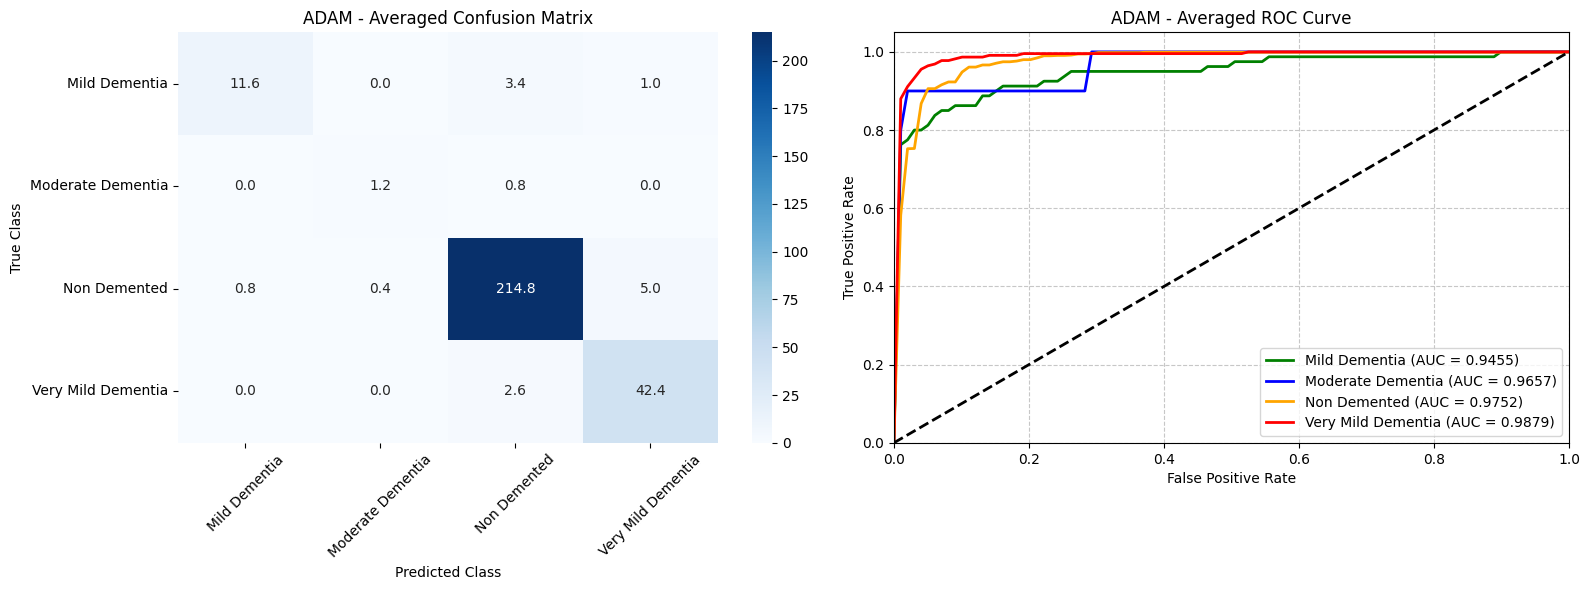

Loading and predicting with 2_run1...
Loading and predicting with 2_run2...
Loading and predicting with 2_run3...
Loading and predicting with 2_run4...
Loading and predicting with 2_run5...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Rmsprop Classification Report (Averaged over 5 Runs)
                      precision     recall   f1-score    support

       Mild Dementia     0.9857     0.8125     0.8900         16
   Moderate Dementia     0.8000     0.5000     0.6000          2
        Non Demented     0.9839     0.9928     0.9883        221
  Very Mild Dementia     0.9363     0.9733     0.9543         45

            accuracy                           0.9761        284
           macro avg     0.9265     0.8196     0.8582        284
        weighted avg     0.9752     0.9761     0.9746        284




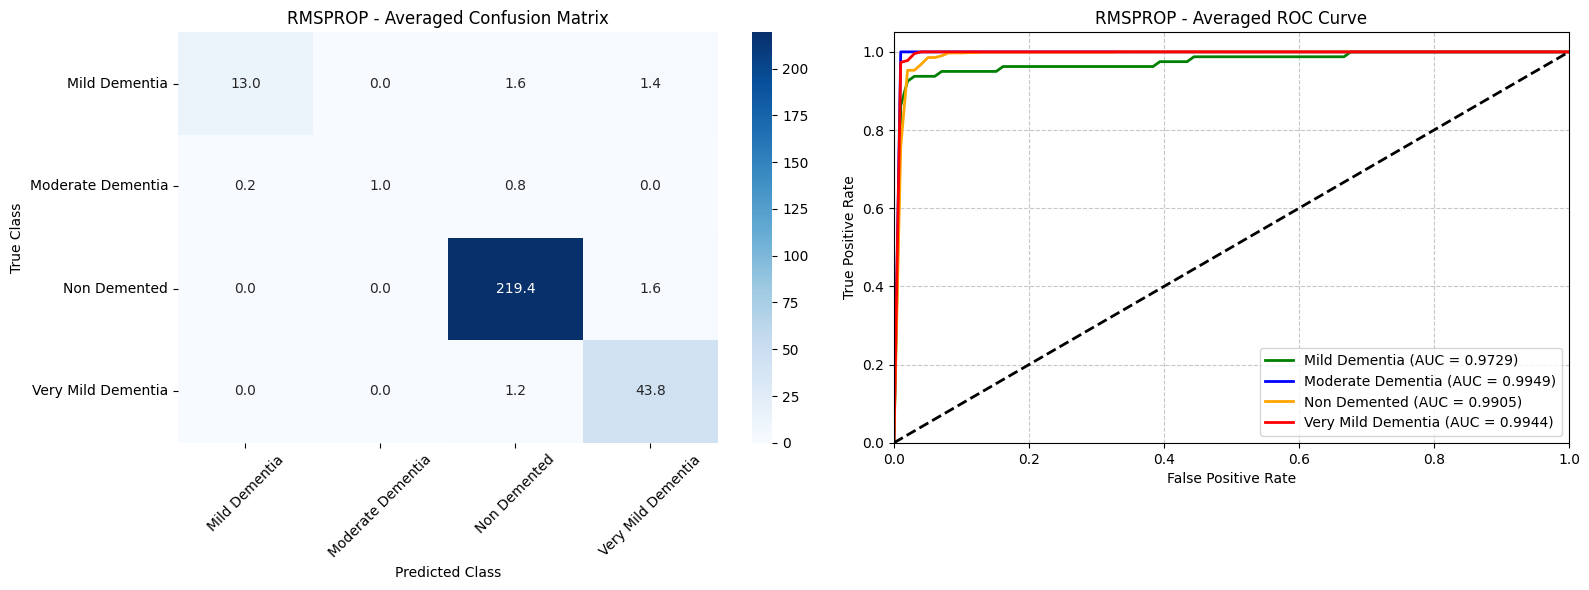

Loading and predicting with 3_run1...
Loading and predicting with 3_run2...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Loading and predicting with 3_run3...
Loading and predicting with 3_run4...
Loading and predicting with 3_run5...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Nadam Classification Report (Averaged over 5 Runs)
                      precision     recall   f1-score    support

       Mild Dementia     0.9071     0.7125     0.7968         16
   Moderate Dementia     0.4000     0.2000     0.2667          2
        Non Demented     0.9610     0.9593     0.9601        221
  Very Mild Dementia     0.8058     0.8978     0.8490         45

            accuracy                           0.9303        284
           macro avg     0.7685     0.6924     0.7182        284
        weighted avg     0.9294     0.9303     0.9284        284




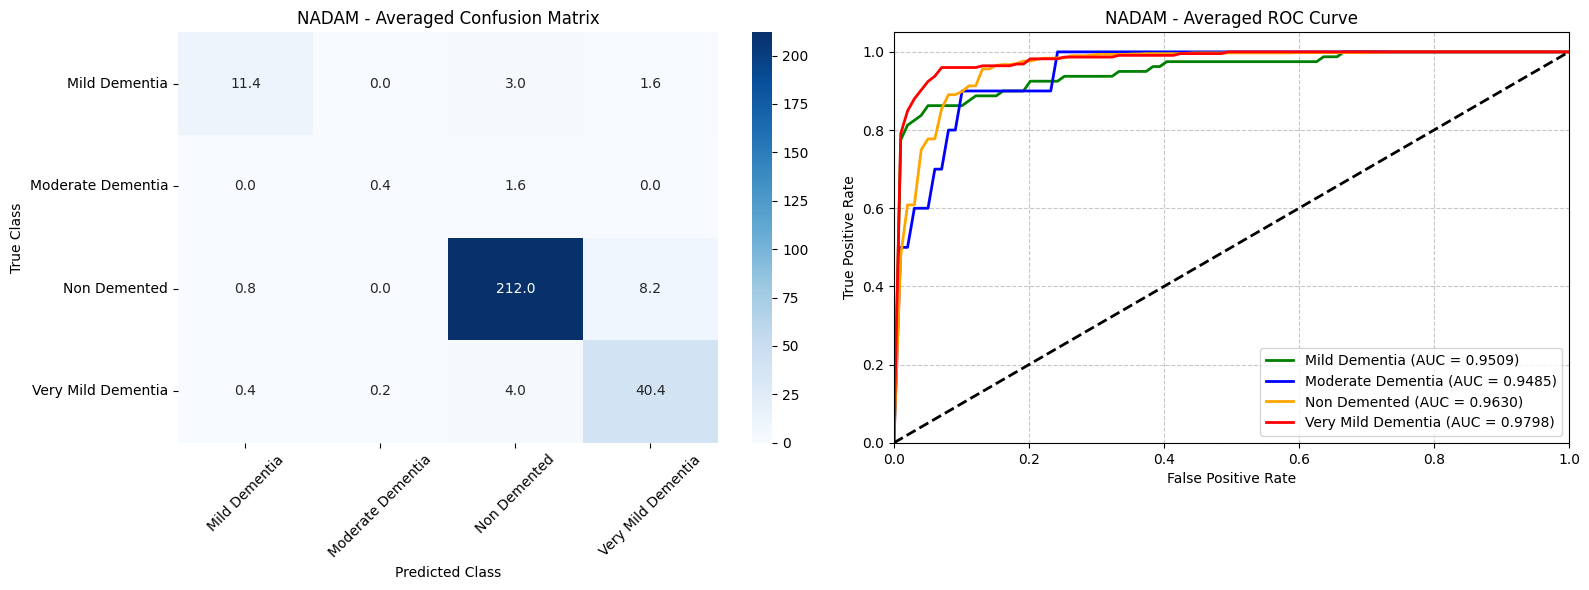

Loading and predicting with 4_run1...
Loading and predicting with 4_run2...
Loading and predicting with 4_run3...
Loading and predicting with 4_run4...
Loading and predicting with 4_run5...

Sgd_momentum Classification Report (Averaged over 5 Runs)
                      precision     recall   f1-score    support

       Mild Dementia     0.7283     0.6375     0.6739         16
   Moderate Dementia     0.8000     0.5000     0.6000          2
        Non Demented     0.9432     0.9475     0.9453        221
  Very Mild Dementia     0.7915     0.8133     0.8017         45

            accuracy                           0.9056        284
           macro avg     0.8158     0.7246     0.7552        284
        weighted avg     0.9061     0.9056     0.9048        284




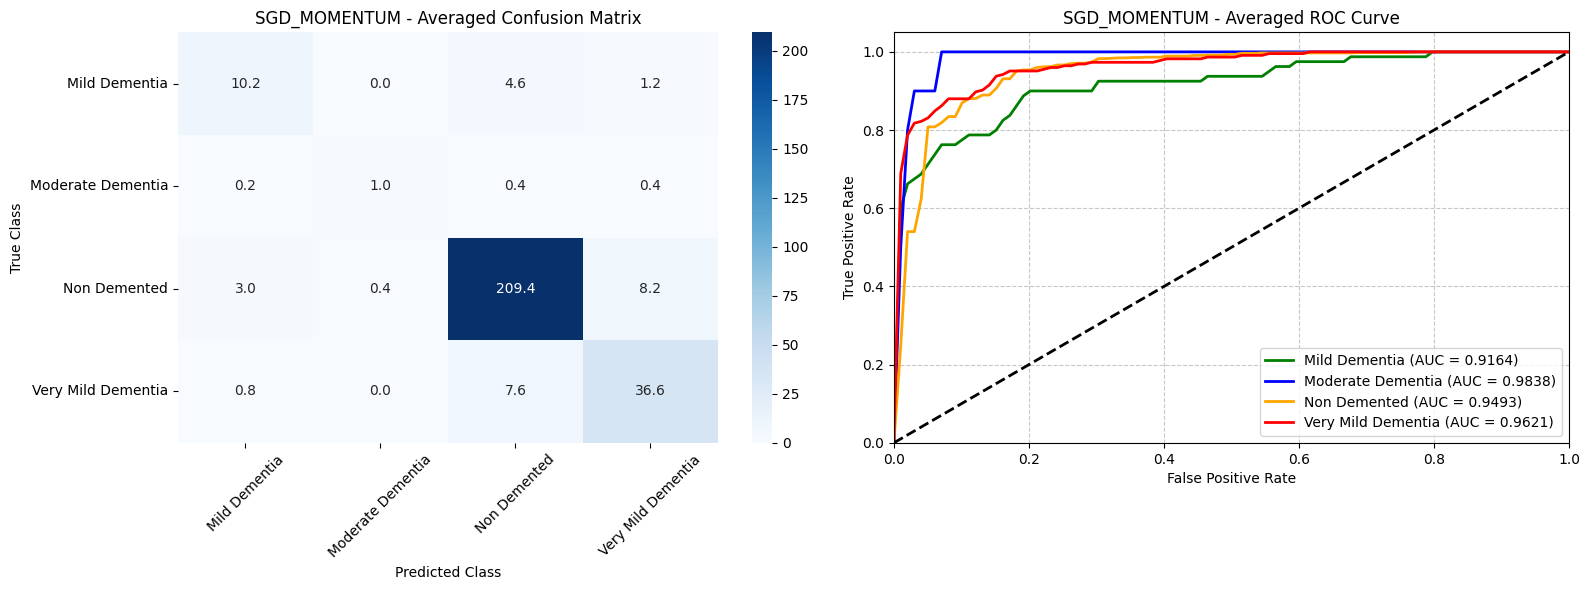

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix, roc_curve, auc

y_test_classes = np.argmax(y_test, axis=1)


CLASS_NAMES = ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very Mild Dementia']
N_CLASSES = len(CLASS_NAMES)

base_save_dir = "/content/drive/My Drive/Colab Notebooks/models_history/optimizer_tuning/multirun"

optimizer_grid = {
    '1': 'adam',
    '2': 'rmsprop',
    '3': 'nadam',
    '4': 'sgd_momentum'
}

TARGET_RUNS = ['1','2', '3', '4']
RUNS_PER_OPTIMIZER = 5

# ==========================================
# EVALUATION & AVERAGING
# ==========================================
for run_name in TARGET_RUNS:
    opt_choice = optimizer_grid[run_name]

    # Accumulators
    acc_list = []
    precision_list = []
    recall_list = []
    f1_list = []

    # Initialize an empty confusion matrix
    total_cm = np.zeros((N_CLASSES, N_CLASSES))

    # ROC accumulators
    mean_fpr = np.linspace(0, 1, 100)
    tprs = {i: [] for i in range(N_CLASSES)}
    aucs = {i: [] for i in range(N_CLASSES)}

    for run_idx in range(RUNS_PER_OPTIMIZER):
        current_run_id = f"{run_name}_run{run_idx+1}"
        best_model_path = os.path.join(base_save_dir, f"{current_run_id}_checkpoints", "best_model.keras")

        if not os.path.exists(best_model_path):
            print(f"[!] Warning: Could not find {best_model_path}. Skipping.")
            continue

        print(f"Loading and predicting with {current_run_id}...")
        model = tf.keras.models.load_model(best_model_path)

        # Predict on Test Data
        y_pred_probs = model.predict(X_test, verbose=0)
        y_pred_classes = np.argmax(y_pred_probs, axis=1)

        #Standard Metrics
        acc = accuracy_score(y_test_classes, y_pred_classes)
        p, r, f, _ = precision_recall_fscore_support(y_test_classes, y_pred_classes, average=None, labels=range(N_CLASSES))

        acc_list.append(acc)
        precision_list.append(p)
        recall_list.append(r)
        f1_list.append(f)

        #Confusion Matrix
        cm = confusion_matrix(y_test_classes, y_pred_classes, labels=range(N_CLASSES))
        total_cm += cm

        # roc curve
        for i in range(N_CLASSES):
            fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_probs[:, i])
            roc_auc = auc(fpr, tpr)


            interp_tpr = np.interp(mean_fpr, fpr, tpr)
            interp_tpr[0] = 0.0

            tprs[i].append(interp_tpr)
            aucs[i].append(roc_auc)

    # calculate average

    avg_acc = np.mean(acc_list)
    avg_precision = np.mean(precision_list, axis=0)
    avg_recall = np.mean(recall_list, axis=0)
    avg_f1 = np.mean(f1_list, axis=0)

    support = np.bincount(y_test_classes)
    total_support = np.sum(support)

    macro_precision = np.mean(avg_precision)
    macro_recall = np.mean(avg_recall)
    macro_f1 = np.mean(avg_f1)

    weighted_precision = np.average(avg_precision, weights=support)
    weighted_recall = np.average(avg_recall, weights=support)
    weighted_f1 = np.average(avg_f1, weights=support)

    # Average Confusion Matrix
    avg_cm = total_cm / RUNS_PER_OPTIMIZER

    # Average ROC Metrics
    mean_tprs = {}
    mean_aucs = {}
    for i in range(N_CLASSES):
        mean_tprs[i] = np.mean(tprs[i], axis=0)
        mean_tprs[i][-1] = 1.0 # Force end at 1,1
        mean_aucs[i] = auc(mean_fpr, mean_tprs[i])


    print(f"\n{'='*60}")
    print(f"{opt_choice.capitalize()} Classification Report (Averaged over {RUNS_PER_OPTIMIZER} Runs)")
    print(f"{'='*60}")
    print(f"{'':<20} {'precision':>10} {'recall':>10} {'f1-score':>10} {'support':>10}\n")

    # Print Individual Class Rows
    for i, class_name in enumerate(CLASS_NAMES):
        print(f"{class_name:>20} {avg_precision[i]:10.4f} {avg_recall[i]:10.4f} {avg_f1[i]:10.4f} {support[i]:10}")

    print()
    # Print Averages Rows
    print(f"{'accuracy':>20} {'':>10} {'':>10} {avg_acc:10.4f} {total_support:10}")
    print(f"{'macro avg':>20} {macro_precision:10.4f} {macro_recall:10.4f} {macro_f1:10.4f} {total_support:10}")
    print(f"{'weighted avg':>20} {weighted_precision:10.4f} {weighted_recall:10.4f} {weighted_f1:10.4f} {total_support:10}")
    print("\n")

    # Plot Average Confusion Matrix
    plt.figure(figsize=(16, 6))

    plt.subplot(1, 2, 1)
    sns.heatmap(avg_cm, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'{opt_choice.upper()} - Averaged Confusion Matrix')
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.xticks(rotation=45)

    # Plot Average ROC Curve
    plt.subplot(1, 2, 2)
    colors = ['green', 'blue', 'orange', 'red']
    for i, color in zip(range(N_CLASSES), colors):
        plt.plot(mean_fpr, mean_tprs[i], color=color, lw=2,
                 label=f'{CLASS_NAMES[i]} (AUC = {mean_aucs[i]:.4f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{opt_choice.upper()} - Averaged ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

## Inference Latency (run on cpu)

In [ ]:
import time
import numpy as np
import tensorflow as tf

model = tf.keras.models.load_model('/content/drive/My Drive/Colab Notebooks/models_history/optimizer_tuning/2_checkpoints/best_model.keras')

dummy_input = np.random.rand(1, 61, 128, 128, 3).astype(np.float32)

print("Starting inference latency test...")

for _ in range(10):
    _ = model.predict(dummy_input, verbose=0)

iterations = 100
latencies = []

for _ in range(iterations):
    start_time = time.perf_counter()
    _ = model.predict(dummy_input, verbose=0)
    end_time = time.perf_counter()

    # Convert to milliseconds
    latencies.append((end_time - start_time) * 1000)

avg_latency = np.mean(latencies)
std_latency = np.std(latencies)
p95_latency = np.percentile(latencies, 95)

print(f"\n--- Inference Latency Results over 100 runs ---")
print(f"Average Latency : {avg_latency:.2f} ms")
print(f"Std Deviation   : {std_latency:.2f} ms")
print(f"95th Percentile : {p95_latency:.2f} ms")
print(f"Clinical Status : {'Viable for real-time' if avg_latency < 1000 else 'Requires optimization'}")

Starting inference latency test...

--- Inference Latency Results over 100 runs ---
Average Latency : 669.80 ms
Std Deviation   : 211.44 ms
95th Percentile : 1340.81 ms
Clinical Status : Viable for real-time


## Model Complexity and storage

In [ ]:
import os
import tensorflow as tf
baseline_model_path = '/content/drive/MyDrive/Colab Notebooks/models_history/baseline_epoch/cnnmodel.keras'
hybrid_model_path = '/content/drive/My Drive/Colab Notebooks/models_history/optimizer_tuning/2_checkpoints/best_model.keras'

def analyze_model_footprint(model_path, model_name):
    try:
        # Load model and calculate file size
        model = tf.keras.models.load_model(model_path)
        file_size_mb = os.path.getsize(model_path) / (1024 * 1024)

        # Calculate parameter counts
        total_params = model.count_params()
        trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])

        print(f"--- {model_name} ---")
        print(f"Total Parameters     : {total_params:,}")
        print(f"Trainable Parameters : {trainable_params:,}")
        print(f"Disk Storage Size    : {file_size_mb:.2f} MB\n")

    except Exception as e:
        print(f"Could not analyze {model_name}: {e}")

# Run analysis
analyze_model_footprint(baseline_model_path, "Baseline CNN")
analyze_model_footprint(hybrid_model_path, "Hybrid CNN-LSTM")

--- Baseline CNN ---
Total Parameters     : 269,572
Trainable Parameters : 269,572
Disk Storage Size    : 3.14 MB

--- Hybrid CNN-LSTM ---
Total Parameters     : 93,956
Trainable Parameters : 93,956
Disk Storage Size    : 1.14 MB

